# Adaptive QCNN, solving clf problem - dataset: MNIST

In [1]:
# %pip install itables
import numpy as np

### SIMULATION HYPERPARAMETERS TO CHANGE

In [2]:
# Noise setting / Device and dataset name
noise_settings = ['0', '1', '2', '3']
noise_to_device = {'0': 'noiseless',
                   '1': 'FakeGuadalupeV2',
                   '2': 'AerSim with backend noise',
                   '3': 'IBM Quantum backend'}

selected_indices = [0, 1, 2, 3]
noise_settings = [noise_settings[i] for i in selected_indices]
device_names = [noise_to_device[key] for key in noise_settings]

num_qubits = [4, 8, 10]      # 4, 8, 10
problem_type = 'clf'
dataset_type = 'mnist'
dataset_dir = None
dataset_name = 'mnist'
num_shots = 256    # 1024, 256

sim_iter_num = list(range(5))
# sim_iter_num = [4]

model_names_str = ['model_mmF', 'model_mmTmbF', 'model_mmTmbT']
model_names_str_new = ['QCNN', 'HQCNN-EZ', 'HQCNN-EM']
model_rename_map = dict(zip(model_names_str, model_names_str_new))
selected_indices = [0, 1, 2]
model_names_str = [model_names_str[i] for i in selected_indices]
NO_BOUNDARY = False
NO_BOUNDARY_str = '_noBd' if NO_BOUNDARY else ""

PLOT_SAVE = True            # True, False
SUMMRAY_TABLE_SAVE = True   # True, False

print('noise_setting:', noise_settings)
print('device_name:', device_names)
print('dataset_name:', dataset_name)
print('model_names_str:', model_names_str)
print('num_shots:', num_shots)
print('PLOT_SAVE:', PLOT_SAVE)
print('SUMMRAY_TABLE_SAVE:', SUMMRAY_TABLE_SAVE)

noise_setting: ['0', '1', '2', '3']
device_name: ['noiseless', 'FakeGuadalupeV2', 'AerSim with backend noise', 'IBM Quantum backend']
dataset_name: mnist
model_names_str: ['model_mmF', 'model_mmTmbF', 'model_mmTmbT']
num_shots: 256
PLOT_SAVE: True
SUMMRAY_TABLE_SAVE: True


### QCNN & NN MODEL HYPERPARAMETERS TO CHANGE

In [3]:
from itertools import product

# Global parameters of the QCNN circuit (for Qnode into TorchLayer)
embed_method = ['AngleEmbed']    # 'AmplitudeEmbed', 'IQPEmbed', 'AngleEmbed', 'AngleEmbed-r', 'ZZFeatureMap'

conv_pool_blocks = [('ConvSimple', 'PoolSimple')]    # [('ConvSimple', 'PoolSimple'), ('ConvSU4', 'PoolSimple')]
selected_indices = [0]
conv_pool_blocks = [conv_pool_blocks[i] for i in selected_indices]

conv_pool_blocks_string = []
for i in range(len(conv_pool_blocks)):
    conv_pool_blocks_string.append('_'.join(conv_pool_blocks[i]))

num_epochs = 20
batch_size = 10
num_iters = num_epochs * batch_size
hidden_acti = 'ReLU'                        # 'CELU', 'ReLU', 'Tanh'

num_hidden_layers = 1
lr_value = 0.01
lr_schedule = False
lr_schedule_str = '_schedT' if lr_schedule else ""

lr_schedule = False

model_specs = []
for embed, conv_pool in product(embed_method, conv_pool_blocks_string):
    model_specs.append((f'{embed}_{conv_pool}{NO_BOUNDARY_str}'
                        +f'_{hidden_acti}_hl{num_hidden_layers}_batch{batch_size}_lr{lr_value}{lr_schedule_str}'))

model_specs

['AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01']

### Create save_plot directory

In [4]:
# Define the folder names
# save_dir = f'save_results_{problem_type}/results_summary/'
save_dir = f'save_results_fb_{problem_type}/results_summary2/'

for model_spec in model_specs:
    save_summary_results_dirs = f'{save_dir}{model_spec}_{num_shots}/'
    
# print(save_summary_results_dirs)
# Create the folder if it doesn't exist

import os
if not os.path.exists(save_summary_results_dirs):
    os.makedirs(save_summary_results_dirs)
    
print('save_summary_results_dirs:', save_summary_results_dirs)

save_summary_results_dirs: save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/


### Get result directory

In [5]:
from itertools import product

dir_names_strings = []
for num_qubit in num_qubits:
    for model_name in model_names_str:
        for model_spec, ns, epoch in product(model_specs, noise_settings, sim_iter_num):
            dir_string = f"save_results_{problem_type}/{dataset_name}_{num_qubit}/{model_name}/{model_spec}/ns{ns}_iter{epoch}_{num_shots}"
            dir_names_strings.append(dir_string)
            # print(dir_string)
# dir_names_strings

dir_names_strings_fb_zp = []
for num_qubit in [10]:
    for model_name in ['model_mmF']:
        for model_spec, ns, epoch in product(model_specs, noise_settings, sim_iter_num):
            dir_string = f"save_results_fb_{problem_type}/{dataset_name}_{num_qubit}/{model_name}/{model_spec}(zero_padded)/ns{ns}_iter{epoch}_{num_shots}"
            dir_names_strings_fb_zp.append(dir_string)
            # print(dir_string)
# dir_names_strings_fb_zp

dir_names_strings_fb_hl0 = []
for num_qubit in [10]:
    for model_name in ['model_mmTmbF']:
        for model_spec, ns, epoch in product(model_specs, noise_settings, sim_iter_num):
            dir_string = f"save_results_fb_{problem_type}/{dataset_name}_{num_qubit}/{model_name}/{'AngleEmbed_ConvSimple_PoolSimple_ReLU_hl0_batch10_lr0.01'}/ns{ns}_iter{epoch}_{num_shots}"
            dir_names_strings_fb_hl0.append(dir_string)
            # print(dir_string)
# dir_names_strings_fb_hl0

dir_names_strings_fb_r4 = []
for num_qubit in [4]:
    for model_name in ['model_mmF', 'model_mmTmbF']:
        for model_spec, ns, epoch in product(model_specs, [3], sim_iter_num):
            dir_string = f"save_results_fb_{problem_type}/{dataset_name}_{num_qubit}/{model_name}/{model_spec}/ns{ns}_iter{epoch}_{num_shots}"
            dir_names_strings_fb_r4.append(dir_string)
            # print(dir_string)
# dir_names_strings_fb_r4

### Get the experiment output values

In [6]:
import os
import pandas as pd

def get_train_results(file_path):
    # For train_results.txt
    with open(file_path, 'r') as file:
        train_results = pd.read_csv(file)
    return train_results

In [7]:
import re

def get_perf_output(file_path):
    perf_output = {}
    
    with open(file_path, 'r') as file:
        content = file.read()
        
    if problem_type == 'reg':
        mae = re.search(r'mae: ([\d.]+)', content)
        mse = re.search(r'mse: ([\d.]+)', content)
        rmse = re.search(r'rmse: ([\d.]+)', content)
        r_squared = re.search(r'r-squared: ([-\d.]+)', content)
        adj_r_squared = re.search(r'adj r-squared: ([-\d.]+)', content)
        best_epoch = re.search(r'best_epoch: (\d+)', content)

        if mae:
            perf_output['mae'] = float(mae.group(1))
        if mse:
            perf_output['mse'] = float(mse.group(1))
        if rmse:
            perf_output['rmse'] = float(rmse.group(1))
        if r_squared:
            perf_output['r-squared'] = float(r_squared.group(1))
        if adj_r_squared:
            perf_output['adj r-squared'] = float(adj_r_squared.group(1))
        if best_epoch:
            perf_output['best_epoch'] = int(best_epoch.group(1))
    
    elif problem_type == 'clf':
        binary_cross_entropy_loss = re.search(r'binary_cross_entropy_loss: ([-\d.]+)', content)
        accuracy = re.search(r'accuracy: ([-\d.]+)', content)
        best_epoch = re.search(r'best_epoch: (\d+)', content)

        if binary_cross_entropy_loss:
            perf_output['binary_cross_entropy_loss'] = float(binary_cross_entropy_loss.group(1))
        if accuracy:
            perf_output['accuracy'] = float(accuracy.group(1))
        if best_epoch:
            perf_output['best_epoch'] = int(best_epoch.group(1))

    return perf_output

In [8]:
def process_folders(dir_names_strings):
    loss_data = []
    loss_batch_data = []
    performance_data = []
    performance_best_data = []

    for dir in dir_names_strings:
        # Extract noise_setting from the folder path
        ns_value = re.search(r'ns(\d+)', dir).group(1)
        
        # Extract the iteration number from the folder path
        sim_iter_num = int(re.search(r'iter(\d+)', dir).group(1))
        
        # Extract the number of qubits used from the folder path
        num_qubit = int(re.search(rf'{dataset_name}_(\d+)', dir).group(1))
        
        # Convert noise_setting to labels
        if ns_value in noise_settings:
            index = noise_settings.index(ns_value)
            device_name = device_names[index]
        
        model_name = os.path.basename(os.path.dirname(os.path.dirname(dir)))
        model_spec = os.path.basename(os.path.dirname(dir))
        
        # Process train_results.txt (Load up to epoch < num_epochs)
        train_results_path = os.path.join(dir, 'train_results.txt')
        if os.path.exists(train_results_path):
            with open(train_results_path, 'r') as f:
                next(f)  # Skip header
                for line in f:
                    epoch, train_loss, val_loss = line.strip().split(',')
                    epoch = int(epoch)
                    if epoch >= num_epochs:  # Stop when epoch reaches num_epochs (30)
                        break
                    loss_entry = {
                        'Device': device_name,
                        'Qubits': num_qubit,
                        'Model': model_name,
                        'Model_spec': model_spec,
                        'sim_iter_num': sim_iter_num,
                        'Epoch': epoch,
                        'Train Loss': float(train_loss),
                        'Validation Loss': float(val_loss) if val_loss else None
                    }
                    loss_data.append(loss_entry)
        
        # Process train_batch_results.txt (Load up to epoch < num_epochs)
        train_batch_results_path = os.path.join(dir, 'train_batch_results.txt')
        if os.path.exists(train_batch_results_path):
            with open(train_batch_results_path, 'r') as f:
                next(f)  # Skip header
                for line in f:
                    epoch, batch, train_batch_loss = line.strip().split(',')
                    epoch = int(epoch)
                    if epoch >= num_epochs:  # Stop when epoch reaches num_epochs (30)
                        break
                    loss_batch_entry = {
                        'Device': device_name,
                        'Qubits': num_qubit,
                        'Model': model_name,
                        'Model_spec': model_spec,
                        'sim_iter_num': sim_iter_num,
                        'Epoch': epoch,
                        'Batch': int(batch),
                        'Train_batch_Loss': float(train_batch_loss)
                    }
                    loss_batch_data.append(loss_batch_entry)

        # Process perf_output_train.txt
        train_perf_path = os.path.join(dir, f'{problem_type}_perf_output_train_epoch{num_epochs}.txt')
        if os.path.exists(train_perf_path):
            train_metrics = get_perf_output(train_perf_path)
            performance_data_entry = {
                'Device': device_name,
                'Qubits': num_qubit,
                'Model': model_name,
                'Model_spec': model_spec,
                'sim_iter_num': sim_iter_num,
                'Dataset': 'Train',
            }
            if problem_type == 'reg':
                performance_data_entry.update({
                    'MAE': train_metrics['mae'],
                    'MSE': train_metrics['mse'],
                    'RMSE': train_metrics['rmse'],
                    'R-squared': train_metrics['r-squared'],
                    'Adj R-squared': train_metrics['adj r-squared'],
                })
            elif problem_type == 'clf':
                performance_data_entry.update({
                    'binary_cross_entropy_loss': train_metrics['binary_cross_entropy_loss'],
                    'accuracy': train_metrics['accuracy'],
                })
            performance_data.append(performance_data_entry)

        # Process perf_output_test.txt
        test_perf_path = os.path.join(dir, f'{problem_type}_perf_output_test_epoch{num_epochs}.txt')
        if os.path.exists(test_perf_path):
            test_metrics = get_perf_output(test_perf_path)
            performance_data_entry = {
                'Device': device_name,
                'Qubits': num_qubit,
                'Model': model_name,
                'Model_spec': model_spec,
                'sim_iter_num': sim_iter_num,
                'Dataset': 'Test',
            }
            if problem_type == 'reg':
                performance_data_entry.update({
                    'MAE': test_metrics['mae'],
                    'MSE': test_metrics['mse'],
                    'RMSE': test_metrics['rmse'],
                    'R-squared': test_metrics['r-squared'],
                    'Adj R-squared': test_metrics['adj r-squared'],
                })
            elif problem_type == 'clf':
                performance_data_entry.update({
                    'binary_cross_entropy_loss': test_metrics['binary_cross_entropy_loss'],
                    'accuracy': test_metrics['accuracy'],
                })
            performance_data.append(performance_data_entry)
            
        # Process perf_output_train_best.txt
        train_perf_path = os.path.join(dir, f'{problem_type}_perf_output_train_epoch{num_epochs}_best.txt')
        if os.path.exists(train_perf_path):
            train_metrics = get_perf_output(train_perf_path)
            performance_data_entry = {
                'Device': device_name,
                'Qubits': num_qubit,
                'Model': model_name,
                'Model_spec': model_spec,
                'sim_iter_num': sim_iter_num,
                'Dataset': 'Train',
            }
            if problem_type == 'reg':
                performance_data_entry.update({
                    'MAE': train_metrics['mae'],
                    'MSE': train_metrics['mse'],
                    'RMSE': train_metrics['rmse'],
                    'R-squared': train_metrics['r-squared'],
                    'Adj R-squared': train_metrics['adj r-squared']
                })
                if device_name != 'IBM Quantum backend':
                    performance_data_entry['best_epoch'] = train_metrics['best_epoch']
                    
            elif problem_type == 'clf':
                performance_data_entry.update({
                    'binary_cross_entropy_loss': train_metrics['binary_cross_entropy_loss'],
                    'accuracy': train_metrics['accuracy']
                })
                if device_name != 'IBM Quantum backend':
                                    performance_data_entry['best_epoch'] = train_metrics['best_epoch']
                                    
            performance_best_data.append(performance_data_entry)

        # Process perf_output_test_best.txt
        test_perf_path = os.path.join(dir, f'{problem_type}_perf_output_test_epoch{num_epochs}_best.txt')
        if os.path.exists(test_perf_path):
            test_metrics = get_perf_output(test_perf_path)
            performance_data_entry = {
                'Device': device_name,
                'Qubits': num_qubit,
                'Model': model_name,
                'Model_spec': model_spec,
                'sim_iter_num': sim_iter_num,
                'Dataset': 'Test',
            }
            if problem_type == 'reg':
                performance_data_entry.update({
                    'MAE': test_metrics['mae'],
                    'MSE': test_metrics['mse'],
                    'RMSE': test_metrics['rmse'],
                    'R-squared': test_metrics['r-squared'],
                    'Adj R-squared': test_metrics['adj r-squared']
                })
                if device_name != 'IBM Quantum backend':
                    performance_data_entry['best_epoch'] = test_metrics['best_epoch']
            elif problem_type == 'clf':
                performance_data_entry.update({
                    'binary_cross_entropy_loss': test_metrics['binary_cross_entropy_loss'],
                    'accuracy': test_metrics['accuracy']
                })
                if device_name != 'IBM Quantum backend':
                    performance_data_entry['best_epoch'] = test_metrics['best_epoch']
            performance_best_data.append(performance_data_entry)

    loss_df = pd.DataFrame(loss_data)
    batch_loss_df = pd.DataFrame(loss_batch_data)
    performance_df = pd.DataFrame(performance_data)
    performance_best_df = pd.DataFrame(performance_best_data)

    return loss_df, batch_loss_df, performance_df, performance_best_df

In [9]:
# from itables import init_notebook_mode
# import itables.options as opt
# init_notebook_mode(all_interactive=True)
# opt.maxBytes = "2MB"

loss_df, batch_loss_df, performance_df, performance_best_df = process_folders(dir_names_strings)

for df in [loss_df, batch_loss_df, performance_df, performance_best_df]:
    if not df.empty and 'Model' in df.columns:
        df['Device'] = df['Device'].replace({'AerSim with backend noise': 'AerSim (IBM-Yonsei)'})
        df['Model'] = df['Model'].replace(model_rename_map)


loss_df_fb_zp, batch_loss_df_fb_zp, performance_df_fb_zp, performance_best_df_fb_zp = process_folders(dir_names_strings_fb_zp)

for df in [loss_df_fb_zp, batch_loss_df_fb_zp, performance_df_fb_zp, performance_best_df_fb_zp]:
    if not df.empty and 'Model' in df.columns:
        df['Device'] = df['Device'].replace({'AerSim with backend noise': 'AerSim (IBM-Yonsei)'})
        df['Model'] = df['Model'].replace(model_rename_map)
        df['Model'] = df['Model'].replace('QCNN', 'QCNN with NN (zero-padded)')
        
        
loss_df_fb_hl0, batch_loss_df_fb_hl0, performance_df_fb_hl0, performance_best_df_fb_hl0 = process_folders(dir_names_strings_fb_hl0)

for df in [loss_df_fb_hl0, batch_loss_df_fb_hl0, performance_df_fb_hl0, performance_best_df_fb_hl0]:
    if not df.empty and 'Model' in df.columns:
        df['Device'] = df['Device'].replace({'AerSim with backend noise': 'AerSim (IBM-Yonsei)'})
        df['Model'] = df['Model'].replace(model_rename_map)
        df['Model'] = df['Model'].replace('HQCNN-EZ', 'HQCNN-EZ (linear readout)')


loss_df_fb_r4, batch_loss_df_fb_r4, performance_df_fb_r4, performance_best_df_fb_r4 = process_folders(dir_names_strings_fb_r4)

for df in [loss_df_fb_r4, batch_loss_df_fb_r4, performance_df_fb_r4, performance_best_df_fb_r4]:
    if not df.empty and 'Model' in df.columns:
        df['Device'] = df['Device'].replace({'AerSim with backend noise': 'AerSim (IBM-Yonsei)',
                                             'IBM Quantum backend': 'IBM Yonsei'})
        df['Model'] = df['Model'].replace(model_rename_map)

In [10]:
# loss_df
# batch_loss_df

# performance_df
# # performance_df.to_csv(save_summary_results_dirs+'performance_all.csv')

# performance_best_df
# # performance_df.to_csv(save_summary_results_dirs+'performance_best_all.csv')

### Figure 2 Train loss graph for each case

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
from matplotlib.legend_handler import HandlerTuple

def plot_loss_curves_type3_filtered(loss_df, num_qubit, model, conv_filter_str,
                                    plot_title='Loss Curves: All Devices', markersize = 7,
                                    legend_show=False, plot_save=False,
                                    ax=None):

    # draw on given subplot if provided; otherwise make a new fig
    if ax is not None:
        plt.sca(ax)
    else:
        plt.figure(figsize=(7, 6))

    # Prepare the data based on the Model and convolution filter
    plot_data = loss_df[(loss_df['Model'] == model) &
                        (loss_df['Model_spec'].str.contains(conv_filter_str, na=False)) &
                        (loss_df['Qubits'] == num_qubit)].copy()
    plot_data['Loss Type'] = 'Train'
    plot_data_val = plot_data.copy()
    plot_data_val['Loss Type'] = 'Validation'
    plot_data_val['Loss'] = plot_data_val['Validation Loss']
    plot_data['Loss'] = plot_data['Train Loss']

    # Devices present in this panel, ordered by the global `device_names` so the
    # colour/marker mapping stays identical across every model panel.
    present = set(plot_data['Device'].unique())
    try:
        ordered = [d for d in device_names if d in present]
        ordered += [d for d in plot_data['Device'].unique() if d not in set(ordered)]
    except NameError:                      # device_names not defined -> fall back
        ordered = list(plot_data['Device'].unique())
    unique_devices = ordered

    marker_shapes = ["X", "^", "o", "d", "*"]
    device_marker_map = {d: marker_shapes[i % len(marker_shapes)] for i, d in enumerate(unique_devices)}

    color_palette = sns.color_palette("tab10", len(unique_devices))
    device_color_map = {d: color_palette[i] for i, d in enumerate(unique_devices)}

    hatch_patterns = [None, "////", "oo", "....", "xx", "\\\\", "||", "++"]
    device_hatch_map = {d: hatch_patterns[i % len(hatch_patterns)] for i, d in enumerate(unique_devices)}

    # ==== TRAIN: ±SD band + solid mean line ====
    for d in unique_devices:
        df_d = plot_data[plot_data['Device'] == d]
        if df_d.empty:
            continue

        g  = df_d.groupby("Epoch")["Loss"]
        mu = g.mean()
        sd = g.std(ddof=1).fillna(0.0)

        x = mu.index.values
        y = mu.values
        y_lo = y - sd.values
        y_hi = y + sd.values

        c  = device_color_map[d]
        mk = device_marker_map[d]
        ht = device_hatch_map[d]
        short_label = d   # <-- for shared legend

        plt.fill_between(x, y_lo, y_hi, facecolor=c, alpha=0.15,
                         hatch=ht, edgecolor=c, linewidth=0.0, zorder=1)

        plt.plot(x, y, color=c, linestyle='-',
                 marker=mk, markersize=markersize, linewidth=1.5, zorder=2,
                 label=short_label)  # <-- add label on TRAIN line only

    # ==== VALIDATION: dotted mean line ====
    for d in unique_devices:
        df_dv = plot_data_val[plot_data_val['Device'] == d]
        if df_dv.empty:
            continue

        gv   = df_dv.groupby("Epoch")["Loss"]
        mu_v = gv.mean()

        xv = mu_v.index.values
        yv = mu_v.values

        c  = device_color_map[d]
        mk = device_marker_map[d]
        plt.plot(xv, yv, color=c, linestyle=':',
                 marker=mk,
                 markersize=markersize, markerfacecolor='none',
                 linewidth=2.0, zorder=2)

    # Axes cosmetics
    if plot_title and ax is None:  # only if standalone
        plt.title(f'Loss Curves: All Devices, {num_qubit}-qubits\n(Model: {model})', fontsize=24)
    plt.xlabel('Epoch', fontsize=22 if ax is None else 12)
    plt.ylabel('Loss',  fontsize=22 if ax is None else 12)
    ax_cur = plt.gca()
    ax_cur.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.ylim(+0.3, +0.73)

    # === LEGEND CONSTRUCTION ===
    legend_elements = []

    # 1. Start with a "Pure Line" representative for the style
    # This ensures the solid/dotted line is clearly visible on the left
    train_handles = [plt.Line2D([0], [0], color='gray', lw=2, linestyle='-', marker=None)]
    val_handles   = [plt.Line2D([0], [0], color='gray', lw=2, linestyle=':', marker=None)]

    for d in unique_devices:
        label = d

        # Standard Device Legend Item
        legend_elements.append(
            plt.Line2D([0], [0],
                       color=device_color_map[d],
                       lw=2,
                       marker=device_marker_map[d],
                       markersize=10,
                       label=label)
        )

        # 2. Add Markers ONLY (linestyle='None')
        # We removed the line here so it doesn't clutter the view
        train_mk = plt.Line2D([0], [0], color='gray',
                           marker=device_marker_map[d],
                           linestyle='None',   # <--- No line, just marker
                           markersize=10,
                           markerfacecolor='gray')
        train_handles.append(train_mk)

        val_mk = plt.Line2D([0], [0], color='gray',
                           marker=device_marker_map[d],
                           linestyle='None',   # <--- No line, just marker
                           markersize=10,
                           markerfacecolor='none')
        val_handles.append(val_mk)

    train_handles.append(plt.Line2D([0], [0], color='gray', lw=2, linestyle='-', marker=None))
    val_handles.append(plt.Line2D([0], [0], color='gray', lw=2, linestyle=':', marker=None))

    # Append the lists as TUPLES
    legend_elements.append(tuple(train_handles))
    legend_elements.append(tuple(val_handles))

    legend_labels = [h.get_label() for h in legend_elements if not isinstance(h, tuple)]
    legend_labels.extend(["Train (Band)", "Validation"])

    # --- Return handles instead of drawing legend ---
    if legend_show:
        plt.legend(handles=legend_elements,
                   labels=legend_labels,
                   title="Devices",
                   handler_map={tuple: HandlerTuple(ndivide=None, pad=1)},
                   handlelength=2,
                   handleheight=1,
                   handletextpad=0.4,
                   title_fontsize=20,
                   fontsize=20,
                   framealpha=0.4)

    return legend_elements, legend_labels

Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Loss_clf_Model-q4.pdf


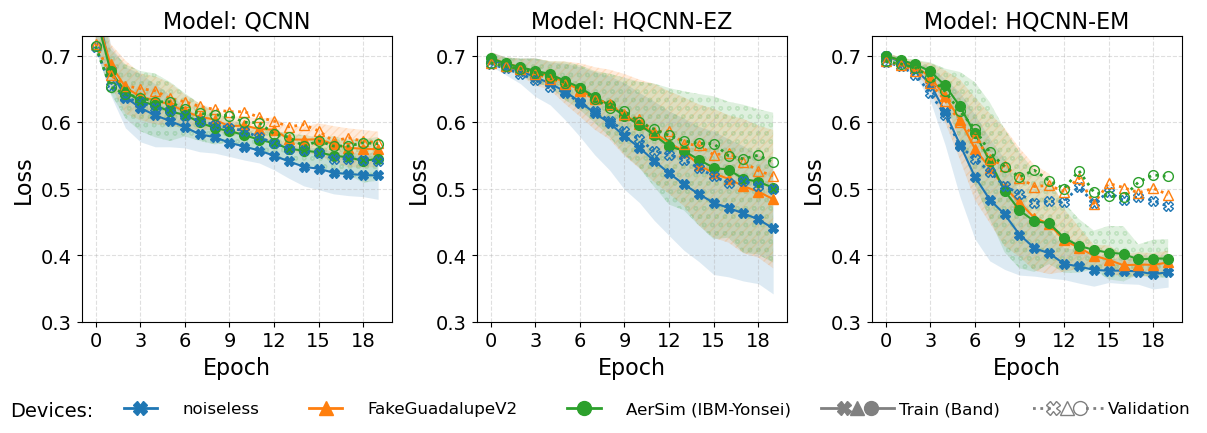

Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Loss_clf_Model-q8.pdf


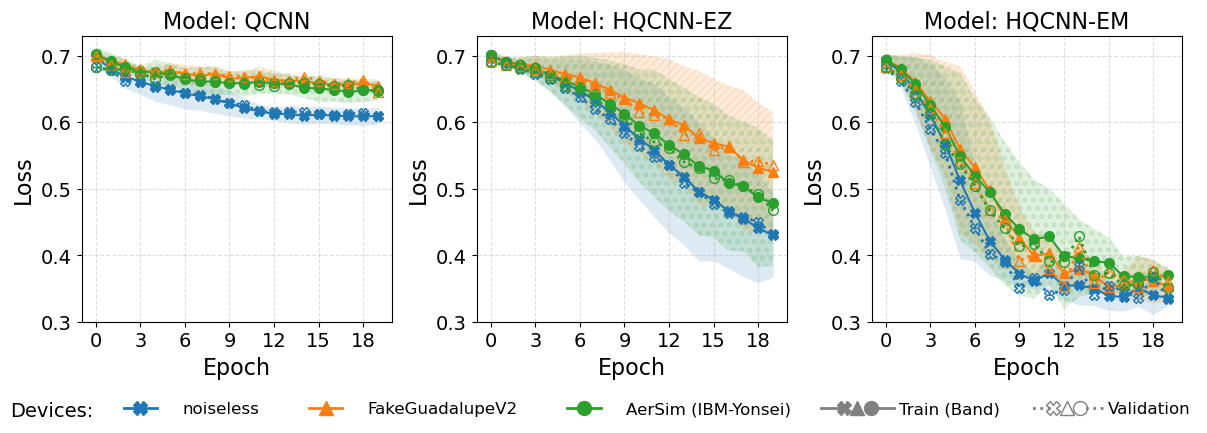

Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Loss_clf_Model-q10.pdf


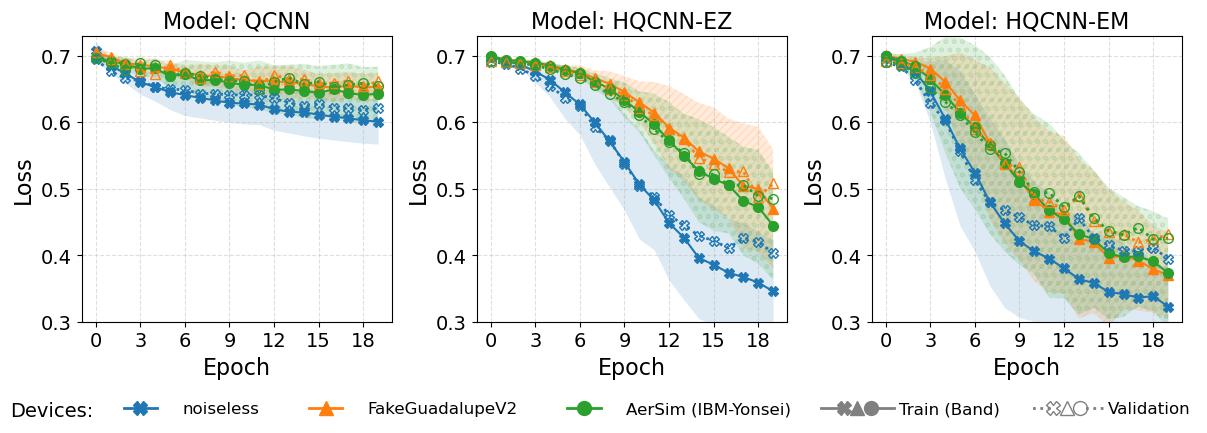

In [12]:
import matplotlib.pyplot as plt

CONV_FILTER = 'ConvSimple'

# === FONT SIZE SETTINGS (centralized here) ===
title_font      = 20   # shared figure title
subplot_title   = 16   # per-model title
axis_label_font = 16   # x/y axis label
tick_font       = 14    # axis tick labels
legend_font     = 12    # legend text
legend_title    = 12   # legend title (if shown)

# One subplot per MODEL (curves inside each subplot = devices / noise settings)
plot_model_names = [model_rename_map.get(m, m) for m in model_names_str]


for num_qubit in num_qubits:
    # === Create subplots ===
    fig, axes = plt.subplots(1, len(plot_model_names), figsize=(12, 4))
    legend_handles = None  # prepare to store legend once
    legend_labels = None

    for i, ax in enumerate(axes):
        model = plot_model_names[i]

        # draw into this subplot
        legend_handles, legend_labels = plot_loss_curves_type3_filtered(
            loss_df = loss_df,
            num_qubit=num_qubit,
            model=model,
            conv_filter_str=CONV_FILTER,
            plot_title=None,
            legend_show=False,
            plot_save=False,
            ax=ax
        )

        # per-subplot title
        ax.set_title(f"Model: {model}", fontsize=subplot_title)

        # axis labels
        ax.set_xlabel("Epoch", fontsize=axis_label_font)
        ax.set_ylabel("Loss", fontsize=axis_label_font)

        # tick label sizes
        ax.tick_params(axis='both', which='major', labelsize=tick_font)

    # ---- Shared figure title ----
    # fig.suptitle("Training & Validation Loss across Devices (eight-qubit circuit)",
    #              fontsize=title_font, y=0.96)

    # ---- Shared legend using returned handles ----
    if legend_handles:
        fig.legend(
            handles=legend_handles,
            labels=legend_labels,
            handler_map={tuple: HandlerTuple(ndivide=None, pad=2.0)},
            loc='upper center',
            bbox_to_anchor=(0.55, 0.02),
            ncol=6,
            frameon=False,
            # title="Devices",
            title_fontsize=legend_title,
            fontsize=legend_font,

            # NEW: make legend samples bigger so dashed lines are visible
            handlelength=2.0,   # longer line segment -> clearer dashes
            markerscale=1.0,    # bigger marker in legend
            handletextpad=1.5,  # spacing between handle and text
            columnspacing=3.0   # spacing between legend columns
        )

        # Add external text label on the left or right side of the legend
        fig.text(0.08, -0.04, "Devices:", ha='right', va='center', fontsize=legend_font+2)  # adjust x,y as needed

    # layout adjustment
    plt.tight_layout()

    # ---- SAVE PLOT AS PDF ----
    if PLOT_SAVE:
        filename = (save_summary_results_dirs + f'Loss_{problem_type}_Model-q{num_qubit}.pdf')
        fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
        print(f"Plot saved as {filename}")

    plt.show()

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.ticker import MaxNLocator
from matplotlib.legend_handler import HandlerTuple

def plot_loss_curves_type2_filtered(loss_df, num_qubit, device, conv_filter_str, 
                                    plot_title='Loss Curves: All Models', markersize=7, 
                                    legend_show=False, plot_save=False,
                                    ax=None):  # <-- NEW

    # draw on given subplot if provided; otherwise make a new fig
    if ax is not None:
        plt.sca(ax)
    else:
        plt.figure(figsize=(7, 6))

    # Prepare the data based on the Device and convolution filter
    plot_data = loss_df[(loss_df['Device'] == device) &
                        (loss_df['Model_spec'].str.contains(conv_filter_str, na=False)) &
                        (loss_df['Qubits'] == num_qubit)].copy()
    plot_data['Loss Type'] = 'Train'
    plot_data_val = plot_data.copy()
    plot_data_val['Loss Type'] = 'Validation'
    plot_data_val['Loss'] = plot_data_val['Validation Loss']
    plot_data['Loss'] = plot_data['Train Loss']

    unique_models = plot_data['Model'].unique()
    marker_shapes = ["X", "^", "o"]
    model_marker_map = {m: marker_shapes[i % len(marker_shapes)] for i, m in enumerate(unique_models)}

    color_palette = sns.color_palette("tab10", len(unique_models))
    model_color_map = {m: color_palette[i] for i, m in enumerate(unique_models)}

    hatch_patterns = [None, "////", "oo", "....", "xx", "\\\\", "||", "++"]
    model_hatch_map = {m: hatch_patterns[i % len(hatch_patterns)] for i, m in enumerate(unique_models)}

    # ==== TRAIN: ±SD band + solid mean line ====
    for m in unique_models:
        df_m = plot_data[plot_data['Model'] == m]
        if df_m.empty:
            continue

        g  = df_m.groupby("Epoch")["Loss"]
        mu = g.mean()
        sd = g.std(ddof=1).fillna(0.0)

        x = mu.index.values
        y = mu.values
        y_lo = y - sd.values
        y_hi = y + sd.values

        c  = model_color_map[m]
        mk = model_marker_map[m]
        ht = model_hatch_map[m]
        short_label = m.split("_", 1)[-1] if "_" in m else m  # <-- for shared legend

        plt.fill_between(x, y_lo, y_hi, facecolor=c, alpha=0.18,
                         hatch=ht, edgecolor=c, linewidth=0.0, zorder=1)

        plt.plot(x, y, color=c, linestyle='-',
                 marker=mk, markersize=markersize, linewidth=1.5, zorder=2,
                 label=short_label)  # <-- add label on TRAIN line only

    # ==== VALIDATION: dotted mean line ====
    for m in unique_models:
        df_mv = plot_data_val[plot_data_val['Model'] == m]
        if df_mv.empty:
            continue

        gv   = df_mv.groupby("Epoch")["Loss"]
        mu_v = gv.mean()

        xv = mu_v.index.values
        yv = mu_v.values

        c  = model_color_map[m]
        mk = model_marker_map[m]
        plt.plot(xv, yv, color=c, linestyle=':',
                 marker=mk,
                 markersize=markersize, markerfacecolor='none',
                 linewidth=2.0, zorder=2)

    # Axes cosmetics
    if plot_title and ax is None:  # only if standalone
        plt.title(f'Loss Curves: All Models, {num_qubit}-qubits\n(Device: {device})', fontsize=24)
    plt.xlabel('Epoch', fontsize=22 if ax is None else 12)
    plt.ylabel('Loss',  fontsize=22 if ax is None else 12)
    ax_cur = plt.gca()
    ax_cur.xaxis.set_major_locator(MaxNLocator(integer=True))
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.ylim(+0.25, +0.75)

    # === LEGEND CONSTRUCTION ===
    legend_elements = []
    
    # 1. Start with a "Pure Line" representative for the style
    # This ensures the solid/dotted line is clearly visible on the left
    train_handles = [plt.Line2D([0], [0], color='gray', lw=2, linestyle='-', marker=None)]
    val_handles   = [plt.Line2D([0], [0], color='gray', lw=2, linestyle=':', marker=None)]
    
    for m in unique_models:
        short_model = m.split("_", 1)[-1]
        label = f"{short_model}"
        
        # Standard Model Legend Item (remains the same)
        legend_elements.append(
            plt.Line2D([0], [0],
                       color=model_color_map[m],
                       lw=2,
                       marker=model_marker_map[m],
                       markersize=10,
                       label=label),
        )
    
        # 2. Add Markers ONLY (linestyle='None')
        # We removed the line here so it doesn't clutter the view
        train_mk = plt.Line2D([0], [0], color='gray',
                           marker=model_marker_map[m], 
                           linestyle='None',   # <--- CHANGED: No line, just marker
                           markersize=10, 
                           markerfacecolor='gray')
        train_handles.append(train_mk)
        
        val_mk = plt.Line2D([0], [0], color='gray',
                           marker=model_marker_map[m], 
                           linestyle='None',   # <--- CHANGED: No line, just marker
                           markersize=10, 
                           markerfacecolor='none')
        val_handles.append(val_mk)
    
    train_handles.append(plt.Line2D([0], [0], color='gray', lw=2, linestyle='-', marker=None))
    val_handles.append(plt.Line2D([0], [0], color='gray', lw=2, linestyle=':', marker=None))
    
    # Append the lists as TUPLES
    legend_elements.append(tuple(train_handles))
    legend_elements.append(tuple(val_handles))        
    
    legend_labels = [h.get_label() for h in legend_elements if not isinstance(h, tuple)]
    legend_labels.extend(["Train (Band)", "Validation"])

    # --- Return handles instead of drawing legend ---
    if legend_show:
        plt.legend(handles=legend_elements,
                   labels=legend_labels,
                   title="Models",
                   handler_map={tuple: HandlerTuple(ndivide=None, pad=1)},
                   handlelength=2,
                   handleheight=1,
                   handletextpad=0.4,
                   title_fontsize=16,
                   fontsize=16,
                   framealpha=0.4)
        
    return legend_elements, legend_labels

Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Loss_clf_Models-q10_fb.pdf


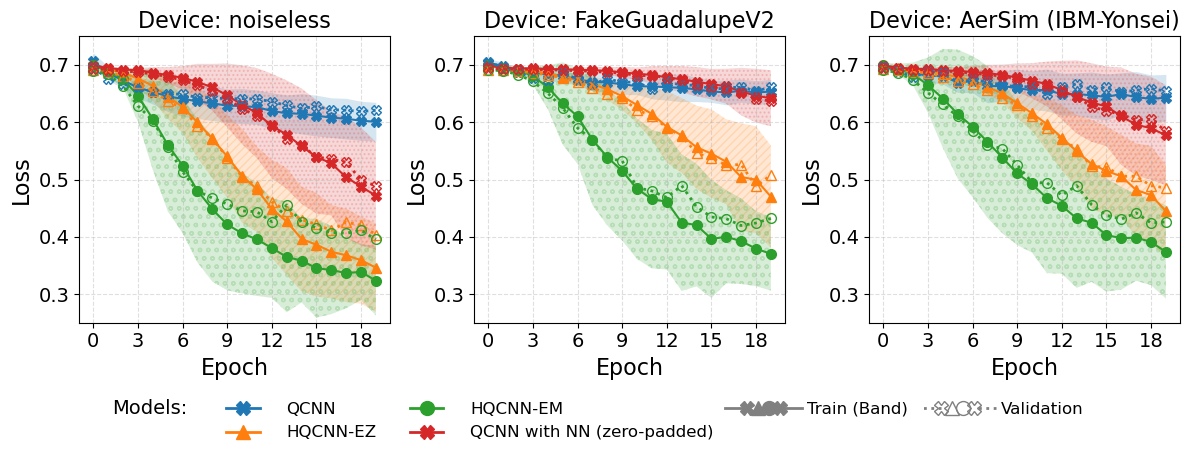

In [14]:
import matplotlib.pyplot as plt

CONV_FILTER = 'ConvSimple'
loss_df_combined = pd.concat([loss_df, loss_df_fb_zp], ignore_index=True)
# loss_df_combined = pd.concat([loss_df, loss_df_fb_zp, loss_df_fb_hl0], ignore_index=True)

# === FONT SIZE SETTINGS (centralized here) ===
title_font      = 20   # shared figure title
subplot_title   = 16   # per-device title
axis_label_font = 16   # x/y axis label
tick_font       = 14    # axis tick labels
legend_font     = 12    # legend text
legend_title    = 12   # legend title (if shown)


for num_qubit in [10]:
    # === Create subplots ===
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    legend_handles = None  # prepare to store legend once
    legend_labels = None

    for i, ax in enumerate(axes):
        device = loss_df_combined['Device'].unique()[i]

        # draw into this subplot
        legend_handles, legend_labels = plot_loss_curves_type2_filtered(
            loss_df = loss_df_combined,
            num_qubit=num_qubit,
            device=device,
            conv_filter_str=CONV_FILTER,
            plot_title=None,
            legend_show=False,
            plot_save=False,
            ax=ax
        )

        # per-subplot title
        ax.set_title(f"Device: {device}", fontsize=subplot_title)

        # axis labels
        ax.set_xlabel("Epoch", fontsize=axis_label_font)
        ax.set_ylabel("Loss", fontsize=axis_label_font)

        # tick label sizes
        ax.tick_params(axis='both', which='major', labelsize=tick_font)

    # ---- Shared figure title ----
    # fig.suptitle("Training & Validation Loss of 3 Models (eight-qubit circuit)",
    #              fontsize=title_font, y=0.96)

    # ---- Shared legend using returned handles ----
    # reordered_labels = [legend_labels[i] for i in [0, 3, 1, 2, 4, 5]]
    if legend_handles:
        fig.legend(
            handles=legend_handles,
            labels=legend_labels,
            handler_map={tuple: HandlerTuple(ndivide=None, pad=2.0)},
            loc='upper center',
            bbox_to_anchor=(0.55, 0.02),
            ncol=4,
            frameon=False,
            # title="Models",
            title_fontsize=legend_title,
            fontsize=legend_font,
            
            # NEW: make legend samples bigger so dashed lines are visible
            handlelength=2.0,   # longer line segment -> clearer dashes
            markerscale=1.0,    # bigger marker in legend
            handletextpad=1.6,  # spacing between handle and text
            columnspacing=2.0   # spacing between legend columns
        )
        
        # Add external text label on the left or right side of the legend
        fig.text(0.16, -0.035, "Models:", ha='right', va='center', fontsize=legend_font+2)  # adjust x,y as needed

    # layout adjustment
    plt.tight_layout()

    # ---- SAVE PLOT AS PDF ----
    if PLOT_SAVE:
        filename = (save_summary_results_dirs + f'Loss_{problem_type}_Models-q{num_qubit}_fb.pdf')
        fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
        print(f"Plot saved as {filename}")

    plt.show()

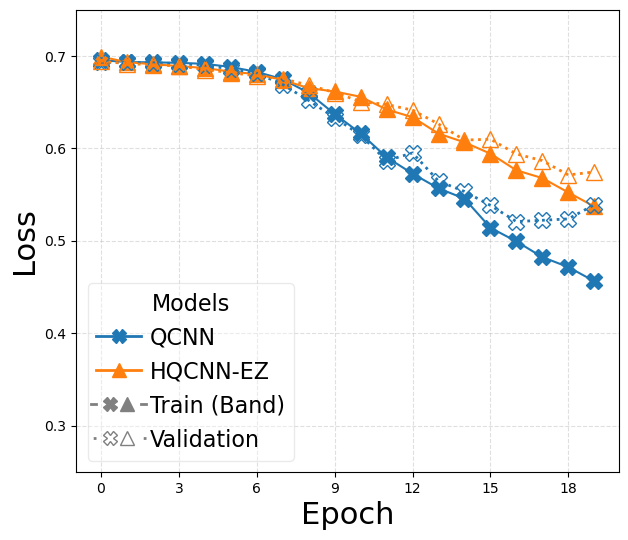

In [15]:
# Plot loss curves for each device and each convolution filter
conv_filters = ['ConvSimple']
for num_qubit in [4]:
    for device_name in ['IBM Yonsei']:
        for conv_filter in conv_filters:
            plot_loss_curves_type2_filtered(loss_df_fb_r4, 
                                            num_qubit, device_name, conv_filter,
                                            # plot_title="Device: IBM Yonsei",
                                            markersize=12,
                                            plot_title=None,
                                            legend_show=True,
                                            plot_save=PLOT_SAVE)

Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Loss_clf_Models-q10_fb2.pdf


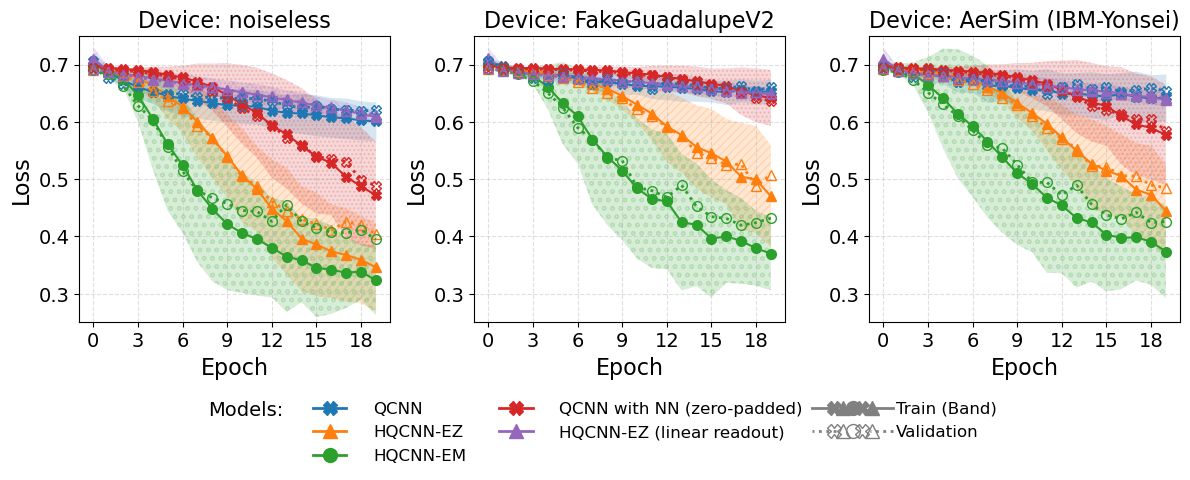

In [16]:
import matplotlib.pyplot as plt

CONV_FILTER = 'ConvSimple'
# loss_df_combined = pd.concat([loss_df, loss_df_fb_zp], ignore_index=True)
loss_df_combined = pd.concat([loss_df, loss_df_fb_zp, loss_df_fb_hl0], ignore_index=True)

# === FONT SIZE SETTINGS (centralized here) ===
title_font      = 20   # shared figure title
subplot_title   = 16   # per-device title
axis_label_font = 16   # x/y axis label
tick_font       = 14    # axis tick labels
legend_font     = 12    # legend text
legend_title    = 12   # legend title (if shown)


for num_qubit in [10]:
    # === Create subplots ===
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    legend_handles = None  # prepare to store legend once
    legend_labels = None

    for i, ax in enumerate(axes):
        device = loss_df_combined['Device'].unique()[i]

        # draw into this subplot
        legend_handles, legend_labels = plot_loss_curves_type2_filtered(
            loss_df = loss_df_combined,
            num_qubit=num_qubit,
            device=device,
            conv_filter_str=CONV_FILTER,
            plot_title=None,
            legend_show=False,
            plot_save=False,
            ax=ax
        )

        # per-subplot title
        ax.set_title(f"Device: {device}", fontsize=subplot_title)

        # axis labels
        ax.set_xlabel("Epoch", fontsize=axis_label_font)
        ax.set_ylabel("Loss", fontsize=axis_label_font)

        # tick label sizes
        ax.tick_params(axis='both', which='major', labelsize=tick_font)

    # ---- Shared figure title ----
    # fig.suptitle("Training & Validation Loss of 3 Models (eight-qubit circuit)",
    #              fontsize=title_font, y=0.96)

    # ---- Shared legend using returned handles ----
    # reordered_labels = [legend_labels[i] for i in [0, 3, 1, 2, 4, 5]]
    if legend_handles:
        fig.legend(
            handles=legend_handles,
            labels=legend_labels,
            handler_map={tuple: HandlerTuple(ndivide=None, pad=2.0)},
            loc='upper center',
            bbox_to_anchor=(0.55, 0.02),
            ncol=3,
            frameon=False,
            # title="Models",
            title_fontsize=legend_title,
            fontsize=legend_font,
            
            # NEW: make legend samples bigger so dashed lines are visible
            handlelength=2.0,   # longer line segment -> clearer dashes
            markerscale=1.0,    # bigger marker in legend
            handletextpad=1.6,  # spacing between handle and text
            columnspacing=2.0   # spacing between legend columns
        )
        
        # Add external text label on the left or right side of the legend
        fig.text(0.24, -0.04, "Models:", ha='right', va='center', fontsize=legend_font+2)  # adjust x,y as needed

    # layout adjustment
    plt.tight_layout()

    # ---- SAVE PLOT AS PDF ----
    if PLOT_SAVE:
        filename = (save_summary_results_dirs + f'Loss_{problem_type}_Models-q{num_qubit}_fb2.pdf')
        fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
        print(f"Plot saved as {filename}")

    plt.show()

### Performance Summary

In [17]:
# performance_df, performance_best_df
# performance_df_fb_zp, performance_best_df_fb_zp

In [18]:
performance_best_df_combined = pd.concat([performance_best_df, performance_df_fb_zp],
                                         ignore_index=True)
performance_best_df_combined2 = pd.concat([performance_best_df, performance_df_fb_zp, performance_df_fb_hl0],
                                         ignore_index=True)

In [19]:
# performance_best_df_combined
if SUMMRAY_TABLE_SAVE == True:
    performance_best_df_combined2.to_csv(save_summary_results_dirs+'performance_best_df_combined2.csv', encoding="utf-8-sig")

In [20]:
import pandas as pd

def summarize_performance(performance_df, problem_type="reg"):

    if problem_type == 'reg':
        # Metrics of interest
        mean_values = ['MAE', 'MSE', 'R-squared', 'Adj R-squared']
        
        # Mean & std
        group_by_features = ['Device', 'Dataset', 'Model', 'Qubits']
        # group_by_features = ['Device', 'Dataset', 'Model', 'Model_spec']
        summary_mean = performance_df.groupby(group_by_features)[mean_values].mean()
        summary_std = performance_df.groupby(group_by_features)[mean_values].std()

        # Rename std columns
        summary_std = summary_std.rename(columns={
            'MAE': 'MAE_std', 
            'MSE': 'MSE_std', 
            'R-squared': 'R-squared_std', 
            'Adj R-squared': 'Adj R-squared_std'
        })

        # Combine mean & std
        summary = pd.concat([summary_mean, summary_std], axis=1)

        # Round for readability
        summary = summary.round(6)

        # Column order
        summary = summary[[
            'MAE', 'MAE_std', 
            'MSE', 'MSE_std', 
            'R-squared', 'R-squared_std', 
            'Adj R-squared', 'Adj R-squared_std'
        ]]

        # Sort index
        summary = summary.sort_index(
            level=['Device', 'Dataset', 'Model'],
            ascending=[False, False, True])

    elif problem_type == 'clf':
        # Metrics of interest
        mean_values = ['binary_cross_entropy_loss', 'accuracy']
        
        # Mean & std
        group_by_features = ['Device', 'Dataset', 'Model', 'Qubits']
        # group_by_features = ['Device', 'Dataset', 'Model', 'Model_spec']
        summary_mean = performance_df.groupby(group_by_features)[mean_values].mean()
        summary_std = performance_df.groupby(group_by_features)[mean_values].std()

        # Rename std columns
        summary_std = summary_std.rename(columns={
            'binary_cross_entropy_loss': 'binary_cross_entropy_loss_std',
            'accuracy': 'accuracy_std'
        })

        # Combine mean & std
        summary = pd.concat([summary_mean, summary_std], axis=1)

        # Round for readability
        summary = summary.round(6)

        # Column order
        summary = summary[
            ['binary_cross_entropy_loss', 'binary_cross_entropy_loss_std',
             'accuracy', 'accuracy_std']
        ]

        # Sort index
        summary = summary.sort_index(
            level=['Device', 'Dataset', 'Model', 'Qubits'],
            ascending=[False, False, False, True]
            # level=['Device', 'Dataset', 'Model', 'Model_spec'],
            # ascending=[False, False, True, False]
        )

    else:
        raise ValueError("problem_type must be either 'reg' or 'clf'")

    return summary

In [21]:
# summary = summarize_performance(performance_df, problem_type=problem_type)
# summary

In [22]:
summary_best = summarize_performance(performance_best_df_combined, problem_type=problem_type)
summary_best

summary_best2 = summarize_performance(performance_best_df_combined2, problem_type=problem_type)
summary_best2

binary_cross_entropy_loss  \
Device              Dataset Model                      Qubits                              
noiseless           Train   QCNN with NN (zero-padded) 10                       0.460611   
                            QCNN                       4                        0.518761   
                                                       8                        0.610053   
                                                       10                       0.602629   
                            HQCNN-EZ (linear readout)  10                       0.603429   
...                                                                                  ...   
AerSim (IBM-Yonsei) Test    HQCNN-EZ                   8                        0.454871   
                                                       10                       0.431492   
                            HQCNN-EM                   4                        0.288227   
                                                       8                        0.298204   
                                                       10                       0.342997   

                                                               binary_cross_entropy_loss_std  \
Device              Dataset Model                      Qubits                                  
noiseless           Train   QCNN with NN (zero-padded) 10                           0.087506   
                            QCNN                       4                            0.033511   
                                                       8                            0.012880   
                                                       10                           0.033342   
                            HQCNN-EZ (linear readout)  10                           0.011600   
...                                                                                      ...   
AerSim (IBM-Yonsei) Test    HQCNN-EZ                   8                            0.094542   
                                                       10                           0.109168   
                            HQCNN-EM                   4                            0.021166   
                                                       8                            0.038515   
                                                       10                           0.104342   

                                                               accuracy  \
Device              Dataset Model                      Qubits             
noiseless           Train   QCNN with NN (zero-padded) 10          86.1   
                            QCNN                       4           85.2   
                                                       8           85.0   
                                                       10          67.8   
                            HQCNN-EZ (linear readout)  10          86.5   
...                                                                 ...   
AerSim (IBM-Yonsei) Test    HQCNN-EZ                   8           90.1   
                                                       10          87.6   
                            HQCNN-EM                   4           92.8   
                                                       8           91.8   
                                                       10          90.1   

                                                               accuracy_std  
Device              Dataset Model                      Qubits                
noiseless           Train   QCNN with NN (zero-padded) 10          3.150397  
                            QCNN                       4           1.151086  
                                                       8           2.761340  
                                                       10         15.738488  
                            HQCNN-EZ (linear readout)  10          2.318405  
...                                                                     ...  
AerSim (IBM-Yonse

In [23]:
summary_best_r4 = summarize_performance(performance_best_df_fb_r4, problem_type=problem_type)
summary_best_r4

binary_cross_entropy_loss  \
Device     Dataset Model    Qubits                              
IBM Yonsei Train   QCNN     4                        0.482105   
                   HQCNN-EZ 4                        0.535698   
           Test    QCNN     4                        0.436845   
                   HQCNN-EZ 4                        0.502663   

                                    binary_cross_entropy_loss_std  accuracy  \
Device     Dataset Model    Qubits                                            
IBM Yonsei Train   QCNN     4                                 NaN      84.0   
                   HQCNN-EZ 4                                 NaN      84.5   
           Test    QCNN     4                                 NaN      90.5   
                   HQCNN-EZ 4                                 NaN      93.0   

                                    accuracy_std  
Device     Dataset Model    Qubits                
IBM Yonsei Train   QCNN     4                NaN  
                   HQCNN-EZ 4                NaN  
           Test    QCNN     4                NaN  
                   HQCNN-EZ 4                NaN

In [24]:
import pandas as pd
from collections.abc import Iterable

def summarize_performance_compact(
    performance_df,
    problem_type,   # 'clf' or 'reg' 
    qubits=None,
    verbose=False,
    round_digits=6,
    sort_levels=None,
    sort_order=None,
    model_order=None # <-- NEW PARAMETER
):
    df = performance_df.copy()

    # Filter specific qubits
    if qubits is not None:
        if isinstance(qubits, Iterable) and not isinstance(qubits, (str, bytes)):
            qset = list(qubits)
        else:
            qset = [int(qubits)]
        df = df[df['Qubits'].isin(qset)]
        if verbose:
            print("Filtering to Qubits =", sorted(df['Qubits'].unique().tolist()))

    if problem_type == 'clf':
        metrics = ['binary_cross_entropy_loss', 'accuracy']
    elif problem_type == 'reg':
        metrics = ['MAE', 'MSE', 'R-squared', 'Adj R-squared']
        
    group_by_features = ['Device', 'Dataset', 'Model', 'Qubits']

    # NEW: Apply custom ordering to the Model column using Categorical
    if model_order is not None:
        df['Model'] = pd.Categorical(df['Model'], categories=model_order, ordered=True)

    summary_stats = df.groupby(group_by_features, observed=True)[metrics].agg(['mean','std'])

    # Build compact "mean ± std" strings
    compact = pd.DataFrame(index=summary_stats.index)
    for m in metrics:
        mu = summary_stats[(m, 'mean')].round(round_digits)
        sd = summary_stats[(m, 'std')].round(round_digits)
        compact[m] = mu.astype(str) + " ± " + sd.astype(str)

    # Sort index if requested
    if sort_levels is not None:
        if sort_order is None:
            sort_order = [True] * len(sort_levels)
        compact = compact.sort_index(level=sort_levels, ascending=sort_order)

    return compact

In [25]:
performance_best_summary = summarize_performance_compact(
    performance_df=performance_best_df_combined,
    problem_type='clf',
    sort_levels=['Device', 'Dataset', 'Model'],
    model_order=['QCNN', 'HQCNN-EZ', 'HQCNN-EM', 'QCNN with NN (zero-padded)']
)

performance_best_summary

performance_best_summary2 = summarize_performance_compact(
    performance_df=performance_best_df_combined2,
    problem_type='clf',
    sort_levels=['Device', 'Dataset', 'Model'],
    model_order=['QCNN', 'HQCNN-EZ', 'HQCNN-EM', 'QCNN with NN (zero-padded)', 'HQCNN-EZ (linear readout)']
)

performance_best_summary2

binary_cross_entropy_loss  \
Device              Dataset Model                      Qubits                             
AerSim (IBM-Yonsei) Test    QCNN                       4            0.560232 ± 0.031443   
                                                       8            0.663164 ± 0.015719   
                                                       10            0.64394 ± 0.033608   
                            HQCNN-EZ                   4            0.437493 ± 0.151261   
                                                       8            0.454871 ± 0.094542   
...                                                                                 ...   
noiseless           Train   HQCNN-EM                   4            0.378507 ± 0.014859   
                                                       8            0.324174 ± 0.015788   
                                                       10           0.326461 ± 0.052991   
                            QCNN with NN (zero-padded) 10           0.460611 ± 0.087506   
                            HQCNN-EZ (linear readout)  10             0.603429 ± 0.0116   

                                                                      accuracy  
Device              Dataset Model                      Qubits                   
AerSim (IBM-Yonsei) Test    QCNN                       4       89.8 ± 2.018663  
                                                       8        66.1 ± 6.94982  
                                                       10       62.1 ± 5.59464  
                            HQCNN-EZ                   4       90.3 ± 4.396021  
                                                       8       90.1 ± 3.110466  
...                                                                        ...  
noiseless           Train   HQCNN-EM                   4       84.7 ± 1.204159  
                                                       8        85.9 ± 0.74162  
                                                       10       88.2 ± 0.67082  
                            QCNN with NN (zero-padded) 10      86.1 ± 3.150397  
                            HQCNN-EZ (linear readout)  10      86.5 ± 2.318405  

[66 rows x 2 columns]

In [26]:
if SUMMRAY_TABLE_SAVE == True:
    # performance_summary.to_csv(save_summary_results_dirs+'performance_summary_train.csv', encoding="utf-8-sig")
    performance_best_summary.to_csv(save_summary_results_dirs+'performance_best_summary_test.csv', encoding="utf-8-sig")

In [27]:
import pandas as pd

def format_performance_summary(
    performance_summary: pd.DataFrame,
    problem_type: str = "clf",
    qubit_order: list[int] = [4, 8, 10],
    model_order: list[str] = None  # <--- NEW PARAMETER
) -> pd.DataFrame:
    
    # 1. Reset the index first so 'Model' is a normal column
    df_flat = performance_summary.reset_index()
    
    # 2. Convert 'Model' to an ordered Categorical column
    if model_order is not None:
        df_flat['Model'] = pd.Categorical(df_flat['Model'], categories=model_order, ordered=True)

    if problem_type == 'clf':
        task_name = "Classification Task"
        
        # Use df_flat instead of performance_summary.reset_index()
        wide = df_flat.pivot(
              index=['Dataset', 'Device', 'Model'],
              columns='Qubits',
              values=['binary_cross_entropy_loss', 'accuracy']
          )

        # Reorder columns (Qubits -> Metric)
        wide = wide.swaplevel(0, 1, axis=1)
        wide = wide.reindex(qubit_order, axis=1, level=0)

        # Rename metrics (fixed order)
        wide = wide.rename(columns={
            'binary_cross_entropy_loss': 'BCE',
            'accuracy': 'Accuracy'
            })
        metric_order = ["BCE", "Accuracy"]

        # Rebuild hierarchical columns: Task -> Qubits -> Metric
        wide.columns = pd.MultiIndex.from_product(
            [[task_name], qubit_order, metric_order],
            names=["Task", "Qubits", "Metric"]
            )

        # Sort index: Dataset (descending), Device (descending), Model (ASCENDING to keep your list order!)
        wide = wide.sort_index(level=["Dataset", "Device", 'Model'], ascending=[False, False, True])
    
    elif problem_type == 'reg':
        task_name = "Regression Task"
        
        # Use df_flat instead of performance_summary.reset_index()
        wide = df_flat.pivot(
              index=['Dataset', 'Device', 'Model'],
              columns='Qubits',
              values=['MAE', 'MSE', 'R-squared', 'Adj R-squared']
          )
        
        # Reorder columns (Qubits -> Metric)
        wide = wide.swaplevel(0, 1, axis=1)
        wide = wide.reindex(qubit_order, axis=1, level=0)

        # Rename metrics (fixed order)
        wide = wide.rename(columns={
            'MAE': 'MAE',
            'MSE': 'MSE',
            'R-squared': 'R-squared',
            'Adj R-squared': 'Adj R-squared'
            })
        metric_order = ["MAE", "MSE", "R-squared", "Adj R-squared"]

        # Rebuild hierarchical columns: Task -> Qubits -> Metric
        wide.columns = pd.MultiIndex.from_product(
            [[task_name], qubit_order, metric_order],
            names=["Task", "Qubits", "Metric"]
        )

        # Sort index: Dataset (descending), Device (descending), Model (ASCENDING to keep your list order!)
        wide = wide.sort_index(level=["Dataset", "Device", 'Model'], ascending=[False, False, True])
    
    return wide

In [28]:
# performance_summary_formated = format_performance_summary(
#     performance_summary,
#     problem_type=problem_type,
#     qubit_order=num_qubits
# )

# performance_best_summary_formated = format_performance_summary(
#     performance_best_summary,
#     problem_type=problem_type,
#     qubit_order=num_qubits
# )

performance_best_r4_summary_formated = format_performance_summary(
    performance_summary=performance_best_summary,
    problem_type=problem_type,
    qubit_order=num_qubits,
    model_order=['QCNN', 'HQCNN-EZ', 'HQCNN-EM', 'QCNN with NN (zero-padded)']
)
performance_best_r4_summary_formated

performance_best_summary_formated2 = format_performance_summary(
    performance_summary=performance_best_summary2,
    problem_type=problem_type,
    qubit_order=num_qubits,
    model_order=['QCNN', 'HQCNN-EZ', 'HQCNN-EM', 'QCNN with NN (zero-padded)', 'HQCNN-EZ (linear readout)']
)
performance_best_summary_formated2

Task                                                    Classification Task  \
Qubits                                                                   4    
Metric                                                                  BCE   
Dataset Device              Model                                             
Train   noiseless           QCNN                        0.518761 ± 0.033511   
                            HQCNN-EZ                    0.442718 ± 0.091653   
                            HQCNN-EM                    0.378507 ± 0.014859   
                            QCNN with NN (zero-padded)                  NaN   
                            HQCNN-EZ (linear readout)                   NaN   
        FakeGuadalupeV2     QCNN                        0.562231 ± 0.031234   
                            HQCNN-EZ                    0.485123 ± 0.103874   
                            HQCNN-EM                    0.405063 ± 0.031743   
                            QCNN with NN (zero-padded)                  NaN   
                            HQCNN-EZ (linear readout)                   NaN   
        AerSim (IBM-Yonsei) QCNN                        0.585169 ± 0.026222   
                            HQCNN-EZ                    0.495556 ± 0.113084   
                            HQCNN-EM                     0.403149 ± 0.01497   
                            QCNN with NN (zero-padded)                  NaN   
                            HQCNN-EZ (linear readout)                   NaN   
Test    noiseless           QCNN                         0.470579 ± 0.04784   
                            HQCNN-EZ                    0.357067 ± 0.126794   
                            HQCNN-EM                    0.252949 ± 0.015989   
                            QCNN with NN (zero-padded)                  NaN   
                            HQCNN-EZ (linear readout)                   NaN   
        FakeGuadalupeV2     QCNN                         0.52074 ± 0.037759   
                            HQCNN-EZ                    0.422663 ± 0.140843   
                            HQCNN-EM                     0.29474 ± 0.043618   
                            QCNN with NN (zero-padded)                  NaN   
                            HQCNN-EZ (linear readout)                   NaN   
        AerSim (IBM-Yonsei) QCNN                        0.560232 ± 0.031443   
                            HQCNN-EZ                    0.437493 ± 0.151261   
                            HQCNN-EM                    0.288227 ± 0.021166   
                            QCNN with NN (zero-padded)                  NaN   
                            HQCNN-EZ (linear readout)                   NaN   

Task                                                                     \
Qubits                                                                    
Metric                                                         Accuracy   
Dataset Device              Model                                         
Train   noiseless           QCNN                        85.2 ± 1.151086   
                            HQCNN-EZ                     84.4 ± 0.65192   
                            HQCNN-EM                    84.7 ± 1.204159   
                            QCNN with NN (zero-padded)              NaN   
                            HQCNN-EZ (linear readout)               NaN   
        FakeGuadalupeV2     QCNN                        83.3 ± 2.109502   
                            HQCNN-EZ                    84.2 ± 0.908295   
                            HQCNN-EM                    85.5 ± 0.612372   
                            QCNN with NN (zero-padded)              NaN   
                            HQCNN-EZ (linear readout)               NaN   
        AerSim (IBM-Yonsei) QCNN                        82.8 ± 2.280351   
                            HQCNN-EZ                    81.8 ± 4.396021   
                            HQCNN-EM                     85.1 ± 0.65192   
                            QCNN with 

In [29]:
if SUMMRAY_TABLE_SAVE == True:
    # performance_summary_formated.to_csv(save_summary_results_dirs+'performance_summary_formated.csv', encoding="utf-8-sig")
    performance_best_summary_formated2.to_csv(save_summary_results_dirs+'performance_best_summary_formated2.csv', encoding="utf-8-sig")

In [30]:
import pandas as pd

def summarize_performance_r4(performance_df, problem_type="reg"):

    if problem_type == 'reg':
        # Metrics of interest
        mean_values = ['MAE', 'MSE', 'R-squared', 'Adj R-squared']
        
        # Mean & std
        group_by_features = ['Device', 'Dataset', 'Model', 'Qubits']
        # group_by_features = ['Device', 'Dataset', 'Model', 'Model_spec']
        summary_mean = performance_df.groupby(group_by_features)[mean_values].mean()
        summary_std = performance_df.groupby(group_by_features)[mean_values].std()

        # Rename std columns
        summary_std = summary_std.rename(columns={
            'MAE': 'MAE_std', 
            'MSE': 'MSE_std', 
            'R-squared': 'R-squared_std', 
            'Adj R-squared': 'Adj R-squared_std'
        })

        # Combine mean & std
        summary = pd.concat([summary_mean, summary_std], axis=1)

        # Round for readability
        summary = summary.round(6)

        # Column order
        summary = summary[[
            'MAE', 'MAE_std', 
            'MSE', 'MSE_std', 
            'R-squared', 'R-squared_std', 
            'Adj R-squared', 'Adj R-squared_std'
        ]]

        # Sort index
        summary = summary.sort_index(
            level=['Device', 'Dataset', 'Model'],
            ascending=[False, False, True])

    elif problem_type == 'clf':
        # Metrics of interest
        mean_values = ['binary_cross_entropy_loss', 'accuracy']
        
        # Mean & std
        group_by_features = ['Device', 'Dataset', 'Model', 'Qubits']
        # group_by_features = ['Device', 'Dataset', 'Model', 'Model_spec']
        summary_mean = performance_df.groupby(group_by_features)[mean_values].mean()
        # summary_std = performance_df.groupby(group_by_features)[mean_values].std()

        # # Rename std columns
        # summary_std = summary_std.rename(columns={
        #     'binary_cross_entropy_loss': 'binary_cross_entropy_loss_std',
        #     'accuracy': 'accuracy_std'
        # })

        # # Combine mean & std
        # summary = pd.concat([summary_mean, summary_std], axis=1)
        summary = pd.concat([summary_mean], axis=1)

        # Round for readability
        summary = summary.round(6)

        # Column order
        summary = summary[
                    ['binary_cross_entropy_loss', 'accuracy']
                ]
        # summary = summary[
        #     ['binary_cross_entropy_loss', 'binary_cross_entropy_loss_std',
        #      'accuracy', 'accuracy_std']
        # ]

        # Sort index
        summary = summary.sort_index(
            level=['Device', 'Dataset', 'Model', 'Qubits'],
            ascending=[False, False, False, True]
            # level=['Device', 'Dataset', 'Model', 'Model_spec'],
            # ascending=[False, False, True, False]
        )

    else:
        raise ValueError("problem_type must be either 'reg' or 'clf'")

    return summary

In [31]:
summary_best_r4 = summarize_performance_r4(performance_best_df_fb_r4, 
                                           problem_type=problem_type)
summary_best_r4

binary_cross_entropy_loss  accuracy
Device     Dataset Model    Qubits                                     
IBM Yonsei Train   QCNN     4                        0.482105      84.0
                   HQCNN-EZ 4                        0.535698      84.5
           Test    QCNN     4                        0.436845      90.5
                   HQCNN-EZ 4                        0.502663      93.0

In [32]:
import pandas as pd

def format_performance_r4_summary(
    performance_summary: pd.DataFrame,
    problem_type: str = "clf",
    qubit_order: list[int] = [4]
) -> pd.DataFrame:
    """
    Reformat performance summary DataFrame into hierarchical MultiIndex columns:
    Task -> Qubits -> Metrics
    
    Parameters
    ----------
    performance_summary : pd.DataFrame
        Compact summary from summarize_performance_compact
    problem_type : str, default "clf". Other value is "Regression Task"
        Label for the top-level column header
    qubit_order : list[int], default [4]
        Order of qubits to appear in columns
    
    Returns
    -------
    pd.DataFrame
        Formatted DataFrame with hierarchical MultiIndex columns
    """
    # Pivot to wide format with reordered index: Dataset → Device → Model
    if problem_type == 'clf':
        task_name = "Classification Task"
        
        wide = (
        performance_summary
          .reset_index()
          .pivot(
              index=['Dataset', 'Device', 'Model'],
              columns='Qubits',
              values=['binary_cross_entropy_loss', 'accuracy']
              )
          )

        # Reorder columns (Qubits -> Metric)
        wide = wide.swaplevel(0, 1, axis=1)
        wide = wide.reindex(qubit_order, axis=1, level=0)

        # Rename metrics (fixed order)
        wide = wide.rename(columns={
            'binary_cross_entropy_loss': 'BCE',
            'accuracy': 'Accuracy'
            })
        metric_order = ["BCE", "Accuracy"]

        # Rebuild hierarchical columns: Task -> Qubits -> Metric
        wide.columns = pd.MultiIndex.from_product(
            [[problem_type], qubit_order, metric_order],
            names=["Task", "Qubits", "Metric"]
            )

        # Sort index: Dataset (descending), Device (descending)
        wide = wide.sort_index(level=["Dataset", "Device", 'Model'], ascending=[False, False, False])
    
    elif problem_type == 'reg':
        task_name = "Classification Task"
        
        wide = (
        performance_summary
          .reset_index()
          .pivot(
              index=['Dataset', 'Device', 'Model'],
              columns='Qubits',
              values=['MAE', 'MSE', 'R-squared', 'Adj R-squared']
              )
          )
        
        # Reorder columns (Qubits -> Metric)
        wide = wide.swaplevel(0, 1, axis=1)
        wide = wide.reindex(qubit_order, axis=1, level=0)

        # Rename metrics (fixed order)
        wide = wide.rename(columns={
            'MAE': 'MAE',
            'MSE': 'MSE',
            'R-squared': 'R-squared',
            'Adj R-squared': 'Adj R-squared'
            })
        metric_order = ["MAE", "MSE", "R-squared", "Adj R-squared"]

        # Rebuild hierarchical columns: Task -> Qubits -> Metric
        wide.columns = pd.MultiIndex.from_product(
            [[problem_type], qubit_order, metric_order],
            names=["Task", "Qubits", "Metric"]
        )

        # Sort index: Dataset (descending), Device (descending)
        wide = wide.sort_index(level=["Dataset", "Device", 'Model'], ascending=[False, False, False])
    
    return wide

In [33]:
summary_best_r4

binary_cross_entropy_loss  accuracy
Device     Dataset Model    Qubits                                     
IBM Yonsei Train   QCNN     4                        0.482105      84.0
                   HQCNN-EZ 4                        0.535698      84.5
           Test    QCNN     4                        0.436845      90.5
                   HQCNN-EZ 4                        0.502663      93.0

In [34]:
performance_best_summary_r4_formated = format_performance_r4_summary(
    summary_best_r4,
    problem_type=problem_type,
    qubit_order=[4]
)

performance_best_summary_r4_formated

Task                              clf         
Qubits                              4         
Metric                            BCE Accuracy
Dataset Device     Model                      
Train   IBM Yonsei QCNN      0.482105     84.0
                   HQCNN-EZ  0.535698     84.5
Test    IBM Yonsei QCNN      0.436845     90.5
                   HQCNN-EZ  0.502663     93.0

In [35]:
if SUMMRAY_TABLE_SAVE == True:
    performance_best_summary_r4_formated.to_csv(save_summary_results_dirs+'performance_best_summary_r4_formated.csv', encoding="utf-8-sig")

### Performance Comparison by model

In [36]:
import pandas as pd

def compare_model_performance(problem_type, performance_df):
    """
    Compare model performance between baseline ('QCNN') and
    proposed models ('HQCNN-EZ', 'HQCNN-EM').
    Computes absolute and percentage improvements in loss and accuracy.

    Parameters
    ----------
    problem_type : str, default "clf". Other value is "reg"
    performance_df : pd.DataFrame
        Input DataFrame with columns:
        ['Device','Qubits','sim_iter_num','Dataset','Model',
         'binary_cross_entropy_loss','accuracy']

    Returns
    -------
    pd.DataFrame
        DataFrame with improvements in loss and accuracy for each model
        relative to the baseline.
    """

    if problem_type == 'clf':
        # Filter to the three models
        filtered_df = performance_df[
            performance_df['Model'].isin(['QCNN', 'HQCNN-EZ', 'HQCNN-EM'])
            ]

        # Pivot for loss, accuracy
        bce_loss_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='binary_cross_entropy_loss',
            sort=False
            ).reset_index()

        accuracy_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='accuracy',
            sort=False
            ).reset_index()

        # Performance improvements
        bce_loss_pivot['Diff_loss_HQCNN-EZ'] = bce_loss_pivot['QCNN'] - bce_loss_pivot['HQCNN-EZ']
        bce_loss_pivot['%_loss_improve_HQCNN-EZ'] = (bce_loss_pivot['Diff_loss_HQCNN-EZ'] / bce_loss_pivot['QCNN']) * 100
        bce_loss_pivot['Diff_loss_HQCNN-EM'] = bce_loss_pivot['QCNN'] - bce_loss_pivot['HQCNN-EM']
        bce_loss_pivot['%_loss_improve_HQCNN-EM'] = (bce_loss_pivot['Diff_loss_HQCNN-EM'] / bce_loss_pivot['QCNN']) * 100

        accuracy_pivot['Diff_accu_HQCNN-EZ'] = accuracy_pivot['HQCNN-EZ'] - accuracy_pivot['QCNN']
        accuracy_pivot['%_accu_improve_HQCNN-EZ'] = (accuracy_pivot['Diff_accu_HQCNN-EZ'] / accuracy_pivot['QCNN']) * 100
        accuracy_pivot['Diff_accu_HQCNN-EM'] = accuracy_pivot['HQCNN-EM'] - accuracy_pivot['QCNN']
        accuracy_pivot['%_accu_improve_HQCNN-EM'] = (accuracy_pivot['Diff_accu_HQCNN-EM'] / accuracy_pivot['QCNN']) * 100

        # Merge results
        performance_comparison_df = pd.merge(
            bce_loss_pivot[['Device', 'Qubits', 'sim_iter_num', 'Dataset',
                        'Diff_loss_HQCNN-EZ', '%_loss_improve_HQCNN-EZ',
                        'Diff_loss_HQCNN-EM', '%_loss_improve_HQCNN-EM']],
            accuracy_pivot[['Device', 'Qubits', 'sim_iter_num', 'Dataset',
                            'Diff_accu_HQCNN-EZ', '%_accu_improve_HQCNN-EZ',
                            'Diff_accu_HQCNN-EM', '%_accu_improve_HQCNN-EM']],
            on=['Device', 'Qubits', 'sim_iter_num', 'Dataset']
            )

    elif problem_type == 'reg':
        # Filter to the three models
        filtered_df = performance_df[
            performance_df['Model'].isin(['QCNN', 'HQCNN-EZ', 'HQCNN-EM'])
        ]

        # Pivot for MAE, MSE, RMSE, R-Squared, Adj R-Squared
        mae_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='MAE',
            sort=False
        ).reset_index()
        
        mse_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='MSE',
            sort=False
        ).reset_index()
        
        rmse_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='RMSE',
            sort=False
        ).reset_index()
                
        r_squared_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='R-squared',
            sort=False
        ).reset_index()
                        
        adj_r_squared_pivot = filtered_df.pivot_table(
            index=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Model',
            values='Adj R-squared',
            sort=False
        ).reset_index()

        # Performance improvements
        mae_pivot['Diff_mae_HQCNN-EZ'] = mae_pivot['QCNN'] - mae_pivot['HQCNN-EZ']
        mae_pivot['%_mae_improve_HQCNN-EZ'] = (mae_pivot['Diff_mae_HQCNN-EZ'] / mae_pivot['QCNN']) * 100
        mae_pivot['Diff_mae_HQCNN-EM'] = mae_pivot['QCNN'] - mae_pivot['HQCNN-EM']
        mae_pivot['%_mae_improve_HQCNN-EM'] = (mae_pivot['Diff_mae_HQCNN-EM'] / mae_pivot['QCNN']) * 100
        
        mse_pivot['Diff_mse_HQCNN-EZ'] = mse_pivot['QCNN'] - mse_pivot['HQCNN-EZ']
        mse_pivot['%_mse_improve_HQCNN-EZ'] = (mse_pivot['Diff_mse_HQCNN-EZ'] / mse_pivot['QCNN']) * 100
        mse_pivot['Diff_mse_HQCNN-EM'] = mse_pivot['QCNN'] - mse_pivot['HQCNN-EM']
        mse_pivot['%_mse_improve_HQCNN-EM'] = (mse_pivot['Diff_mse_HQCNN-EM'] / mse_pivot['QCNN']) * 100
        
        rmse_pivot['Diff_rmse_HQCNN-EZ'] = rmse_pivot['QCNN'] - rmse_pivot['HQCNN-EZ']
        rmse_pivot['%_rmse_improve_HQCNN-EZ'] = (rmse_pivot['Diff_rmse_HQCNN-EZ'] / rmse_pivot['QCNN']) * 100
        rmse_pivot['Diff_rmse_HQCNN-EM'] = rmse_pivot['QCNN'] - rmse_pivot['HQCNN-EM']
        rmse_pivot['%_rmse_improve_HQCNN-EM'] = (rmse_pivot['Diff_rmse_HQCNN-EM'] / rmse_pivot['QCNN']) * 100
        
        r_squared_pivot['Diff_r-squared_HQCNN-EZ'] = r_squared_pivot['HQCNN-EZ'] - r_squared_pivot['QCNN']
        r_squared_pivot['%_r-squared_improve_HQCNN-EZ'] = (r_squared_pivot['Diff_r-squared_HQCNN-EZ'] / r_squared_pivot['QCNN']) * 100
        r_squared_pivot['Diff_r-squared_HQCNN-EM'] = r_squared_pivot['HQCNN-EM'] - r_squared_pivot['QCNN']
        r_squared_pivot['%_r-squared_improve_HQCNN-EM'] = (r_squared_pivot['Diff_r-squared_HQCNN-EM'] / r_squared_pivot['QCNN']) * 100
        
        adj_r_squared_pivot['Diff_adj r-squared_HQCNN-EZ'] = adj_r_squared_pivot['HQCNN-EZ'] - adj_r_squared_pivot['QCNN']
        adj_r_squared_pivot['%_adj r-squared_improve_HQCNN-EZ'] = (adj_r_squared_pivot['Diff_adj r-squared_HQCNN-EZ'] / r_squared_pivot['QCNN']) * 100
        adj_r_squared_pivot['Diff_adj r-squared_HQCNN-EM'] = adj_r_squared_pivot['HQCNN-EM'] - adj_r_squared_pivot['QCNN']
        adj_r_squared_pivot['%_adj r-squared_improve_HQCNN-EM'] = (adj_r_squared_pivot['Diff_adj r-squared_HQCNN-EM'] / r_squared_pivot['QCNN']) * 100

        # Merge results
        key_cols = ['Device', 'Qubits', 'sim_iter_num', 'Dataset']
        performance_comparison_df = (
            mae_pivot[key_cols + [
                'Diff_mae_HQCNN-EZ', '%_mae_improve_HQCNN-EZ',
                'Diff_mae_HQCNN-EM', '%_mae_improve_HQCNN-EM'
            ]]
            .merge(
                mse_pivot[key_cols + [
                    'Diff_mse_HQCNN-EZ', '%_mse_improve_HQCNN-EZ',
                    'Diff_mse_HQCNN-EM', '%_mse_improve_HQCNN-EM'
                ]],
                on=key_cols, how='inner'
            )
            .merge(
                rmse_pivot[key_cols + [
                    'Diff_rmse_HQCNN-EZ', '%_rmse_improve_HQCNN-EZ',
                    'Diff_rmse_HQCNN-EM', '%_rmse_improve_HQCNN-EM'
                ]],
                on=key_cols, how='inner'
            )
            .merge(
                r_squared_pivot[key_cols + [
                    'Diff_r-squared_HQCNN-EZ', '%_r-squared_improve_HQCNN-EZ',
                    'Diff_r-squared_HQCNN-EM', '%_r-squared_improve_HQCNN-EM'
                ]],
                on=key_cols, how='inner'
            )
            .merge(
                adj_r_squared_pivot[key_cols + [
                    'Diff_adj r-squared_HQCNN-EZ', '%_adj r-squared_improve_HQCNN-EZ',
                    'Diff_adj r-squared_HQCNN-EM', '%_adj r-squared_improve_HQCNN-EM'
                ]],
                on=key_cols, how='inner'
            )
        )

    return performance_comparison_df

In [37]:
# performance_comparison_df = compare_model_performance(problem_type, performance_df)
# performance_comparison_df

In [38]:
# performance_best_df_combined

In [39]:
performance_best_comparison_df = compare_model_performance(problem_type, performance_best_df)
performance_best_comparison_df

Model,Device,Qubits,sim_iter_num,Dataset,Diff_loss_HQCNN-EZ,%_loss_improve_HQCNN-EZ,Diff_loss_HQCNN-EM,%_loss_improve_HQCNN-EM,Diff_accu_HQCNN-EZ,%_accu_improve_HQCNN-EZ,Diff_accu_HQCNN-EM,%_accu_improve_HQCNN-EM
0,noiseless,4,0,Train,0.049700,9.566129,0.165253,31.807249,-0.5,-0.584795,0.5,0.584795
1,noiseless,4,0,Test,0.085669,18.127789,0.242352,51.282487,0.5,0.543478,1.5,1.630435
2,noiseless,4,1,Train,-0.017158,-2.993199,0.196366,34.256190,1.0,1.190476,1.5,1.785714
3,noiseless,4,1,Test,-0.019857,-3.646543,0.284212,52.191607,0.0,0.000000,0.0,0.000000
4,noiseless,4,2,Train,0.130665,26.096221,0.108049,21.579381,-2.5,-2.873563,-2.0,-2.298851
...,...,...,...,...,...,...,...,...,...,...,...,...
85,AerSim (IBM-Yonsei),10,2,Test,0.175394,28.870296,0.340878,56.109287,31.5,56.250000,35.5,63.392857
86,AerSim (IBM-Yonsei),10,3,Train,0.242400,39.480917,0.130792,21.302776,28.0,47.863248,24.5,41.880342
87,AerSim (IBM-Yonsei),10,3,Test,0.292048,48.042752,0.134890,22.189816,35.5,62.280702,30.0,52.631579
88,AerSim (IBM-Yonsei),10,4,Train,0.123550,18.017046,0.399823,58.305464,24.5,43.362832,34.0,60.176991


In [40]:
if SUMMRAY_TABLE_SAVE == True:
    # performance_comparison_df.to_csv(save_summary_results_dirs+'performance_comparison.csv', encoding="utf-8-sig")
    performance_best_comparison_df.to_csv(save_summary_results_dirs+'performance_best_comparison_df.csv', encoding="utf-8-sig")

### Model improvements for each case

In [41]:
def plot_metric_improvement_by_device(
    df, 
    metric_diff_cols, 
    metric_label="Improvement", 
    x_axis_label="Diff.", 
    plot_title="Metric Improvement per Device", 
    filename_suffix="metric_improvement_by_device.png",
    plot_save=False,
    qubits=None,
    figsize=(8, 6),
    title_size=16,
    axis_label_size=12,
    tick_size=10,
    legend_size=10,
    legend_loc = 'best',
    dot_size=5
):
    import matplotlib.pyplot as plt
    import seaborn as sns
    from matplotlib.patches import Patch # Import Patch for custom legend entries

    # Optional filter by qubits
    if qubits is not None:
        df = df[df['Qubits'].isin(qubits)]

    # Melt the DataFrame
    melted_df = df.melt(
        id_vars=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
        value_vars=metric_diff_cols,
        var_name='Model_Comparison',
        value_name=metric_label
    )

    # Rename + enforce hue order
    rename_dict = {
        metric_diff_cols[0]: 'HQCNN-EZ',
        metric_diff_cols[1]: 'HQCNN-EM'
    }
    melted_df['Model_Comparison'] = melted_df['Model_Comparison'].replace(rename_dict)
    hue_order = ['HQCNN-EZ', 'HQCNN-EM']

    # Combine Device + Qubits for hierarchical y-axis
    melted_df['Device_Qubits'] = melted_df['Device'] + "\n q" + melted_df['Qubits'].astype(str)

    # Define hatch patterns for each model
    hatch_map = {
        'HQCNN-EZ': None, # No hatch for the first model
        'HQCNN-EM': '///' # Hatches for the second model
    }
    
    # Define colors explicitly for the legend, matching yol2t2e
    # You need to ensursssse these match the palette used in sns.barplot
    # sns.color_palette('pastel') gives a list of colors
    colors = sns.color_palette('pastel')
    color_map = {
        'HQCNN-EZ': colors[0], # First color in pastel palette
        'HQCNN-EM': colors[1]  # Second color in pastel palette
    }

    # Plot for each dataset type separately
    for dataset_type in ['Train', 'Test']:
        subset_df = melted_df[melted_df['Dataset'] == dataset_type].copy()
        if subset_df.empty:
            continue
        
        # Build a stable y order: sort by Device then Qubits
        subset_df['Device_Qubits'] = subset_df['Device'] + "\n q" + subset_df['Qubits'].astype(str)
        order_df = (
            subset_df[['Device', 'Qubits', 'Device_Qubits']]
            .drop_duplicates()
            .set_index('Device')
            .reset_index()
        )
        x_order = order_df['Device_Qubits'].tolist()
                
        # This will become the displayed y tick labels (repeated per device)
        x_ticklabels = [str(q) + "q" for q in order_df['Qubits'].tolist()]

        plt.figure(figsize=figsize)
        ax = sns.barplot(
            data=subset_df,
            x='Device_Qubits',
            y=metric_label,
            hue='Model_Comparison',
            hue_order=hue_order,
            order=x_order,
            palette=color_map,
            edgecolor='black',
            estimator='mean',
            errorbar='sd',
            orient='v'
        )
        
        # Apply hatches to the bars
        for i, bar_group in enumerate(ax.containers):
            model_name = hue_order[i] # Get the model name for the current container
            hatch_pattern = hatch_map.get(model_name) # Get the hatch pattern
            if hatch_pattern: # Only apply if a hatch pattern is defined
                for bar in bar_group:
                    bar.set_hatch(hatch_pattern)

        # Scatter points overlay
        sns.stripplot(
            data=subset_df,
            x='Device_Qubits',
            y=metric_label,
            hue='Model_Comparison',
            hue_order=hue_order,
            dodge=True,
            palette='dark',
            size=dot_size,
            alpha=0.6,
            legend=False,
        )
        
        ax.set_xticks(range(len(x_order)))
        ax.set_xticklabels(x_ticklabels, rotation=0)
        ax.set_xlabel(x_axis_label, fontsize=axis_label_size)
        ax.set_ylabel(metric_label, fontsize=axis_label_size)
        
        
        if plot_title:
            plt.title(f"{plot_title} in {dataset_type} Dataset", fontsize=title_size)
        plt.xlabel(x_axis_label, fontsize=axis_label_size)
        plt.xlabel('Device & Qubits', fontsize=axis_label_size, labelpad=30)
        plt.xticks(fontsize=tick_size)
        plt.yticks(fontsize=tick_size)
        plt.grid(axis='y')

        # Create a custom legend with hatches
        legend_handles = []
        for model_name in hue_order:
            patch = Patch(
                facecolor=color_map[model_name], # Use the color from your map
                edgecolor='black',
                hatch=hatch_map.get(model_name, None), # Get hatch from map, default to None
                label=model_name
            )
            legend_handles.append(patch)

        ax.legend(
            handles=legend_handles, # Pass the list of custom patches
            # title='Model Comparison',
            fontsize=legend_size,
            title_fontsize=legend_size,
            loc=legend_loc,
            bbox_to_anchor=(0.5, 1.08),
            ncol=2,
            framealpha=1
        )
        
        # ---- Secondary x-axis: Device group labels & separators (robust) ----
        # Use the plotted order (one entry per category on x)
        device_seq = order_df['Device'].tolist()          # length == len(x_order)

        # Get the actual x tick locations used by Matplotlib
        xticklocs = np.asarray(ax.get_xticks())
        if len(xticklocs) != len(device_seq):
            # Fallback to 0..N-1 if backend returns something unexpected
            xticklocs = np.arange(len(device_seq))

        # Compute a step size for edges (works even if spacing changes)
        if len(xticklocs) > 1:
            step = float(np.median(np.diff(xticklocs)))
        else:
            step = 1.0

        group_mids, group_labels, edges = [], [], [xticklocs[0] - 0.5 * step]
        start = 0
        for i in range(1, len(device_seq) + 1):
            if i == len(device_seq) or device_seq[i] != device_seq[start]:
                left = xticklocs[start]
                right = xticklocs[i - 1]
                group_mids.append((left + right) / 2.0)
                group_labels.append(device_seq[start])
                edges.append(right + 0.5 * step)
                start = i

        # Device names centered under their blocks
        sec = ax.secondary_xaxis(location=0)
        sec.set_xticks(group_mids, labels=group_labels, rotation=0)
        sec.tick_params(axis='x', length=0, pad=30, labelsize=tick_size)  # increase pad to lower the labels

        # Thick separator marks between device blocks
        sec2 = ax.secondary_xaxis(location=0)
        sec2.set_xticks(edges, labels=[])
        sec2.tick_params(axis='x', length=30, width=1.5)

        # Clean look: hide secondary spines
        for spine in ['left','right','top','bottom']:
            sec.spines[spine].set_visible(False)
            sec2.spines[spine].set_visible(False)
        # ---- END secondary x-axis block ----



        plt.tight_layout()
        # Save or show
        if plot_save:
            os.makedirs(save_dir, exist_ok=True)
            filename = os.path.join(
                save_summary_results_dirs, 
                filename_suffix.replace(".png", f"_q{'-'.join(map(str, qubits))}_{dataset_type}.png") if qubits else filename_suffix.replace(".png", f"_{dataset_type}.png"))
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Plot saved as {filename}")
        else:
            plt.show()

### Model improvements across devices and qubits

In [42]:
def plot_metric_improvement_by_device2(
    df, 
    metric_diff_cols, 
    metric_label="Improvement", 
    x_axis_label="Diff.", 
    plot_title="Metric Improvement per Device", 
    filename_suffix="metric_improvement_by_device.png",
    plot_save=False,
    qubits=None,
    figsize=(8, 6),
    title_size=16,
    axis_label_size=12,
    tick_size=10,
    legend_size=10,
    legend_loc='best',
    show_points=False,
    capsize=3,
    line_alpha=1.0,
    dodge=0.12,
    line_width=1.8,          # line width for the connecting line
    point_size=6,            # marker size (points)
    errorbar_width=1.2,      # whisker (vertical error line) width
    cap_thickness=1.2        # cap thickness
):
    import os
    import numpy as np
    import matplotlib.pyplot as plt
    import seaborn as sns

    if qubits is not None:
        df = df[df['Qubits'].isin(qubits)]

    melted_df = df.melt(
        id_vars=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
        value_vars=metric_diff_cols,
        var_name='Model_Comparison',
        value_name=metric_label
    )

    rename_dict = {
        metric_diff_cols[0]: 'HQCNN-EZ',
        metric_diff_cols[1]: 'HQCNN-EM'
    }
    melted_df['Model_Comparison'] = melted_df['Model_Comparison'].replace(rename_dict)
    hue_order = ['HQCNN-EZ', 'HQCNN-EM']

    melted_df['Device_Qubits'] = melted_df['Device'] + "\n q" + melted_df['Qubits'].astype(str)

    colors = sns.color_palette('deep', n_colors=2)
    color_map = {'HQCNN-EZ': colors[0], 'HQCNN-EM': colors[1]}

    style_map = {
        'HQCNN-EZ': {'marker': 'o', 'linestyle': '-'},
        'HQCNN-EM': {'marker': 's', 'linestyle': '--'}
    }

    dodge_map = {
        'HQCNN-EZ': -abs(dodge),
        'HQCNN-EM':  abs(dodge)
    }

    for dataset_type in ['Train', 'Test']:
        subset_df = melted_df[melted_df['Dataset'] == dataset_type].copy()
        if subset_df.empty:
            continue

        order_df = (
            subset_df[['Device', 'Qubits', 'Device_Qubits']]
            .drop_duplicates()
            .reset_index(drop=True)
        )
        x_order = order_df['Device_Qubits'].tolist()
        x_ticklabels = ["q" + str(q) for q in order_df['Qubits'].tolist()]

        summary = (
            subset_df
            .groupby(['Device', 'Device_Qubits', 'Model_Comparison'])[metric_label]
            .agg(mean='mean', sd='std')
            .reset_index()
        )

        x_pos_map = {cat: i for i, cat in enumerate(x_order)}
        x_positions = np.arange(len(x_order), dtype=float)

        plt.figure(figsize=figsize)
        ax = plt.gca()

        # device blocks (break lines across devices)
        device_seq = order_df['Device'].tolist()
        device_blocks = []
        start = 0
        for i in range(1, len(device_seq) + 1):
            if i == len(device_seq) or device_seq[i] != device_seq[start]:
                device_blocks.append(device_seq[start])
                start = i

        for model in hue_order:
            labeled = False
            mk = style_map[model]['marker']
            ls = style_map[model]['linestyle']
            dx = dodge_map.get(model, 0.0)

            for dev in device_blocks:
                s = summary[(summary['Model_Comparison'] == model) & (summary['Device'] == dev)].copy()
                if s.empty:
                    continue

                s['x'] = s['Device_Qubits'].map(x_pos_map)
                s = s.dropna(subset=['x']).sort_values('x')

                x = s['x'].to_numpy(dtype=float) + dx
                y_mean = s['mean'].to_numpy()
                y_sd = s['sd'].to_numpy()

                ax.errorbar(
                    x, y_mean, yerr=y_sd,
                    fmt=mk,
                    linestyle=ls,
                    capsize=capsize,
                    linewidth=line_width,
                    markersize=point_size,
                    label=(model if not labeled else None),
                    color=color_map[model],
                    alpha=line_alpha,
                    elinewidth=errorbar_width,
                    capthick=cap_thickness,
                    zorder=3
                )
                labeled = True

        # Optional raw points (also dodged so they align)
        if show_points:
            for model in hue_order:
                d = subset_df[subset_df['Model_Comparison'] == model].copy()
                if d.empty:
                    continue
                d['x'] = d['Device_Qubits'].map(x_pos_map)
                d = d.dropna(subset=['x'])
                ax.scatter(
                    d['x'].to_numpy(dtype=float) + dodge_map.get(model, 0.0),
                    d[metric_label].to_numpy(),
                    s=(point_size**2),  # marker area, not markersize
                    alpha=0.20,
                    color=color_map[model],
                    marker=style_map[model]['marker'],
                    edgecolors='none',
                    zorder=2
                )

        ax.set_xticks(x_positions)
        ax.set_xticklabels(x_ticklabels, rotation=0)

        ax.set_ylabel(metric_label, fontsize=axis_label_size)
        ax.set_xlabel('Device & Qubits', fontsize=axis_label_size, labelpad=30)

        if plot_title:
            ax.set_title(f"{plot_title} in {dataset_type} Dataset", fontsize=title_size)

        ax.tick_params(axis='x', labelsize=tick_size)
        ax.tick_params(axis='y', labelsize=tick_size)
        ax.grid(axis='y', zorder=0)

        ax.legend(
            fontsize=legend_size,
            loc=legend_loc,
            bbox_to_anchor=(0.5, 1.08),
            ncol=2,
            framealpha=1
        )

        # Secondary x-axis: device labels + separators
        xticklocs = np.asarray(ax.get_xticks(), dtype=float)
        if len(xticklocs) != len(device_seq):
            xticklocs = np.arange(len(device_seq), dtype=float)

        step = float(np.median(np.diff(xticklocs))) if len(xticklocs) > 1 else 1.0

        group_mids, group_labels, edges = [], [], [xticklocs[0] - 0.5 * step]
        start = 0
        for i in range(1, len(device_seq) + 1):
            if i == len(device_seq) or device_seq[i] != device_seq[start]:
                left = xticklocs[start]
                right = xticklocs[i - 1]
                group_mids.append((left + right) / 2.0)
                group_labels.append(device_seq[start])
                edges.append(right + 0.5 * step)
                start = i

        sec = ax.secondary_xaxis(location=0)
        sec.set_xticks(group_mids, labels=group_labels, rotation=0)
        sec.tick_params(axis='x', length=0, pad=30, labelsize=tick_size)

        sec2 = ax.secondary_xaxis(location=0)
        sec2.set_xticks(edges, labels=[])
        sec2.tick_params(axis='x', length=30, width=1.5)

        for spine in ['left', 'right', 'top', 'bottom']:
            sec.spines[spine].set_visible(False)
            sec2.spines[spine].set_visible(False)

        plt.tight_layout()

        if plot_save:
            os.makedirs(save_summary_results_dirs, exist_ok=True)
            filename = os.path.join(
                save_summary_results_dirs,
                filename_suffix.replace(
                    ".png",
                    f"_q{'-'.join(map(str, qubits))}_{dataset_type}.png"
                ) if qubits else filename_suffix.replace(".png", f"_{dataset_type}.png")
            )
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Plot saved as {filename}")
        else:
            plt.show()

In [43]:
# Diff_loss_HQCNN-EZ
# Diff_loss_HQCNN-EM
# %_loss_improve_HQCNN-EZ
# %_loss_improve_HQCNN-EM

# Diff_accu_HQCNN-EZ
# Diff_accu_HQCNN-EM
# %_accu_improve_HQCNN-EZ
# %_accu_improve_HQCNN-EM

# df_plot = performance_comparison_df
df_plot = performance_best_comparison_df
# df_plot

Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/bce_loss_improvement_by_device_and_qubits_q4-8-10_Train.png
Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/bce_loss_improvement_by_device_and_qubits_q4-8-10_Test.png
Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/accuracy_best_improvement_by_device_and_qubits_q4-8-10_Train.png
Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/accuracy_best_improvement_by_device_and_qubits_q4-8-10_Test.png


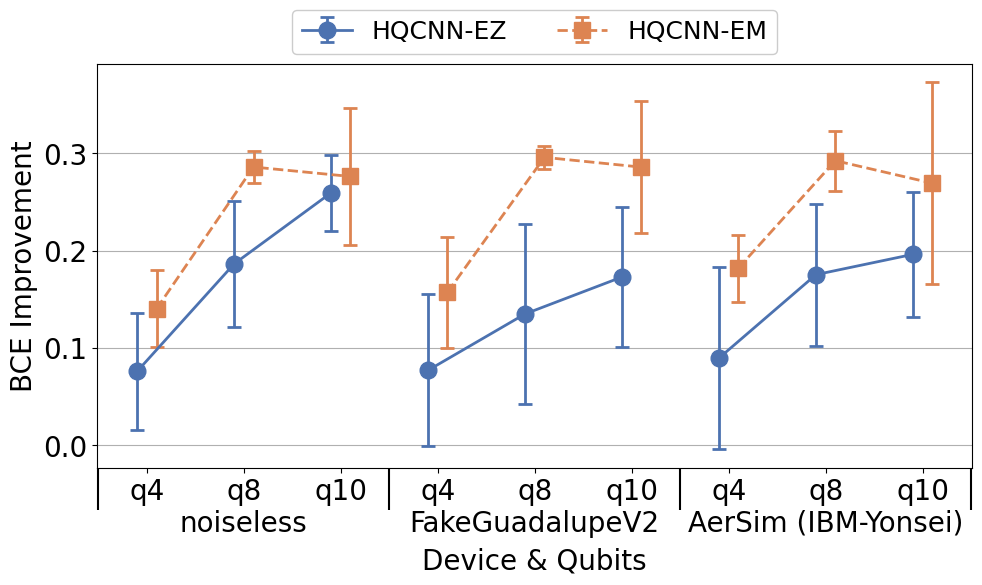

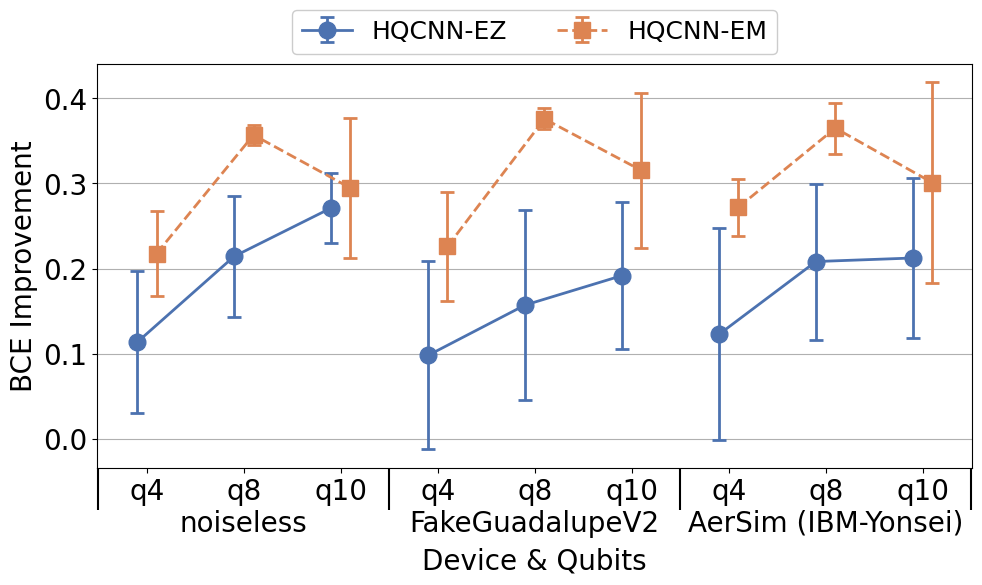

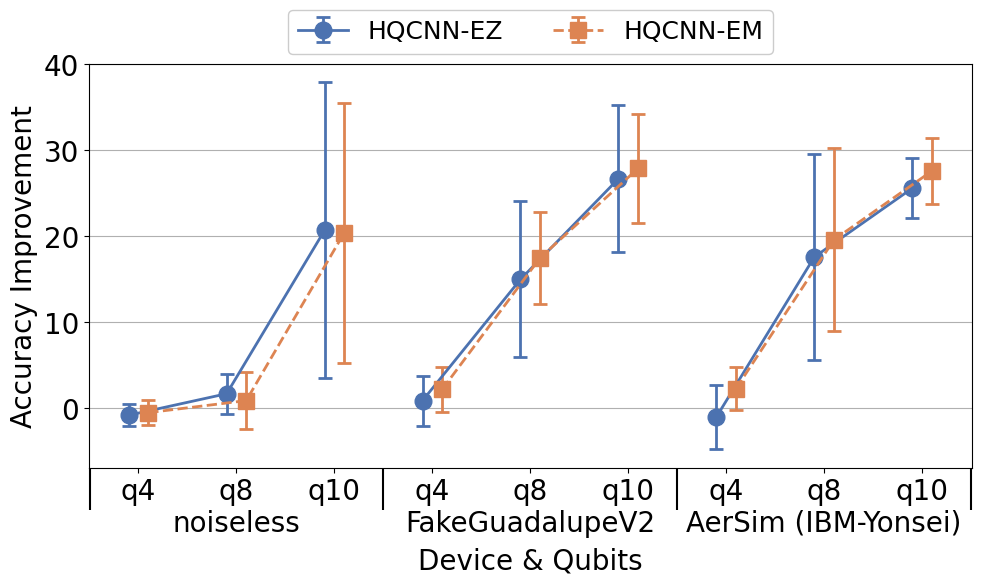

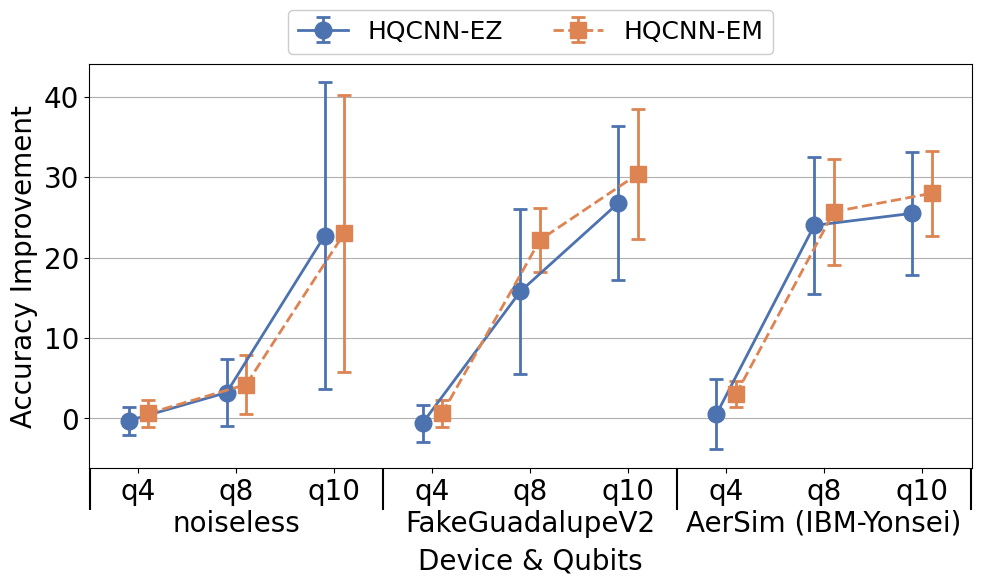

In [44]:
# BCE (loss) improvement
plot_metric_improvement_by_device2(
    df=df_plot,
    metric_diff_cols=['Diff_loss_HQCNN-EZ', 'Diff_loss_HQCNN-EM'],
    metric_label="BCE Improvement",
    plot_title=None,
    filename_suffix="bce_loss_improvement_by_device_and_qubits.png",
    plot_save=PLOT_SAVE,
    qubits=[4, 8, 10],
    figsize=(10, 6),
    title_size=20,
    axis_label_size=20,
    tick_size=20,
    legend_size=18,
    legend_loc='center',
    line_width=2.0,
    point_size=12,
    errorbar_width=2,
    cap_thickness=2,
    capsize=5,
    dodge=0.1
)

# Accuracy improvement
plot_metric_improvement_by_device2(
    df=df_plot,
    metric_diff_cols=['Diff_accu_HQCNN-EZ', 'Diff_accu_HQCNN-EM'],
    metric_label="Accuracy Improvement",
    plot_title=None,
    filename_suffix="accuracy_best_improvement_by_device_and_qubits.png",
    plot_save=PLOT_SAVE,
    qubits=[4, 8, 10],
    figsize=(10, 6),
    title_size=20,
    axis_label_size=20,
    tick_size=20,
    legend_size=18,
    legend_loc='center',
    line_width=2.0,
    point_size=12,
    errorbar_width=2,
    cap_thickness=2,
    capsize=5,
    dodge=0.1
)

Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Performance_Improvements_2x2_metric2.pdf


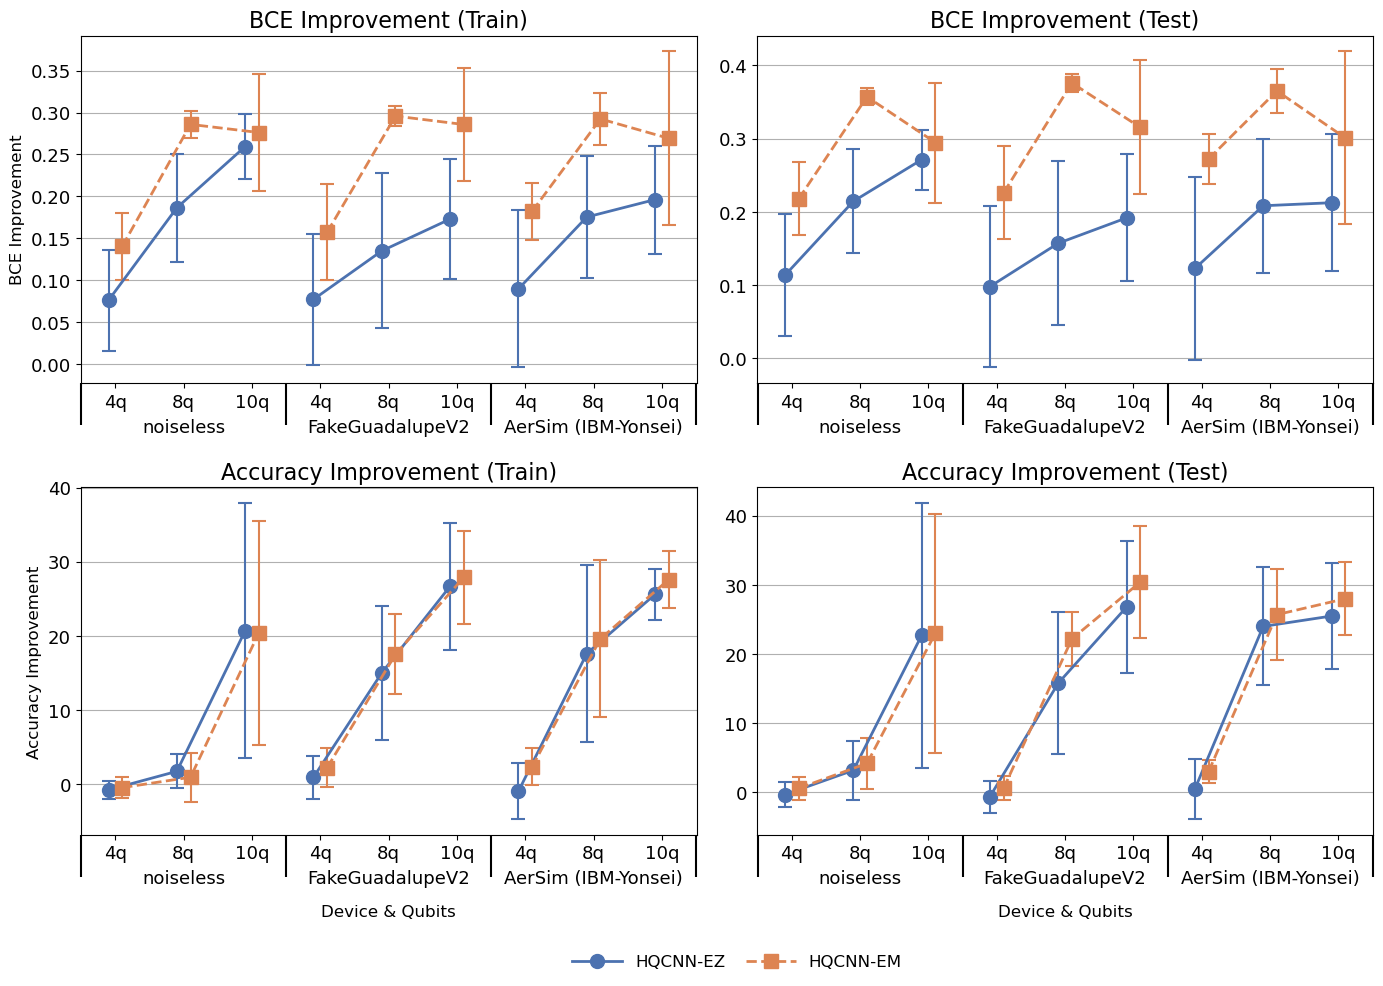

In [45]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D


def plot_metric_improvement_by_device2(
    df,
    metric_diff_cols,
    metric_label="Improvement",
    x_axis_label="Diff.",
    plot_title="Metric Improvement per Device",
    filename_suffix="metric_improvement_by_device.png",
    plot_save=False,
    qubits=None,
    figsize=(8, 6),
    title_size=16,
    axis_label_size=12,
    tick_size=14,
    legend_size=10,
    legend_loc='best',
    show_points=False,
    capsize=3,
    line_alpha=1.0,
    dodge=0.12,
    line_width=1.8,
    point_size=6,
    errorbar_width=1.2,
    cap_thickness=1.2,

    # NEW (for 2x2 usage)
    ax=None,                 # if provided, draw into this axis
    dataset_type=None,       # "Train" or "Test"; if None, does Train+Test like before
    add_legend=True,         # set False when using shared legend
    return_handles=False,    # return legend handles for shared legend
    show=True                # show figure when ax is None
):
    """
    If dataset_type is None:
        behaves like your current version (loops Train/Test and creates its own figures).
    If dataset_type is "Train" or "Test":
        draws ONLY that dataset into `ax` (or into a new figure if ax is None).
    """
    # Optional filter by qubits
    if qubits is not None:
        df = df[df['Qubits'].isin(qubits)].copy()
    else:
        df = df.copy()

    # Melt
    melted_df = df.melt(
        id_vars=['Device', 'Qubits', 'sim_iter_num', 'Dataset'],
        value_vars=metric_diff_cols,
        var_name='Model_Comparison',
        value_name=metric_label
    )

    # Rename + enforce order
    rename_dict = {metric_diff_cols[0]: 'HQCNN-EZ', metric_diff_cols[1]: 'HQCNN-EM'}
    melted_df['Model_Comparison'] = melted_df['Model_Comparison'].replace(rename_dict)
    hue_order = ['HQCNN-EZ', 'HQCNN-EM']

    # Device name normalization
    melted_df['Device'] = melted_df['Device'].replace({
        "AerSim with backend noise": "AerSim (IBM-Yonsei)"
    })

    # Composite category
    melted_df['Device_Qubits'] = melted_df['Device'] + "\n q" + melted_df['Qubits'].astype(str)

    # Colors + styles
    colors = sns.color_palette('deep', n_colors=2)
    color_map = {'HQCNN-EZ': colors[0], 'HQCNN-EM': colors[1]}

    style_map = {
        'HQCNN-EZ': {'marker': 'o', 'linestyle': '-'},
        'HQCNN-EM': {'marker': 's', 'linestyle': '--'}
    }

    dodge_map = {'HQCNN-EZ': -abs(dodge), 'HQCNN-EM': abs(dodge)}

    # Legend handles (for shared legend)
    legend_handles = [
        Line2D([0], [0],
               color=color_map[m],
               marker=style_map[m]['marker'],
               linestyle=style_map[m]['linestyle'],
               linewidth=line_width,
               markersize=point_size,
               label=m)
        for m in hue_order
    ]

    def _plot_one_dataset(ax_local, dataset_local):
        subset_df = melted_df[melted_df['Dataset'] == dataset_local].copy()
        if subset_df.empty:
            ax_local.set_visible(False)
            return

        # Stable x-order
        order_df = (
            subset_df[['Device', 'Qubits', 'Device_Qubits']]
            .drop_duplicates()
            .reset_index(drop=True)
        )
        x_order = order_df['Device_Qubits'].tolist()
        x_ticklabels = [str(q) + "q" for q in order_df['Qubits'].tolist()]

        # Summary stats (mean ± sd)
        summary = (
            subset_df
            .groupby(['Device', 'Device_Qubits', 'Model_Comparison'])[metric_label]
            .agg(mean='mean', sd='std')
            .reset_index()
        )

        x_pos_map = {cat: i for i, cat in enumerate(x_order)}
        x_positions = np.arange(len(x_order), dtype=float)

        # device blocks (to break lines across devices)
        device_seq = order_df['Device'].tolist()
        device_blocks = []
        start = 0
        for i in range(1, len(device_seq) + 1):
            if i == len(device_seq) or device_seq[i] != device_seq[start]:
                device_blocks.append(device_seq[start])
                start = i

        # Plot per model, broken by device block, dodged
        for model in hue_order:
            mk = style_map[model]['marker']
            ls = style_map[model]['linestyle']
            dx = dodge_map.get(model, 0.0)

            for dev in device_blocks:
                s = summary[(summary['Model_Comparison'] == model) & (summary['Device'] == dev)].copy()
                if s.empty:
                    continue

                s['x'] = s['Device_Qubits'].map(x_pos_map)
                s = s.dropna(subset=['x']).sort_values('x')

                x = s['x'].to_numpy(dtype=float) + dx
                y_mean = s['mean'].to_numpy()
                y_sd = s['sd'].to_numpy()

                ax_local.errorbar(
                    x, y_mean, yerr=y_sd,
                    fmt=mk,
                    linestyle=ls,
                    capsize=capsize,
                    linewidth=line_width,
                    markersize=point_size,
                    color=color_map[model],
                    alpha=line_alpha,
                    elinewidth=errorbar_width,
                    capthick=cap_thickness,
                    zorder=3
                )

        # Optional raw points (dodged)
        if show_points:
            for model in hue_order:
                d = subset_df[subset_df['Model_Comparison'] == model].copy()
                if d.empty:
                    continue
                d['x'] = d['Device_Qubits'].map(x_pos_map)
                d = d.dropna(subset=['x'])

                ax_local.scatter(
                    d['x'].to_numpy(dtype=float) + dodge_map.get(model, 0.0),
                    d[metric_label].to_numpy(),
                    s=(point_size**2),
                    alpha=0.20,
                    color=color_map[model],
                    marker=style_map[model]['marker'],
                    edgecolors='none',
                    zorder=2
                )

        # Primary x-axis: q# only
        ax_local.set_xticks(x_positions)
        ax_local.set_xticklabels(x_ticklabels, rotation=0, fontsize=tick_size)

        ax_local.set_ylabel(metric_label, fontsize=axis_label_size)
        ax_local.set_xlabel('Device & Qubits', fontsize=axis_label_size, labelpad=30)

        if plot_title:
            ax_local.set_title(f"{plot_title} in {dataset_local} Dataset", fontsize=title_size)

        ax_local.tick_params(axis='x', labelsize=tick_size)
        ax_local.tick_params(axis='y', labelsize=tick_size)
        ax_local.grid(axis='y', zorder=0)

        # legend (optional; typically off for 2x2 shared legend)
        if add_legend:
            ax_local.legend(
                handles=legend_handles,
                fontsize=legend_size,
                loc=legend_loc,
                bbox_to_anchor=(0.5, 1.08),
                ncol=2,
                framealpha=1
            )

        # ---- Secondary x-axis: device labels & separators ----
        xticklocs = np.asarray(ax_local.get_xticks(), dtype=float)
        if len(xticklocs) != len(device_seq):
            xticklocs = np.arange(len(device_seq), dtype=float)

        step = float(np.median(np.diff(xticklocs))) if len(xticklocs) > 1 else 1.0

        group_mids, group_labels, edges = [], [], [xticklocs[0] - 0.5 * step]
        start = 0
        for i in range(1, len(device_seq) + 1):
            if i == len(device_seq) or device_seq[i] != device_seq[start]:
                left = xticklocs[start]
                right = xticklocs[i - 1]
                group_mids.append((left + right) / 2.0)
                group_labels.append(device_seq[start])
                edges.append(right + 0.5 * step)
                start = i

        sec = ax_local.secondary_xaxis(location=0)
        sec.set_xticks(group_mids, labels=group_labels, rotation=0)
        sec.tick_params(axis='x', length=0, pad=25, labelsize=tick_size)

        sec2 = ax_local.secondary_xaxis(location=0)
        sec2.set_xticks(edges, labels=[])
        sec2.tick_params(axis='x', length=30, width=1.5)

        for spine in ['left', 'right', 'top', 'bottom']:
            sec.spines[spine].set_visible(False)
            sec2.spines[spine].set_visible(False)

    # ---- Mode A: draw into existing ax for a single dataset ----
    if dataset_type is not None:
        if ax is None:
            plt.figure(figsize=figsize)
            ax = plt.gca()
            _plot_one_dataset(ax, dataset_type)
            plt.tight_layout()
            if show:
                plt.show()
        else:
            _plot_one_dataset(ax, dataset_type)

        if return_handles:
            return legend_handles
        return

    # ---- Mode B: original behavior (Train + Test separate figures) ----
    for dataset_local in ['Train', 'Test']:
        plt.figure(figsize=figsize)
        ax_local = plt.gca()
        _plot_one_dataset(ax_local, dataset_local)
        plt.tight_layout()

        if plot_save:
            os.makedirs(save_summary_results_dirs, exist_ok=True)
            filename = os.path.join(
                save_summary_results_dirs,
                filename_suffix.replace(
                    ".png",
                    f"_q{'-'.join(map(str, qubits))}_{dataset_local}.png"
                ) if qubits else filename_suffix.replace(".png", f"_{dataset_local}.png")
            )
            plt.savefig(filename, dpi=300, bbox_inches='tight')
            print(f"Plot saved as {filename}")

        if show:
            plt.show()

    if return_handles:
        return legend_handles


def plot_improvements_2x2_using_metric2(
    df,
    qubits=None,
    figsize=(14, 10),
    title_font=22,
    subplot_title=18,
    axis_label_size=16,
    tick_font=13,
    legend_font=14,
    plot_save=False,
    save_path=None,

    # forward style knobs to plot_metric_improvement_by_device2
    line_width=2.0,
    point_size=10,
    errorbar_width=1.8,
    cap_thickness=1.8,
    capsize=5,
    dodge=0.10,
    show_points=False,
    line_alpha=1.0
):
    """
    2×2 layout using plot_metric_improvement_by_device2 drawing into axes:
      [0,0] BCE Improvement — Train
      [0,1] BCE Improvement — Test
      [1,0] Accuracy Improvement — Train
      [1,1] Accuracy Improvement — Test
    Shared legend at bottom-center.
    """
    METRICS = {
        "BCE Improvement":      ["Diff_loss_HQCNN-EZ",  "Diff_loss_HQCNN-EM"],
        "Accuracy Improvement": ["Diff_accu_HQCNN-EZ",  "Diff_accu_HQCNN-EM"],
    }

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.reshape(2, 2)

    panels = [
        (0, 0, "BCE Improvement",      "Train"),
        (0, 1, "BCE Improvement",      "Test"),
        (1, 0, "Accuracy Improvement", "Train"),
        (1, 1, "Accuracy Improvement", "Test"),
    ]

    shared_handles = None

    for r, c, metric_label, dataset in panels:
        ax = axes[r, c]

        handles = plot_metric_improvement_by_device2(
            df=df,
            metric_diff_cols=METRICS[metric_label],
            metric_label=metric_label,
            plot_title=None,            # we'll title per subplot ourselves
            plot_save=False,
            qubits=qubits,
            tick_size = tick_font,

            # style knobs
            line_width=line_width,
            point_size=point_size,
            errorbar_width=errorbar_width,
            cap_thickness=cap_thickness,
            capsize=capsize,
            dodge=dodge,
            show_points=show_points,
            line_alpha=line_alpha,

            # 2x2 mode
            ax=ax,
            dataset_type=dataset,
            add_legend=False,
            return_handles=True,
            show=False
        )

        ax.set_title(f"{metric_label} ({dataset})", fontsize=subplot_title)

        # reduce clutter: hide y-labels on right column, x-labels on top row
        if c == 1:
            ax.set_ylabel("")
        if r == 0:
            ax.set_xlabel("")

        ax.tick_params(axis='x', labelsize=tick_font)
        ax.tick_params(axis='y', labelsize=tick_font)

        if shared_handles is None and handles:
            shared_handles = handles

    # Shared legend at bottom-center
    if shared_handles:
        fig.legend(
            handles=shared_handles,
            loc='lower center',
            bbox_to_anchor=(0.53, -0.01),
            ncol=len(shared_handles),
            frameon=False,
            fontsize=legend_font,
            
            # NEW: make legend samples bigger so dashed lines are visible
            handlelength=3.0,   # longer line segment -> clearer dashes
            markerscale=1.0,    # bigger marker in legend
            handletextpad=0.8,  # spacing between handle and text
            columnspacing=1.2   # spacing between legend columns
        )

    plt.tight_layout(rect=[0, 0.04, 1, 0.98])
    fig.subplots_adjust(hspace=0.30)

    if plot_save:
        if save_path is None:
            # default consistent with your earlier style
            os.makedirs(save_summary_results_dirs, exist_ok=True)
            save_path = os.path.join(save_summary_results_dirs, "Performance_Improvements_2x2_metric2.pdf")
        fig.savefig(save_path, dpi=300, bbox_inches='tight', format='pdf')
        print(f"Plot saved as {save_path}")

    plt.show()

plot_improvements_2x2_using_metric2(
    df=performance_best_comparison_df,
    qubits=num_qubits,
    figsize=(14, 10),
    title_font=title_font,
    subplot_title=subplot_title,
    axis_label_size=axis_label_font,
    tick_font=13,
    legend_font=legend_font,
    plot_save=PLOT_SAVE,

    # line/errorbar styling (same knobs you’ve been using)
    line_width=2.0,
    point_size=10,
    errorbar_width=1.5,
    cap_thickness=1.5,
    capsize=5,
    dodge=0.10,
    show_points=False
)

Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Performance_Improvements_1x2_TestOnly.pdf


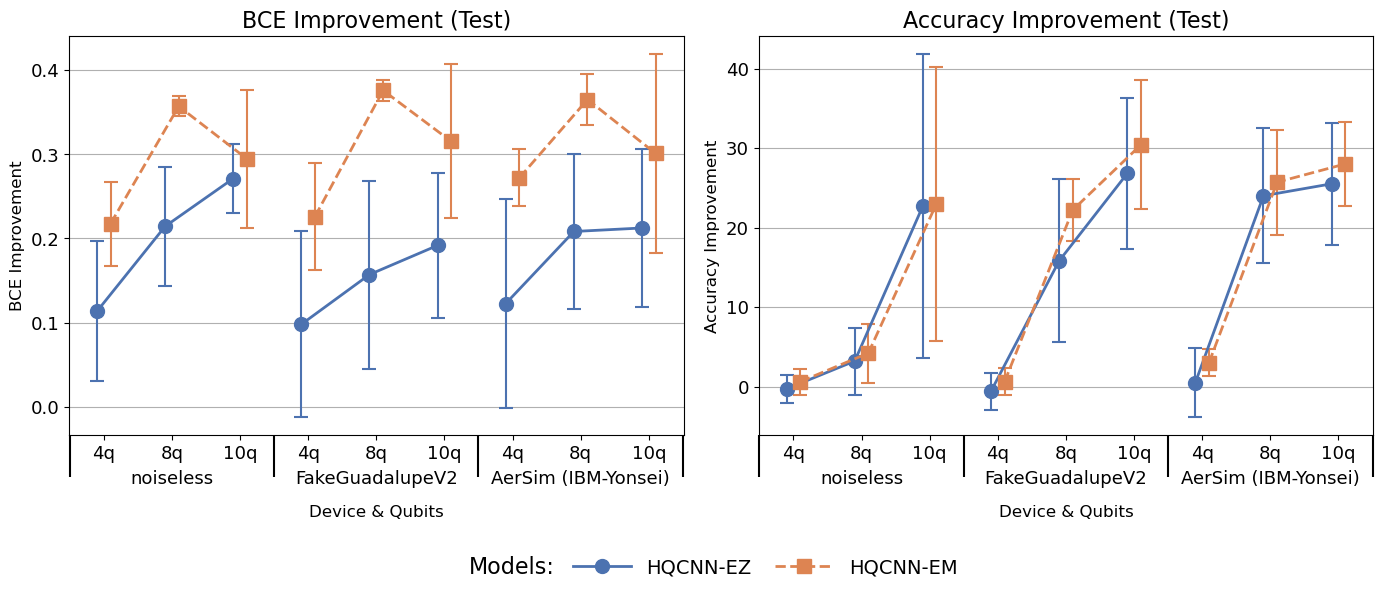

In [46]:
def plot_improvements_1x2_test_only(
    df,
    qubits=None,
    figsize=(14, 6),       # <-- Reduced height for a single row
    title_font=22,
    subplot_title=18,
    axis_label_size=16,
    tick_font=13,
    legend_font=14,
    plot_save=False,
    save_path=None,

    # forward style knobs to plot_metric_improvement_by_device2
    line_width=2.0,
    point_size=10,
    errorbar_width=1.8,
    cap_thickness=1.8,
    capsize=5,
    dodge=0.10,
    show_points=False,
    line_alpha=1.0
):
    """
    1×2 layout plotting ONLY the Test dataset:
      [0] BCE Improvement — Test
      [1] Accuracy Improvement — Test
    Shared legend at bottom-center.
    """
    METRICS = {
        "BCE Improvement":      ["Diff_loss_HQCNN-EZ",  "Diff_loss_HQCNN-EM"],
        "Accuracy Improvement": ["Diff_accu_HQCNN-EZ",  "Diff_accu_HQCNN-EM"],
    }

    # 1. Create a 1x2 subplot grid
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # 2. Define only the Test panels
    panels = [
        (0, "BCE Improvement",      "Test"),
        (1, "Accuracy Improvement", "Test"),
    ]

    shared_handles = None

    for c, metric_label, dataset in panels:
        ax = axes[c]

        handles = plot_metric_improvement_by_device2(
            df=df,
            metric_diff_cols=METRICS[metric_label],
            metric_label=metric_label,
            plot_title=None,            
            plot_save=False,
            qubits=qubits,
            tick_size=tick_font,

            # style knobs
            line_width=line_width,
            point_size=point_size,
            errorbar_width=errorbar_width,
            cap_thickness=cap_thickness,
            capsize=capsize,
            dodge=dodge,
            show_points=show_points,
            line_alpha=line_alpha,

            # 1x2 mode specifics
            ax=ax,
            dataset_type=dataset,
            add_legend=False,
            return_handles=True,
            show=False
        )

        ax.set_title(f"{metric_label} ({dataset})", fontsize=subplot_title)

        ax.tick_params(axis='x', labelsize=tick_font)
        ax.tick_params(axis='y', labelsize=tick_font)

        if shared_handles is None and handles:
            shared_handles = handles

    # Shared legend at bottom-center
    if shared_handles:
        fig.legend(
            handles=shared_handles,
            loc='lower center',
            bbox_to_anchor=(0.55, 0.0),  # <-- Adjusted slightly for 1x2 layout
            ncol=len(shared_handles),
            frameon=False,
            fontsize=legend_font+2,
            
            handlelength=3.0,   
            markerscale=1.0,    
            handletextpad=0.8,  
            columnspacing=1.2   
        )
        
        # --- NEW: Add "Models:" text to the left of the legend ---
        # You may need to tweak the x (0.38) and y (-0.05) values slightly 
        # depending on exactly how wide your figure renders!
        fig.text(0.40, 0.045, "Models:", ha='right', va='center', fontsize=legend_font+4)

    # Leave room at the bottom for the legend
    plt.tight_layout(rect=[0, 0.1, 1, 1])

    if plot_save:
        if save_path is None:
            os.makedirs(save_summary_results_dirs, exist_ok=True)
            save_path = os.path.join(save_summary_results_dirs, "Performance_Improvements_1x2_TestOnly.pdf")
        fig.savefig(save_path, dpi=300, bbox_inches='tight', format='pdf')
        print(f"Plot saved as {save_path}")

    plt.show()

# --- Execution ---
plot_improvements_1x2_test_only(
    df=performance_best_comparison_df,
    qubits=num_qubits,
    # figsize defaults to (14, 6) now!
    title_font=title_font,
    subplot_title=subplot_title,
    axis_label_size=axis_label_font,
    tick_font=13,
    legend_font=legend_font,
    plot_save=PLOT_SAVE,

    line_width=2.0,
    point_size=10,
    errorbar_width=1.5,
    cap_thickness=1.5,
    capsize=5,
    dodge=0.10,
    show_points=False
)

🔹 Absolute difference (e.g., ΔLoss, ΔAccuracy)

- Pros:
    - Directly tied to the metric scale, so it’s easy to interpret in the same units as the training objective (loss points, accuracy points).
    
    - Shows whether the improvement is “substantively large” on the raw scale.

    - Avoids distortions if the baseline values are very small.

- Cons:

    - Can look underwhelming if the baseline value is large (e.g., 1–2% accuracy gain may seem small without context).

    - Harder to compare across different datasets or devices if baseline levels differ a lot.

🔹 Percent difference (relative improvement)

- Pros:

    - Normalizes the change relative to baseline — good for cross-device or cross-dataset comparisons.

    - Makes small absolute gains more visible if they are proportionally large (e.g., reducing loss from 0.2 to 0.1 = 50% improvement).

    - Easier to communicate to non-technical audiences (“model B improves accuracy by 15%”).

- Cons:

    - Can exaggerate improvements when baselines are small (e.g., improving accuracy from 2% to 3% looks like +50%, but still unusable).

    - Harder to compare across metrics with different scales (loss vs accuracy).

## Model Improvements/Degradation across noise
- a within-model difference across noise: 
$$\Delta_{noise}^{(k)} = \text{Accuracy}_{noiseless}^{(k)} - \text{Accuracy}_{noisy}^{(k)}$$

In [47]:
performance_best_df

,Device,Qubits,Model,Model_spec,sim_iter_num,Dataset,binary_cross_entropy_loss,accuracy,best_epoch
0,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,Train,0.519547,85.5,18
1,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,Test,0.472581,92.0,18
2,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,Train,0.573228,84.0,16
3,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,Test,0.544554,93.0,16
4,noiseless,4,QCNN,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,Train,0.500705,87.0,18
...,...,...,...,...,...,...,...,...,...
265,AerSim (IBM-Yonsei),10,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,Test,0.266647,91.5,10
266,AerSim (IBM-Yonsei),10,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,3,Train,0.483175,83.0,15
267,AerSim (IBM-Yonsei),10,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,3,Test,0.473002,87.0,15
268,AerSim (IBM-Yonsei),10,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,Train,0.285916,90.5,17


In [48]:
# performance_best_df[performance_best_df['Device']=='noiseless']

In [49]:
import pandas as pd

def diff_model_perfomance(problem_type, performance_df):
    if problem_type == 'clf':
            # Filter to the three devices
            filtered_df = performance_df[
                performance_df['Device'].isin(['noiseless', 'FakeGuadalupeV2', 'AerSim (IBM-Yonsei)'])
                ]
            
            # Pivot for loss, accuracy
            bce_loss_pivot = filtered_df.pivot_table(
                index=['Model', 'Qubits', 'sim_iter_num', 'Dataset'],
                columns='Device',
                values='binary_cross_entropy_loss',
                sort=False
                ).reset_index()

            accuracy_pivot = filtered_df.pivot_table(
                index=['Model', 'Qubits', 'sim_iter_num', 'Dataset'],
                columns='Device',
                values='accuracy',
                sort=False
                ).reset_index()

            # Performance difference
            bce_loss_pivot['Diff_loss_FakeGuadalupeV2'] = bce_loss_pivot['noiseless'] - bce_loss_pivot['FakeGuadalupeV2']
            bce_loss_pivot['Diff_loss_AerSim'] = bce_loss_pivot['noiseless'] - bce_loss_pivot['AerSim (IBM-Yonsei)']
            
            accuracy_pivot['Diff_accu_FakeGuadalupeV2'] = accuracy_pivot['FakeGuadalupeV2'] - accuracy_pivot['noiseless']
            accuracy_pivot['Diff_accu_AerSim'] = accuracy_pivot['AerSim (IBM-Yonsei)'] - accuracy_pivot['noiseless']
            
            # Merge results
            performance_diff_df = pd.merge(
                bce_loss_pivot[['Model', 'Qubits', 'sim_iter_num', 'Dataset',
                            'Diff_loss_FakeGuadalupeV2', 'Diff_loss_AerSim']],
                accuracy_pivot[['Model', 'Qubits', 'sim_iter_num', 'Dataset',
                                'Diff_accu_FakeGuadalupeV2', 'Diff_accu_AerSim']],
                on=['Model', 'Qubits', 'sim_iter_num', 'Dataset']
                )

    elif problem_type == 'reg':
        # Filter to the three models
        filtered_df = performance_df[
            performance_df['Device'].isin(['noiseless', 'FakeGuadalupeV2', 'AerSim (IBM-Yonsei)'])
            ]

        # Pivot for MAE, MSE, RMSE, R-Squared, Adj R-Squared
        mae_pivot = filtered_df.pivot_table(
            index=['Model', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Device',
            values='MAE',
            sort=False
        ).reset_index()
        
        mse_pivot = filtered_df.pivot_table(
            index=['Model', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Device',
            values='MSE',
            sort=False
        ).reset_index()
        
        rmse_pivot = filtered_df.pivot_table(
            index=['Model', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Device',
            values='RMSE',
            sort=False
        ).reset_index()
                
        r_squared_pivot = filtered_df.pivot_table(
            index=['Model', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Device',
            values='R-squared',
            sort=False
        ).reset_index()
                        
        adj_r_squared_pivot = filtered_df.pivot_table(
            index=['Model', 'Qubits', 'sim_iter_num', 'Dataset'],
            columns='Device',
            values='Adj R-squared',
            sort=False
        ).reset_index()

        # Performance improvements
        mae_pivot['Diff_mae_FakeGuadalupeV2'] = mae_pivot['noiseless'] - mae_pivot['FakeGuadalupeV2']
        mae_pivot['Diff_mae_AerSim'] = mae_pivot['noiseless'] - mae_pivot['AerSim (IBM-Yonsei)']
                    
        mse_pivot['Diff_mse_FakeGuadalupeV2'] = mse_pivot['noiseless'] - mse_pivot['FakeGuadalupeV2']
        mse_pivot['Diff_mse_AerSim'] = mse_pivot['noiseless'] - mse_pivot['AerSim (IBM-Yonsei)']
                    
        rmse_pivot['Diff_rmse_FakeGuadalupeV2'] = rmse_pivot['noiseless'] - rmse_pivot['FakeGuadalupeV2']
        rmse_pivot['Diff_rmse_AerSim'] = rmse_pivot['noiseless'] - rmse_pivot['AerSim (IBM-Yonsei)']
                    
        r_squared_pivot['Diff_r-squared_FakeGuadalupeV2'] = r_squared_pivot['FakeGuadalupeV2'] - r_squared_pivot['noiseless']
        r_squared_pivot['Diff_r-squared_AerSim'] = r_squared_pivot['AerSim (IBM-Yonsei)'] - r_squared_pivot['noiseless']
        
        adj_r_squared_pivot['Diff_adj r-squared_FakeGuadalupeV2'] = adj_r_squared_pivot['FakeGuadalupeV2'] - adj_r_squared_pivot['noiseless']
        adj_r_squared_pivot['Diff_adj r-squared_AerSim'] = adj_r_squared_pivot['AerSim (IBM-Yonsei)'] - adj_r_squared_pivot['noiseless']
        
        # Merge results
        key_cols = ['Model', 'Qubits', 'sim_iter_num', 'Dataset']
        performance_diff_df = (
            mae_pivot[key_cols + [
                'Diff_mae_FakeGuadalupeV2', 'Diff_mae_AerSim']]
            .merge(
                mse_pivot[key_cols + [
                    'Diff_mse_FakeGuadalupeV2', 'Diff_mse_AerSim']],
                on=key_cols, how='inner'
            )
            .merge(
                rmse_pivot[key_cols + [
                    'Diff_rmse_FakeGuadalupeV2', 'Diff_rmse_AerSim']],
                on=key_cols, how='inner'
            )
            .merge(
                r_squared_pivot[key_cols + [
                    'Diff_r-squared_FakeGuadalupeV2', 'Diff_r-squared_AerSim']],
                on=key_cols, how='inner'
            )
            .merge(
                adj_r_squared_pivot[key_cols + [
                    'Diff_adj r-squared_FakeGuadalupeV2', 'Diff_adj r-squared_AerSim']],
                on=key_cols, how='inner'
            )
        )

    return performance_diff_df

In [50]:
performance_best_diff_df = diff_model_perfomance(problem_type, performance_best_df)
print(len(performance_best_diff_df))
# performance_best_diff_df.iloc[0:40]

90


In [51]:
if SUMMRAY_TABLE_SAVE == True:
    # performance_diff_df.to_csv(save_summary_results_dirs+'performance_diff_df.csv', encoding="utf-8-sig")
    performance_best_diff_df.to_csv(save_summary_results_dirs+'performance_best_diff_df.csv', encoding="utf-8-sig")

In [52]:
import pandas as pd

# The two diff columns are really "which noisy device", so they become the
# innermost column level.
if problem_type=='clf':
    DIFF_DEVICE_RENAME = {
        'Diff_accu_FakeGuadalupeV2': 'Diff. Accuracy (FakeGuadalupeV2)',
        'Diff_accu_AerSim':          'Diff. Accuracy (AerSim (IBM-Yonsei))',
        'Diff_loss_FakeGuadalupeV2': 'Diff. Loss (FakeGuadalupeV2)',
        'Diff_loss_AerSim':          'Diff. Loss (AerSim (IBM-Yonsei))',
        }
elif problem_type=='reg':
    DIFF_DEVICE_RENAME = {
        'Diff_mae_FakeGuadalupeV2':             'Diff. MAE (FakeGuadalupeV2)',
        'Diff_mae_AerSim':                      'Diff. MAE (AerSim (IBM-Yonsei))',
        'Diff_mse_FakeGuadalupeV2':             'Diff. MSE (FakeGuadalupeV2)',
        'Diff_mse_AerSim':                      'Diff. MSE (AerSim (IBM-Yonsei))',
        'Diff_rmse_FakeGuadalupeV2':            'Diff. RMSE(FakeGuadalupeV2)',
        'Diff_rmse_AerSim':                     'Diff. RMSE (AerSim (IBM-Yonsei))',
        'Diff_r-squared_FakeGuadalupeV2':       'Diff. R-squared (FakeGuadalupeV2)',
        'Diff_r-squared_AerSim':                'Diff. R-squared (AerSim (IBM-Yonsei))',
        'Diff_adj r-squared_FakeGuadalupeV2':   'Diff. Adj. R-squared (FakeGuadalupeV2)',
        'Diff_adj r-squared_AerSim':            'Diff. Adj. R-squared (AerSim (IBM-Yonsei))',
        }

def format_performance_diff_summary(
    performance_diff_df: pd.DataFrame,
    problem_type: str = "clf",
    qubit_order: list[int] = [4, 8, 10],
    value_cols: list[str] = None,
    round_digits: int = 4,
    compact: bool = True,
) -> pd.DataFrame:
    """
    Reshape a per-seed performance-diff table into:
        rows    = Dataset -> Model
        columns = Task -> Qubits -> Device (difference vs. the noiseless baseline)

    Parameters
    ----------
    performance_diff_df : pd.DataFrame
        Output of diff_model_perfomance -- one row per
        (Model, Qubits, sim_iter_num, Dataset).
    problem_type : str, default "clf"
        Label placed on the top column level ("Task").
    qubit_order : list[int], default [4, 8, 10]
        Order of qubits to appear in columns
    value_cols : list[str] | None
        Diff columns to tabulate. Defaults to the two accuracy diffs.
    round_digits : int
        Rounding for mean/std values
    compact : bool
        True  -> cells are 'mean ± std' strings across sim_iter_num
        False -> cells are the numeric mean (sortable / stylable)

    Returns
    -------
    pd.DataFrame
        Formatted DataFrame with hierarchical MultiIndex rows and columns
    """      
    df = performance_diff_df.copy()
    if {'Dataset', 'Model', 'Qubits'} - set(df.columns):
        df = df.reset_index()

    df = df[df['Qubits'].isin(qubit_order)]
    
    # Pivot to wide format with reordered index: Dataset → Device → Model
    if problem_type == 'clf':
        task_name = "Classification Task"
        
        if value_cols is None:
            value_cols = [
                'Diff_loss_FakeGuadalupeV2', 'Diff_loss_AerSim',
                'Diff_accu_FakeGuadalupeV2', 'Diff_accu_AerSim',
                ]
        
        # Collapse the seeds: this is the step the other formatters get for free
        # from summarize_performance_compact.
        stats = df.groupby(['Dataset', 'Model', 'Qubits'])[value_cols].agg(['mean', 'std'])

        out = pd.DataFrame(index=stats.index)
        for c in value_cols:
            mu = stats[(c, 'mean')].round(round_digits)
            if compact:
                sd = stats[(c, 'std')].round(round_digits)
                out[c] = mu.astype(str) + " ± " + sd.astype(str)
            else:
                out[c] = mu

        # Qubits from rows to columns, then Qubits above Device
        wide = out.unstack('Qubits').swaplevel(0, 1, axis=1)

        # Label-based reindex enforces the order AND keeps labels attached to their
        # own data (unlike assigning MultiIndex.from_product to .columns).
        wide = wide.reindex(
            pd.MultiIndex.from_product([qubit_order, value_cols],
                                    names=["Qubits", "Device"]),
            axis=1
        )
        wide = wide.rename(columns=DIFF_DEVICE_RENAME, level="Device")

        # Add the Task level on top, carrying the (Qubits, Device) labels already
        # attached to their data -- no positional relabelling.
        wide = pd.concat({'task_name': wide}, axis=1)
        wide.columns.names = ["Task", "Qubits", "Device"]

        # Dataset descending -> Train above Test; Model descending happens to give
        # QCNN, HQCNN-EZ, HQCNN-EM (same order as model_names_str_new).
        wide = wide.sort_index(level=["Dataset", "Model"], ascending=[False, False])
        
    elif problem_type == 'reg':
        task_name = "Regression Task"
        
        if value_cols is None:
            value_cols = [
                'Diff_mae_FakeGuadalupeV2', 'Diff_mae_AerSim',
                'Diff_mse_FakeGuadalupeV2', 'Diff_mse_AerSim',
                'Diff_rmse_FakeGuadalupeV2', 'Diff_rmse_AerSim',
                'Diff_r-squared_FakeGuadalupeV2', 'Diff_r-squared_AerSim',
                'Diff_adj r-squared_FakeGuadalupeV2', 'Diff_adj r-squared_AerSim',
                ]
            
        # Collapse the seeds: this is the step the other formatters get for free
        # from summarize_performance_compact.
        stats = df.groupby(['Dataset', 'Model', 'Qubits'])[value_cols].agg(['mean', 'std'])

        out = pd.DataFrame(index=stats.index)
        for c in value_cols:
            mu = stats[(c, 'mean')].round(round_digits)
            if compact:
                sd = stats[(c, 'std')].round(round_digits)
                out[c] = mu.astype(str) + " ± " + sd.astype(str)
            else:
                out[c] = mu

        # Qubits from rows to columns, then Qubits above Device
        wide = out.unstack('Qubits').swaplevel(0, 1, axis=1)

        # Label-based reindex enforces the order AND keeps labels attached to their
        # own data (unlike assigning MultiIndex.from_product to .columns).
        wide = wide.reindex(
            pd.MultiIndex.from_product([qubit_order, value_cols],
                                    names=["Qubits", "Device"]),
            axis=1
        )
        wide = wide.rename(columns=DIFF_DEVICE_RENAME, level="Device")

        # Add the Task level on top, carrying the (Qubits, Device) labels already
        # attached to their data -- no positional relabelling.
        wide = pd.concat({task_name: wide}, axis=1)
        wide.columns.names = ["Task", "Qubits", "Device"]

        # Dataset descending -> Train above Test; Model descending happens to give
        # QCNN, HQCNN-EZ, HQCNN-EM (same order as model_names_str_new).
        wide = wide.sort_index(level=["Dataset", "Model"], ascending=[False, False])

    return wide


performance_best_diff_summary_formated = format_performance_diff_summary(
    performance_best_diff_df,
    problem_type=problem_type,
    qubit_order=num_qubits,
)


In [53]:
performance_best_diff_summary_formated

Task                                task_name  \
Qubits                                     4    
Device           Diff. Loss (FakeGuadalupeV2)   
Dataset Model                                   
Train   QCNN                 -0.0435 ± 0.0062   
        HQCNN-EZ             -0.0424 ± 0.0213   
        HQCNN-EM             -0.0266 ± 0.0286   
Test    QCNN                 -0.0502 ± 0.0129   
        HQCNN-EZ             -0.0656 ± 0.0267   
        HQCNN-EM             -0.0418 ± 0.0413   

Task                                               \
Qubits                                              
Device           Diff. Loss (AerSim (IBM-Yonsei))   
Dataset Model                                       
Train   QCNN                     -0.0664 ± 0.0107   
        HQCNN-EZ                 -0.0528 ± 0.0297   
        HQCNN-EM                  -0.0246 ± 0.015   
Test    QCNN                     -0.0897 ± 0.0165   
        HQCNN-EZ                 -0.0804 ± 0.0443   
        HQCNN-EM                  -0.0353 ± 0.027   

Task                                               \
Qubits                                              
Device           Diff. Accuracy (FakeGuadalupeV2)   
Dataset Model                                       
Train   QCNN                        -1.9 ± 2.6315   
        HQCNN-EZ                    -0.2 ± 0.7583   
        HQCNN-EM                     0.8 ± 1.3038   
Test    QCNN                        -0.4 ± 0.8944   
        HQCNN-EZ                    -0.7 ± 2.0494   
        HQCNN-EM                    -0.4 ± 1.3874   

Task                                                   \
Qubits                                                  
Device           Diff. Accuracy (AerSim (IBM-Yonsei))   
Dataset Model                                           
Train   QCNN                            -2.4 ± 2.2192   
        HQCNN-EZ                        -2.6 ± 4.7487   
        HQCNN-EM                         0.4 ± 1.4748   
Test    QCNN                            -3.2 ± 0.9747   
        HQCNN-EZ                         -2.4 ± 4.547   
        HQCNN-EM                        -0.8 ± 1.0368   

Task                                           \
Qubits                                     8    
Device           Diff. Loss (FakeGuadalupeV2)   
Dataset Model                                   
Train   QCNN                 -0.0472 ± 0.0141   
        HQCNN-EZ             -0.0986 ± 0.0415   
        HQCNN-EM             -0.0373 ± 0.0185   
Test    QCNN                 -0.0507 ± 0.0128   
        HQCNN-EZ             -0.1079 ± 0.0475   
        HQCNN-EM             -0.0318 ± 0.0214   

Task                                               \
Qubits                                              
Device           Diff. Loss (AerSim (IBM-Yonsei))   
Dataset Model                                       
Train   QCNN                     -0.0542 ± 0.0231   
        HQCNN-EZ                 -0.0653 ± 0.0285   
        HQCNN-EM                 -0.0477 ± 0.0439   
Test    QCNN                      -0.059 ± 0.0264   
        HQCNN-EZ                 -0.0651 ± 0.0389   
        HQCNN-EM                  -0.051 ± 0.0486   

Task                                               \
Qubits                                              
Device           Diff. Accuracy (FakeGuadalupeV2)   
Dataset Model                                       
Train   QCNN                       -16.8 ± 6.0477   
        HQCNN-EZ                    -3.5 ± 5.5678   
        HQCNN-EM                    -0.2 ± 1.0954   
Test    QCNN                       -18.4 ± 5.4589   
        HQCNN-EZ                   -5.8 ± 10.3356   
        HQCNN-EM                    -0.4 ± 0.8944   

Task                                                   \
Qubits                                                  
Device           Diff. Accuracy (AerSim (IBM-Yonsei))   
Dataset Model                                           
Train   QCNN                          -18.2 ± 11.1052   
        HQCNN-EZ                      

In [54]:
if SUMMRAY_TABLE_SAVE == True:
    # performance_diff_summary_formated.to_csv(save_summary_results_dirs+'performance_diff_summary.csv', encoding="utf-8-sig")
    performance_best_diff_summary_formated.to_csv(save_summary_results_dirs+'performance_best_diff_summary.csv', encoding="utf-8-sig")

## SHAP Results

In [55]:
import os
import pickle

all_shap_values_dict = dict()

for num_qubit in num_qubits:
    for model_name in model_names_str[1:3]:
        for model_spec in model_specs:
            for ns, device_name in zip(noise_settings, device_names):
                for iter_num in sim_iter_num:
                    save_param_plots_dir = (
                        f"save_results_{problem_type}/{dataset_name}_{num_qubit}/{model_name}/{model_spec}"
                        + f"/ns{ns}_iter{iter_num}_{num_shots}/"
                    )
                    shap_path = os.path.join(save_param_plots_dir, 'deep_explainer_shap.pkl')

                    # ✅ Initialize nested dict with num_qubit as first key
                    all_shap_values_dict \
                        .setdefault(num_qubit, {}) \
                        .setdefault(model_name, {}) \
                        .setdefault(model_spec, {}) \
                        .setdefault(ns, {})[iter_num] = None

                    if os.path.exists(shap_path):
                        try:
                            with open(shap_path, "rb") as f:
                                shap_values = pickle.load(f)
                                all_shap_values_dict[num_qubit][model_name][model_spec][ns][iter_num] = shap_values
                        except Exception as e:
                            print(f"⚠️ Error loading SHAP file at {shap_path}: {e}")
                    else:
                        print(f"⚠️ Warning: {shap_path} does not exist!")

⚠️ Warning: save_results_clf/mnist_4/model_mmTmbF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns3_iter0_256/deep_explainer_shap.pkl does not exist!
⚠️ Warning: save_results_clf/mnist_4/model_mmTmbF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns3_iter1_256/deep_explainer_shap.pkl does not exist!
⚠️ Warning: save_results_clf/mnist_4/model_mmTmbF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns3_iter2_256/deep_explainer_shap.pkl does not exist!
⚠️ Warning: save_results_clf/mnist_4/model_mmTmbF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns3_iter3_256/deep_explainer_shap.pkl does not exist!
⚠️ Warning: save_results_clf/mnist_4/model_mmTmbF/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns3_iter4_256/deep_explainer_shap.pkl does not exist!
⚠️ Warning: save_results_clf/mnist_4/model_mmTmbT/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01/ns3_iter0_256/deep_explainer_shap.pkl does not exist!
⚠️ Warning: save_results_clf/mnist

In [56]:
# all_shap_values_dict[4]['model_mmTmbF']['AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01']['2'][4].values

In [57]:
# for model_name, model_spec_dict in all_shap_values_dict.items():
#     print(model_name)
#     print(model_spec_dict)

In [58]:
import pandas as pd
import numpy as np

def shap_values_to_dataframe(
    all_shap_values_dict,
    num_qubit, 
    input_label_dict,          # e.g., {'model_mmTmbF': ['⟨Z⟩_0', ...], ...}
    noise_to_device,           # e.g., {'0': 'noiseless', ...}
    selected_model_names=None,
    selected_noise_settings=None
):
    df_rows = []

    for model_name, model_spec_dict in all_shap_values_dict.items():
        if selected_model_names is not None and model_name not in selected_model_names:
            continue

        for model_spec, noise_setting_dict in model_spec_dict.items():
            for noise_setting_key, sim_dict in noise_setting_dict.items():
                if selected_noise_settings is not None and noise_setting_key not in selected_noise_settings:
                    continue

                device_name = noise_to_device.get(str(noise_setting_key), "Unknown")

                for sim_iter_num, shap_values in sim_dict.items():
                    if shap_values is None:
                        continue

                    # Calculate mean absolute SHAP values
                    abs_mean = shap_values.abs.mean(0).values  # shape (n_features,)
                    input_labels = input_label_dict.get(model_name, [f"x{i}" for i in range(len(abs_mean))])
                    
                    for i, val in enumerate(abs_mean):
                        record = {
                            'Device': device_name,
                            'Qubits': num_qubit,
                            'Model': model_name,
                            'Model_spec': model_spec,
                            'sim_iter_num': sim_iter_num,
                            'Input_Feature': input_labels[i],
                            'Abs_SHAP': val
                        }
                        df_rows.append(record)

    df = pd.DataFrame(df_rows)
    return df

In [59]:
# # [num_qubit][model_name][model_spec][ns][iter_num]
# all_shap_values_dict[4]['model_mmTmbF']['AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01']['0'].values()

In [60]:
# ### Concatenate SHAP values across iterations and Plot beeswarm plots

# import os
# import pickle
# import numpy as np
# import shap

# all_shap_values_combined_dict = dict()

# for num_qubit in num_qubits:
#     for model_name in model_names_str[1:3]:
#         for model_spec in model_specs:
#             for ns, device_name in zip(noise_settings, device_names):
                
#                 # 1. Collect all loaded objects for this setting into a list
#                 expl_list = []
                
#                 for iter_num in sim_iter_num:
#                     save_param_plots_dir = (
#                         f"save_results_{problem_type}/{dataset_name}_{num_qubit}/{model_name}/{model_spec}"
#                         + f"/ns{ns}_iter{iter_num}_{num_shots}/"
#                     )
#                     shap_path = os.path.join(save_param_plots_dir, 'deep_explainer_shap.pkl')

#                     if os.path.exists(shap_path):
#                         try:
#                             with open(shap_path, "rb") as f:
#                                 # Append the loaded object to our temporary list
#                                 expl_list.append(pickle.load(f))
#                         except Exception as e:
#                             print(f"⚠️ Error loading SHAP file at {shap_path}: {e}")
#                     else:
#                         print(f"⚠️ Warning: {shap_path} does not exist!")

#                 # 2. Combine them using your robust logic
#                 if expl_list:
#                     vals_all = []
#                     data_all = []
#                     base_all = []
                    
#                     # Grab feature names from the first object (if they exist)
#                     feat_names = getattr(expl_list[0], "feature_names", None)

#                     for e in expl_list:
#                         vals = np.asarray(e.values)
#                         dat  = np.asarray(e.data)
#                         bas  = np.asarray(e.base_values)

#                         # Handle base_values dimension mismatch (scalar vs array)
#                         if bas.ndim == 0:
#                             bas = np.full((vals.shape[0],), float(bas))
#                         else:
#                             bas = bas.reshape(-1)

#                         vals_all.append(vals)
#                         data_all.append(dat)
#                         base_all.append(bas)

#                     # Create the new combined Explanation object
#                     combined_expl = shap.Explanation(
#                         values=np.concatenate(vals_all, axis=0),
#                         base_values=np.concatenate(base_all, axis=0),
#                         data=np.concatenate(data_all, axis=0),
#                         feature_names=feat_names
#                     )

#                     # 3. Store the single combined object in the dict
#                     all_shap_values_combined_dict \
#                         .setdefault(num_qubit, {}) \
#                         .setdefault(model_name, {}) \
#                         .setdefault(model_spec, {})[ns] = combined_expl

In [61]:
# # [num_qubit][model_name][model_spec][ns]
# all_shap_values_combined_dict[4]['model_mmTmbF']['AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01']['0'].data

In [62]:
# import shap
# import matplotlib.pyplot as plt

# for num_qubit in num_qubits:
#     # Map model name to its input labels (already defined earlier)
#     input_labels_list = []
#     input_labels_list_new_order = []
#     input_size_list = [1, int(np.log2(num_qubit)), 3*int(np.log2(num_qubit))]
        
#     for model_name, input_size in zip(model_names_str, input_size_list):
#         if model_name == 'model_mmF':
#             input_labels_list.append(None)
#             input_labels_list_new_order.append(None)
#         if model_name == 'model_mmTmbF':
#             input_labels_list.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
#             input_labels_list_new_order.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
#         elif model_name == 'model_mmTmbT':
#             input_labels_list.append([f"{m}{i}" for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_'] for i in range(int(np.ceil(np.log2(num_qubit))))])
#             input_labels_list_new_order.append([f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']])
#         input_label_dict = dict(zip(model_names_str, input_labels_list))
#         input_label_new_order_dict = dict(zip(model_names_str, input_labels_list_new_order))
        
#     for model_name in model_names_str[1:]:
#         for model_spec in model_specs:
#             for ns, device_name in zip(noise_settings, device_names):
#                 shap_values = all_shap_values_combined_dict[num_qubit][model_name][model_spec][ns]
#                 col2num = {col: i for i, col in enumerate(input_label_dict[model_name])}
#                 new_order = list(map(col2num.get, input_label_new_order_dict[model_name]))
                
#                 fig, ax = plt.subplots(figsize=(8, 4))
#                 shap.plots.beeswarm(shap_values, 
#                                     # order=range(len(input_label_dict[model_name])),
#                                     order=new_order, 
#                                     show=False)
#                 plt.title(f"SHAP Beeswarm Plot: \n num_qubit={num_qubit}, model_name={model_name}, ns={ns}", fontsize=14)
#                 plt.tight_layout()
#                 # if PLOT_SAVE:
#                 #     plt.savefig(save_dir_model + f"shap_beeswarm_plot.png", dpi=200)
#                 # plt.show()

### Beeswarm plot for each case

In [63]:
# import shap
# import matplotlib.pyplot as plt

# for num_qubit in num_qubits:
#     # Map model name to its input labels (already defined earlier)
#     input_labels_list = []
#     input_labels_list_new_order = []
#     input_size_list = [1, int(np.log2(num_qubit)), 3*int(np.log2(num_qubit))]
        
#     for model_name, input_size in zip(model_names_str, input_size_list):
#         if model_name == 'model_mmF':
#             input_labels_list.append(None)
#             input_labels_list_new_order.append(None)
#         if model_name == 'model_mmTmbF':
#             input_labels_list.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
#             input_labels_list_new_order.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
#         elif model_name == 'model_mmTmbT':
#             input_labels_list.append([f"{m}{i}" for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_'] for i in range(int(np.ceil(np.log2(num_qubit))))])
#             input_labels_list_new_order.append([f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']])
#         input_label_dict = dict(zip(model_names_str, input_labels_list))
#         input_label_new_order_dict = dict(zip(model_names_str, input_labels_list_new_order))
        
#     for model_name in model_names_str[1:]:
#         for model_spec in model_specs:
#             for ns, device_name in zip(noise_settings, device_names):
#                 for iter_num in sim_iter_num:
#                     shap_values = all_shap_values_dict[num_qubit][model_name][model_spec][ns][iter_num]
#                     col2num = {col: i for i, col in enumerate(input_label_dict[model_name])}
#                     new_order = list(map(col2num.get, input_label_new_order_dict[model_name]))
                    
#                     fig, ax = plt.subplots(figsize=(8, 4))
#                     shap.plots.beeswarm(shap_values, 
#                                         # order=range(len(input_label_dict[model_name])),
#                                         order=new_order, 
#                                         show=False)
#                     plt.title(f"SHAP Beeswarm Plot: \n num_qubit={num_qubit}, model_name={model_name}, ns/iter={ns}/{iter_num}", fontsize=14)
#                     plt.tight_layout()
#                     # if PLOT_SAVE:
#                     #     plt.savefig(save_dir_model + f"shap_beeswarm_plot.png", dpi=200)
#                     plt.show()

### Absolute SHAP plot for each case

In [64]:
# import shap
# import matplotlib.pyplot as plt

# for num_qubit in num_qubits:
#     # Map model name to its input labels (already defined earlier)
#     input_labels_list = []
#     input_labels_list_new_order = []
#     input_size_list = [1, int(np.log2(num_qubit)), 3*int(np.log2(num_qubit))]
        
#     for model_name, input_size in zip(model_names_str, input_size_list):
#         if model_name == 'model_mmF':
#             input_labels_list.append(None)
#             input_labels_list_new_order.append(None)
#         if model_name == 'model_mmTmbF':
#             input_labels_list.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
#             input_labels_list_new_order.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
#         elif model_name == 'model_mmTmbT':
#             input_labels_list.append([f"{m}{i}" for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_'] for i in range(int(np.ceil(np.log2(num_qubit))))])
#             input_labels_list_new_order.append([f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']])
#         input_label_dict = dict(zip(model_names_str, input_labels_list))
#         input_label_new_order_dict = dict(zip(model_names_str, input_labels_list_new_order))
        
#     for model_name in model_names_str[1:]:
#         for model_spec in model_specs:
#             for ns, device_name in zip(noise_settings, device_names):
#                 for iter_num in sim_iter_num:
#                     shap_values = all_shap_values_dict[num_qubit][model_name][model_spec][ns][iter_num]
#                     col2num = {col: i for i, col in enumerate(input_label_dict[model_name])}
#                     new_order = list(map(col2num.get, input_label_new_order_dict[model_name]))
                    
#                     fig, ax = plt.subplots(figsize=(8, 4))
#                     shap.plots.bar(shap_values.abs.mean(0),
#                                    # order=range(len(input_label_dict[model_name])),
#                                    order=new_order,
#                                    show=False)
#                     fig = plt.gcf()
#                     fig.set_size_inches(8, 4)
#                     ax = plt.gca()
#                     plt.title(f"SHAP Beeswarm Plot: \n num_qubit={num_qubit}, model_name={model_name}, ns/iter={ns}/{iter_num}", fontsize=14)
#                     plt.tight_layout()
#                     # if PLOT_SAVE:
#                     #     plt.savefig(save_dir_model + f"shap_absolute_mean_plot.png", dpi=200)
#                     plt.show()

In [65]:
absolute_shap_values_df = pd.DataFrame()

for num_qubit in num_qubits:
    # Map model name to its input labels (already defined earlier)
    input_labels_list = []
    input_size_list = [1, int(np.log2(num_qubit)), 3*int(np.log2(num_qubit))]
    for model_name, input_size in zip(model_names_str, input_size_list):
        if model_name == 'model_mmF':
            input_labels_list.append(None)
        if model_name == 'model_mmTmbF':
            input_labels_list.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
        elif model_name == 'model_mmTmbT':
            input_labels_list.append([f"{m}{i}" for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_'] for i in range(int(np.ceil(np.log2(num_qubit))))])
    input_label_dict = dict(zip(model_names_str, input_labels_list))
    
    # Get the absolute SHAP values
    df_absolute_shap = shap_values_to_dataframe(
        all_shap_values_dict[num_qubit],
        num_qubit=num_qubit,
        input_label_dict=input_label_dict,
        noise_to_device=noise_to_device,
        selected_model_names=model_names_str,
        selected_noise_settings=noise_settings
    )
    absolute_shap_values_df = pd.concat([absolute_shap_values_df, df_absolute_shap], ignore_index=True)
    
for df in [absolute_shap_values_df]:
    if not df.empty and 'Model' in df.columns:
        df['Model'] = df['Model'].replace(model_rename_map)
        df['Device'] = df['Device'].replace({'AerSim with backend noise': 'AerSim (IBM-Yonsei)'})

In [66]:
absolute_shap_values_df

,Device,Qubits,Model,Model_spec,sim_iter_num,Input_Feature,Abs_SHAP
0,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,⟨Z⟩_0,0.081610
1,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,0,⟨Z⟩_1,0.136941
2,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,⟨Z⟩_0,0.036383
3,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,1,⟨Z⟩_1,0.053387
4,noiseless,4,HQCNN-EZ,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,2,⟨Z⟩_0,0.156497
...,...,...,...,...,...,...,...
535,AerSim (IBM-Yonsei),10,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,⟨Y⟩_3,0.008179
536,AerSim (IBM-Yonsei),10,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,⟨Z⟩_0,0.141683
537,AerSim (IBM-Yonsei),10,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,⟨Z⟩_1,0.063467
538,AerSim (IBM-Yonsei),10,HQCNN-EM,AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batc...,4,⟨Z⟩_2,0.003388


In [67]:
for num_qubit in num_qubits:
    # Map model name to its input labels (already defined earlier)
    input_labels_list = []
    input_labels_list_new_order = []
    input_size_list = [1, int(np.log2(num_qubit)), 3*int(np.log2(num_qubit))]
        
    for model_name, input_size in zip(model_names_str, input_size_list):
        if model_name == 'model_mmF':
            input_labels_list.append(None)
            input_labels_list_new_order.append(None)
        if model_name == 'model_mmTmbF':
            input_labels_list.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
            input_labels_list_new_order.append([f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))])
        elif model_name == 'model_mmTmbT':
            input_labels_list.append([f"{m}{i}" for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_'] for i in range(int(np.ceil(np.log2(num_qubit))))])
            input_labels_list_new_order.append([f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']])
        input_label_dict = dict(zip(model_names_str, input_labels_list))
        input_label_new_order_dict = dict(zip(model_names_str, input_labels_list_new_order))

In [68]:
input_label_new_order_dict

{'model_mmF': None,
 'model_mmTmbF': ['⟨Z⟩_0', '⟨Z⟩_1', '⟨Z⟩_2', '⟨Z⟩_3'],
 'model_mmTmbT': ['⟨X⟩_0',
  '⟨Y⟩_0',
  '⟨Z⟩_0',
  '⟨X⟩_1',
  '⟨Y⟩_1',
  '⟨Z⟩_1',
  '⟨X⟩_2',
  '⟨Y⟩_2',
  '⟨Z⟩_2',
  '⟨X⟩_3',
  '⟨Y⟩_3',
  '⟨Z⟩_3']}

### Mean of Absolute SHAP value bar plot

In [69]:
absolute_shap_values_df['Input_Feature'].unique()

array(['⟨Z⟩_0', '⟨Z⟩_1', '⟨X⟩_0', '⟨X⟩_1', '⟨Y⟩_0', '⟨Y⟩_1', '⟨Z⟩_2',
       '⟨X⟩_2', '⟨Y⟩_2', '⟨Z⟩_3', '⟨X⟩_3', '⟨Y⟩_3'], dtype=object)

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, StrMethodFormatter, MaxNLocator

def plot_grouped_horizontal_bars_for_model(shap_df, num_qubit, model,
                                           title_fontsize=14, axis_label_fontsize=12, tick_fontsize=12,
                                           legend_size=8, lenged_pos=(1.0, 0.50), legend_loc='lower right', 
                                           plot_title=True, plot_save=False, figsize=(8, 6), save_dir='./'):
    df_model = shap_df[shap_df['Model'] == model].copy()

    if df_model.empty:
        print(f"No data found for model: {model}")
        return
    
    # if model == 'HQCNN-EZ':
    #     factor = 3
    # elif model == 'HQCNN-EM':
    #     factor = 6.0
    # else:
    #     factor = 1.0
    
    # plt.figure(figsize=(8, factor*int(np.log2(len(df_model['Input_Feature'].unique())))))
    # plt.figure(figsize=(8, factor))
    plt.figure(figsize=figsize)
    
    # --- Define Order ---
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
        
    # --- LaTeX Label Transformation ---
    # This captures the letter (X, Y, or Z) and the number after the underscore
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]
        
    # Preserve first-appearance order for devices (hue)
    hue_order = df_model['Device'].drop_duplicates().tolist()

    # Deterministic color map per device
    palette_colors = sns.color_palette('Spectral', n_colors=len(hue_order))
    color_map = dict(zip(hue_order, palette_colors))
    
    ax = sns.barplot(
        data=df_model,
        y='Input_Feature',
        x='Abs_SHAP',
        hue='Device',
        hue_order=hue_order,
        order=y_order,
        orient='h',
        palette=color_map, 
        width=.8,
        linewidth=.8,
        edgecolor='black',
        errorbar='sd',
        err_kws={'linewidth': 1.5}
        )
    
    hatch_map = {
        'noiseless': None,  
        'FakeGuadalupeV2': '///',
        'AerSim (IBM-Yonsei)': '...'
    }
    # ax.containers has one BarContainer per hue in hue_order
    for i, container in enumerate(ax.containers):
        if i >= len(hue_order):
            break
        device_name = hue_order[i]
        hatch = hatch_map.get(device_name, None)
        if hatch:
            for bar in container.patches:
                bar.set_hatch(hatch)

    # Custom legend that shows both color and hatch
    legend_handles = []
    for device_name in hue_order:
        legend_handles.append(
            Patch(
                facecolor=color_map[device_name],
                edgecolor='black',
                hatch=hatch_map.get(device_name, None),
                label=device_name
            )
        )
    ax.legend(
        handles=legend_handles,
        title='Device',
        fontsize=legend_size,
        bbox_to_anchor=lenged_pos,   # For model_name=='HQCNN-EM'x
        title_fontsize=legend_size,
        loc=legend_loc
    )
    
    if plot_title:
        plt.title(f"Mean Absolute SHAP Values — q{num_qubit}, {model}", fontsize=title_fontsize)
    plt.xlabel("Mean |SHAP|", fontsize=axis_label_fontsize)
    plt.ylabel("Input Feature", fontsize=axis_label_fontsize)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)
    if num_qubit == 4 and model == 'HQCNN-EZ':
        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
        ax.xaxis.set_minor_locator(MultipleLocator(0.01))
    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    # plt.legend(title="Device", loc="upper right", bbox_to_anchor=(1.0, 0.8), fontsize=10)
    # plt.gca().get_legend().remove()
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    
    if plot_save:
        os.makedirs(save_dir, exist_ok=True)
        filename = os.path.join(save_dir, f'Absolute_SHAP_Mean_Barplot_q{num_qubit}_{model}.png')
        plt.savefig(filename, dpi=200, bbox_inches='tight')
        print(f"✅ Plot saved as {filename}")
    else:
        plt.show()

✅ Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Absolute_SHAP_Mean_Barplot_q4_HQCNN-EZ.png
✅ Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Absolute_SHAP_Mean_Barplot_q8_HQCNN-EZ.png
✅ Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Absolute_SHAP_Mean_Barplot_q10_HQCNN-EZ.png


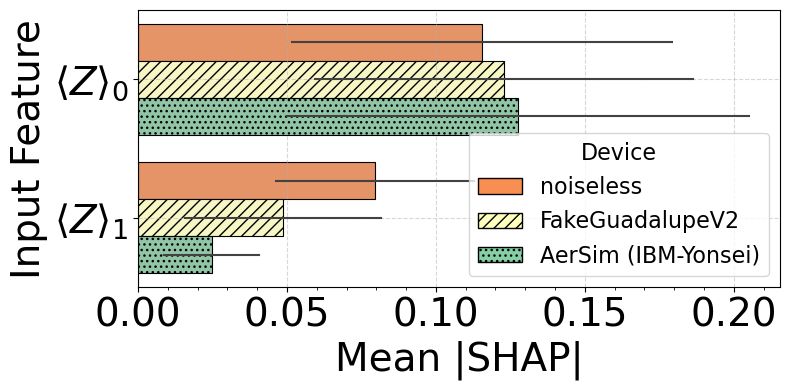

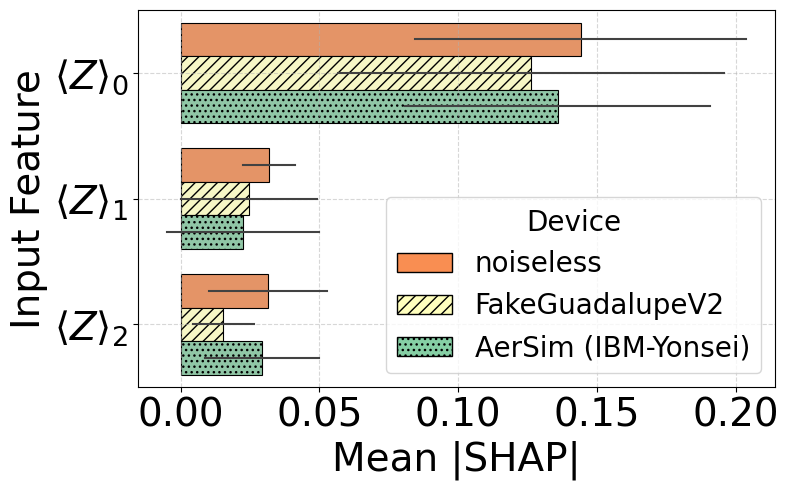

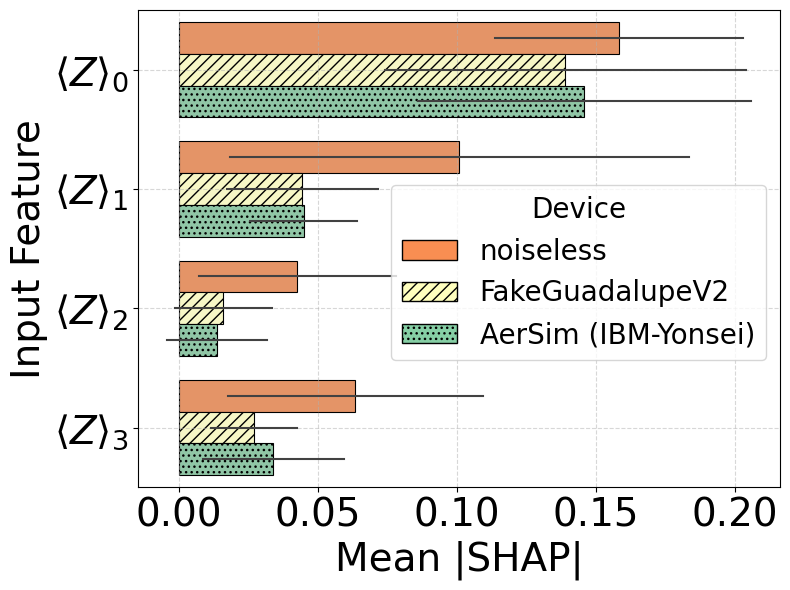

In [71]:
FIGSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): (8, 4),
    ('HQCNN-EZ', 8): (8, 5),
    ('HQCNN-EZ', 10): (8, 6),
    ('HQCNN-EM', 4): (8, 6),
    ('HQCNN-EM', 8): (8, 7),
    ('HQCNN-EM', 10): (8, 8),
}

FONTSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): 28,
    ('HQCNN-EZ', 8): 28,
    ('HQCNN-EZ', 10): 28,
    ('HQCNN-EM', 4): 28,
    ('HQCNN-EM', 8): 28,
    ('HQCNN-EM', 10): 28,
}

LEGEND_FONTSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): 16,
    ('HQCNN-EZ', 8): 20,
    ('HQCNN-EZ', 10): 20,
    ('HQCNN-EM', 4): 24,
    ('HQCNN-EM', 8): 24,
    ('HQCNN-EM', 10): 24,
}

LEGEND_POSITION_BY_PAIR = {
    ('HQCNN-EZ', 4): None,
    ('HQCNN-EZ', 8): None,
    ('HQCNN-EZ', 10): (1.0, 0.45),
    ('HQCNN-EM', 4): (1.0, 0.55),
    ('HQCNN-EM', 8): (1.0, 0.55),
    ('HQCNN-EM', 10): (1.0, 0.55)
}

for num_qubit in num_qubits[:-1]:
    for model_name in model_names_str_new:
        if model_name == 'QCNN':
            continue
        # elif model_name == 'HQCNN-EZ':
        #     continue
        elif model_name == 'HQCNN-EM':
            continue
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))  # fallback size
        plot_grouped_horizontal_bars_for_model(absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
                                               num_qubit=num_qubit,
                                               model=model_name,
                                               figsize=figsize_value,
                                               title_fontsize=fontsize_value,
                                               axis_label_fontsize=fontsize_value,
                                               legend_size=legend_fontsize_value,
                                               tick_fontsize=fontsize_value,
                                               legend_loc='lower right',       # 'lower right', 'center right'
                                               lenged_pos=legend_position_value,
                                               plot_title=None,
                                               plot_save=PLOT_SAVE,
                                               save_dir=save_summary_results_dirs)
        
for num_qubit in num_qubits[-1:]:
    for model_name in model_names_str_new:
        if model_name == 'QCNN':
            continue
        # elif model_name == 'HQCNN-EZ':
        #     continue
        elif model_name == 'HQCNN-EM':
            continue
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))  # fallback size
        plot_grouped_horizontal_bars_for_model(absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
                                               num_qubit=num_qubit,
                                               model=model_name,
                                               figsize=figsize_value,
                                               title_fontsize=fontsize_value,
                                               axis_label_fontsize=fontsize_value,
                                               legend_size=legend_fontsize_value,
                                               tick_fontsize=fontsize_value,
                                               legend_loc='center right',       # 'lower right', 'center right'
                                               lenged_pos=legend_position_value,
                                               plot_title=None,
                                               plot_save=PLOT_SAVE,
                                               save_dir=save_summary_results_dirs)

✅ Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Absolute_SHAP_Mean_Barplot_q4_HQCNN-EM.png
✅ Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Absolute_SHAP_Mean_Barplot_q8_HQCNN-EM.png
✅ Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Absolute_SHAP_Mean_Barplot_q10_HQCNN-EM.png


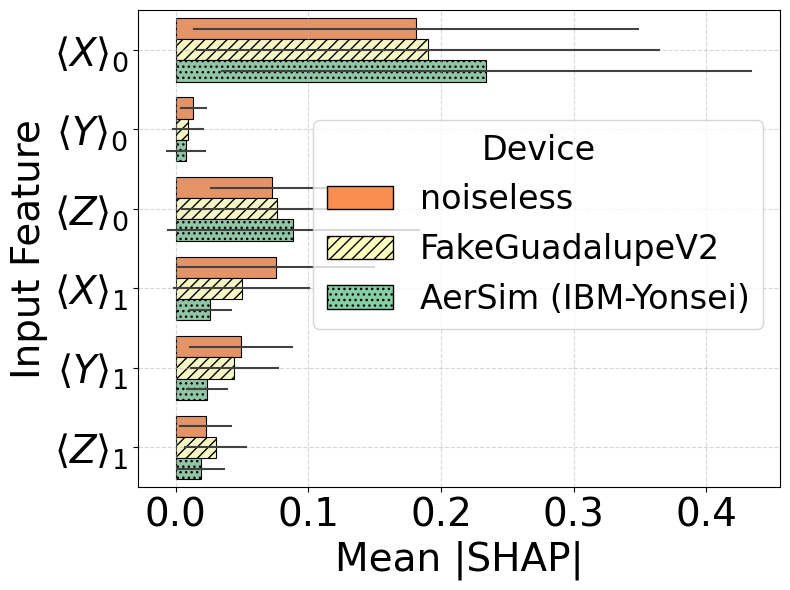

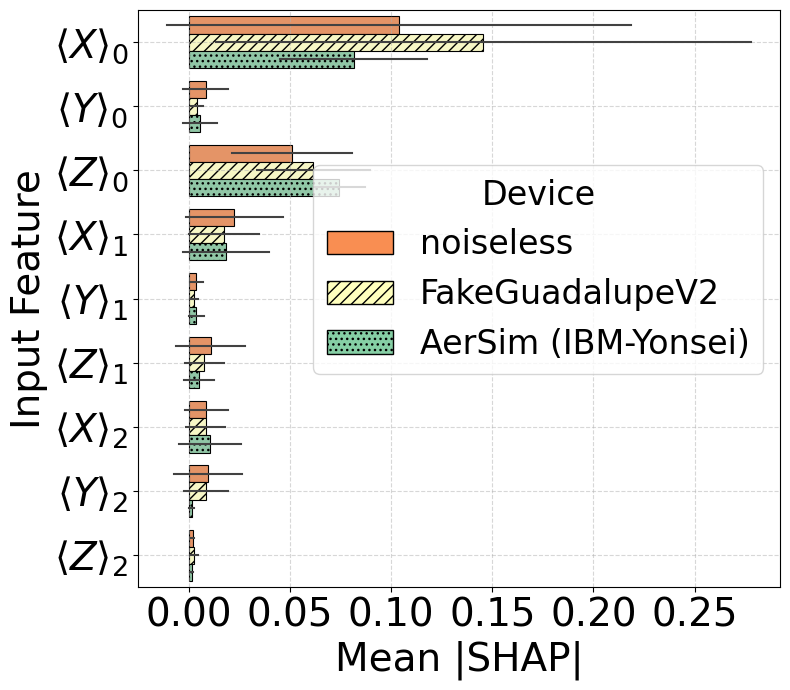

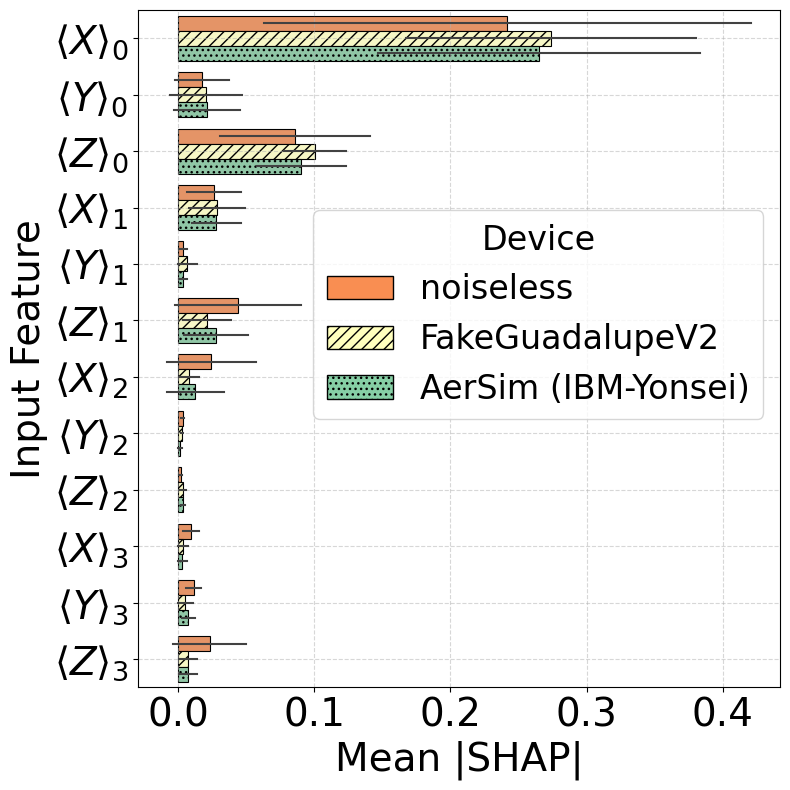

In [72]:
for num_qubit in num_qubits:
    for model_name in model_names_str_new:
        if model_name == 'QCNN':
            continue
        elif model_name == 'HQCNN-EZ':
            continue
        # elif model_name == 'HQCNN-EM':
        #     continue
        figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
        legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))  # fallback size
        plot_grouped_horizontal_bars_for_model(absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
                                               num_qubit=num_qubit,
                                               model=model_name,
                                               figsize=figsize_value,
                                               title_fontsize=fontsize_value,
                                               axis_label_fontsize=fontsize_value,
                                               legend_size=legend_fontsize_value,
                                               tick_fontsize=fontsize_value,
                                               legend_loc='center right',       # 'lower right', 'center right'
                                               lenged_pos=legend_position_value,
                                               plot_title=None,
                                               plot_save=PLOT_SAVE,
                                               save_dir=save_summary_results_dirs)

In [73]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, StrMethodFormatter

def plot_grouped_horizontal_bars_for_model(
    shap_df,
    num_qubit,
    model,
    ax,
    title_fontsize=14,
    axis_label_fontsize=12,
    tick_fontsize=12,
    legend_size=8,
    legend_loc='lower right',
    legend_pos=(1.0, 0.5),
    plot_title=True
):
    """
    Draws into a given Axes `ax` instead of creating a new figure.
    Returns legend_handles (for a shared legend if desired).
    """
    df_model = shap_df[(shap_df['Model'] == model) &
                       (shap_df['Qubits'] == num_qubit)].copy()

    if df_model.empty:
        print(f"No data found for model={model}, q={num_qubit}")
        ax.set_visible(False)
        return []

    # --- 1. Define Order ---
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit)))) for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
        
    # --- LaTeX Label Transformation ---
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]

    # Preserve first-appearance order for devices (hue)
    hue_order = df_model['Device'].drop_duplicates().tolist()

    # Deterministic color map per device
    palette_colors = sns.color_palette('Spectral', n_colors=len(hue_order))
    color_map = dict(zip(hue_order, palette_colors))

    # --- Horizontal barplot ---
    sns.barplot(
        data=df_model,
        y='Input_Feature',
        x='Abs_SHAP',
        hue='Device',
        hue_order=hue_order,
        order=y_order,
        orient='h',
        palette=color_map,
        width=.8,
        linewidth=.8,
        edgecolor='black',
        errorbar='sd',
        err_kws={'linewidth': 1.5},
        ax=ax
    )

    # Hatches
    hatch_map = {
        'noiseless': None,
        'FakeGuadalupeV2': '///',
        'AerSim (IBM-Yonsei)': '...'
    }
    for i, container in enumerate(ax.containers):
        if i >= len(hue_order):
            break
        device_name = hue_order[i]
        hatch = hatch_map.get(device_name, None)
        if hatch:
            for bar in container.patches:
                bar.set_hatch(hatch)

    # Custom legend handles (color + hatch)
    legend_handles = []
    for device_name in hue_order:
        legend_handles.append(
            Patch(
                facecolor=color_map[device_name],
                edgecolor='black',
                hatch=hatch_map.get(device_name, None),
                label=device_name
            )
        )

    # Axes labels & title
    if plot_title:
        ax.set_title(f"{model}, {num_qubit}-qubits", fontsize=title_fontsize)

    ax.set_xlabel("Mean |SHAP|", fontsize=axis_label_fontsize)
    ax.set_ylabel("Input Feature", fontsize=axis_label_fontsize)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)

    # Optional special x-axis formatting
    if num_qubit == 4 and model == 'HQCNN-EZ':
        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
        ax.xaxis.set_minor_locator(MultipleLocator(0.01))

    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)

    ax.grid(axis='x', linestyle='--', alpha=0.5)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Remove seaborn's automatic legend (we'll build shared)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    return legend_handles

Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Absolute_SHAP_Mean_2x3_clf.pdf


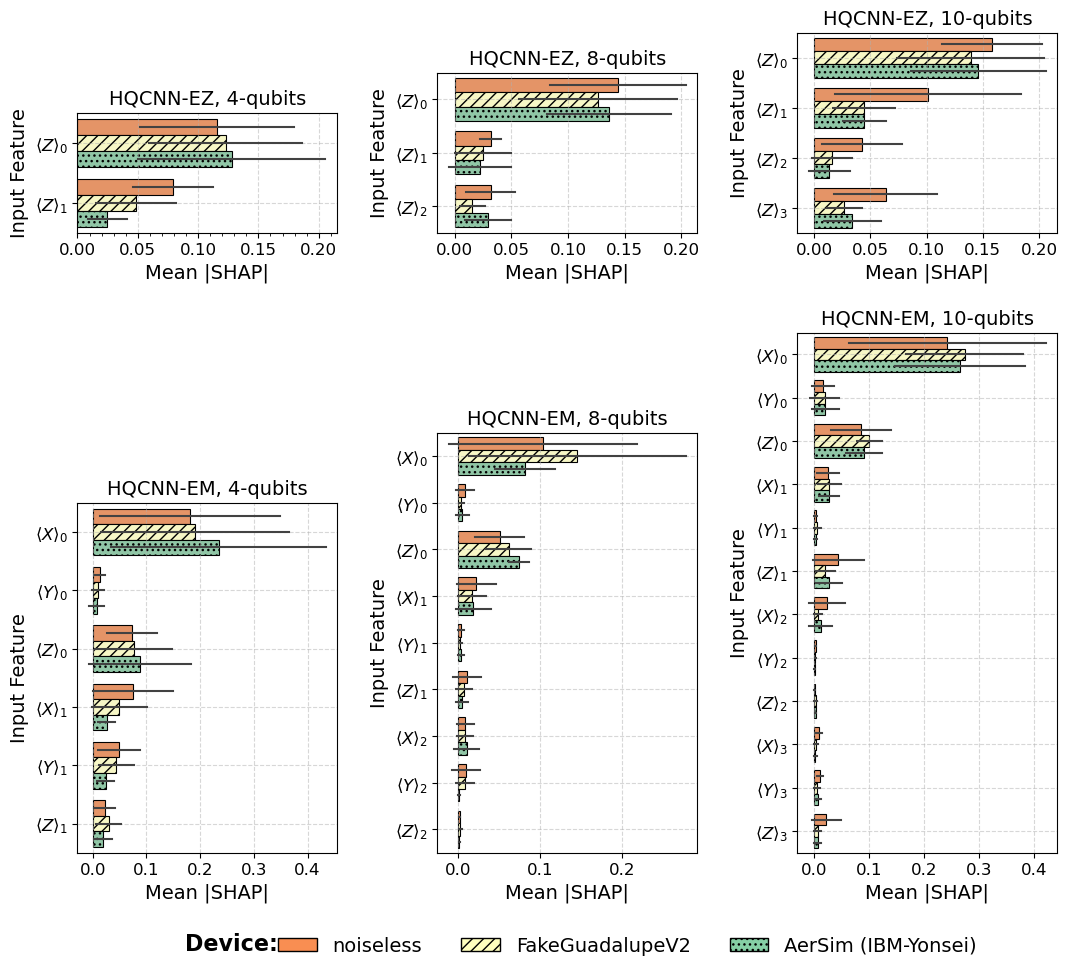

In [74]:
import matplotlib.pyplot as plt
import numpy as np  # only needed if you still want demo data; not needed for SHAP
# absolute_shap_values_df already defined
# model_names_str_new includes ['QCNN', 'HQCNN-EZ', 'HQCNN-EM']

fig = plt.figure(figsize=(10, 10))  # one global canvas

if len(num_qubits) == 2:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.08, 0.52, 0.34, 0.12])   # EZ, q4
    ax2 = fig.add_axes([0.54, 0.52, 0.34, 0.16])   # EZ, q8

    ax3 = fig.add_axes([0.08, 0.00, 0.34, 0.35])   # EM, q4
    ax4 = fig.add_axes([0.54, 0.00, 0.34, 0.42])   # EM, q8
    
    axes = [ax1, ax2, ax3, ax4]
    
elif len(num_qubits) == 3:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.00, 0.62, 0.26, 0.12])  # EZ, q4
    ax2 = fig.add_axes([0.36, 0.62, 0.26, 0.16])  # EZ, q8
    ax3 = fig.add_axes([0.72, 0.62, 0.26, 0.20])  # EZ, q10

    ax4 = fig.add_axes([0.00, 0.0, 0.26, 0.35])   # EM, q4
    ax5 = fig.add_axes([0.36, 0.0, 0.26, 0.42])   # EM, q8
    ax6 = fig.add_axes([0.72, 0.0, 0.26, 0.52])   # EM, q1
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

# num_qubits = [4, 8, 10]
models_for_rows = ['HQCNN-EZ', 'HQCNN-EM']

# Centralized font sizes (you can tweak)
title_font      = 16
subplot_title   = 14
axis_label_font = 14
tick_font       = 12
legend_font     = 14

legend_handles_shared = None

# Fill 2×3: (row= model, col= qubit)
idx = 0
for row, model_name in enumerate(models_for_rows):
    for col, nq in enumerate(num_qubits):
        ax = axes[idx]; idx += 1
        handles = plot_grouped_horizontal_bars_for_model(
            shap_df=absolute_shap_values_df,
            num_qubit=nq,
            model=model_name,
            ax=ax,
            title_fontsize=subplot_title,
            axis_label_fontsize=axis_label_font,
            tick_fontsize=tick_font,
            legend_size=legend_font,
            legend_loc='center right',
            legend_pos=(1.0, 0.5),
            plot_title=True
        )
        # Save legend handles from the first populated subplot
        if legend_handles_shared is None and handles:
            legend_handles_shared = handles

# Shared figure title
# fig.suptitle("Mean Absolute SHAP value of mid-circuit measurements across devices, models, and qubit sizes",
#              fontsize=title_font, y=0.99)

# Shared legend at bottom center
if legend_handles_shared:
    fig.legend(
        handles=legend_handles_shared,
        loc="lower center",
        bbox_to_anchor=(0.55, -0.12),
        ncol=len(legend_handles_shared),
        frameon=False,
        fontsize=legend_font,
        # title="Device",
        title_fontsize=legend_font
    )
    
    # Add external text label on the left or right side of the legend
    fig.text(0.20, -0.091, "Device:", ha='right', va='center', fontsize=legend_font+2, fontweight='bold')

# ---- SAVE PLOT AS PDF ----
if PLOT_SAVE:
    os.makedirs(save_dir, exist_ok=True)
    filename = (save_summary_results_dirs + f'Absolute_SHAP_Mean_2x3_{problem_type}.pdf')
    fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
    print(f"Plot saved as {filename}")

plt.show()

### Mean Boxplot of Absolute SHAP values

In [75]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, StrMethodFormatter


def plot_grouped_boxplots_for_model(shap_df, num_qubit, model,
                                    title_fontsize=14, axis_label_fontsize=12, tick_fontsize=12,
                                    legend_size=8, lenged_pos=(1.0, 0.50), legend_loc='lower right',
                                    plot_title=True, plot_save=False, figsize=(8, 6), save_dir='./',
                                    showfliers=True, whis=1.5):
    df_model = shap_df[shap_df['Model'] == model].copy()

    if df_model.empty:
        print(f"No data found for model: {model}")
        return

    plt.figure(figsize=figsize)

    # --- Define Order ---
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit))))
                   for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
    
    # --- LaTeX Label Transformation ---
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]
    
    # Preserve first-appearance order for devices (hue)
    hue_order = df_model['Device'].drop_duplicates().tolist()

    # Deterministic color map per device
    palette_colors = sns.color_palette('Spectral', n_colors=len(hue_order))
    color_map = dict(zip(hue_order, palette_colors))

    ax = sns.boxplot(
        data=df_model,
        y='Input_Feature',
        x='Abs_SHAP',
        hue='Device',
        hue_order=hue_order,
        order=y_order,
        orient='h',
        palette=color_map,
        width=0.7,
        dodge=True,
        whis=whis,
                
        # --- Make lines black ---
        boxprops     = {"edgecolor": "black", "linewidth": 0.9},
        whiskerprops = {"color": "black", "linewidth": 0.9},
        capprops     = {"color": "black", "linewidth": 0.9},
        medianprops  = {"color": "black", "linewidth": 2.0},
        
        # --- Outliers ---
        showfliers=showfliers,
        flierprops={
            "marker": "d",
            "markersize": 3,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.7,
            "alpha": 0.8,
        } if showfliers else None,
    )
    
    # --- Draw Boundary Lines ---
    for y in range(len(y_order) + 1):
        ax.axhline(y - 0.5, color='black', linestyle='-', linewidth=1.0, alpha=0.8, zorder=0)

    # --- Hatch map (device -> hatch) ---
    hatch_map = {
        'noiseless': None,
        'FakeGuadalupeV2': '///',
        'AerSim (IBM-Yonsei)': '...'
    }

    # Remove seaborn's default legend (we'll add custom)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # --- Robust hatch assignment: match box -> device by facecolor ---
    rgba_map = {dev: mpl.colors.to_rgba(color_map[dev]) for dev in hue_order}

    def closest_device_by_color(fc_rgba, tol=1e-3):
        # near-exact match first
        for dev, rgba in rgba_map.items():
            if np.allclose(fc_rgba, rgba, atol=tol):
                return dev
        # fallback: closest distance
        devs = list(rgba_map.keys())
        dists = [np.linalg.norm(np.array(fc_rgba) - np.array(rgba_map[d])) for d in devs]
        return devs[int(np.argmin(dists))]

    # Seaborn may store box patches in ax.patches (matplotlib PathPatch)
    # This does NOT assume any order.
    box_patches = [p for p in ax.patches if isinstance(p, mpl.patches.PathPatch)]

    for p in box_patches:
        dev = closest_device_by_color(p.get_facecolor())
        hatch = hatch_map.get(dev, None)
        p.set_edgecolor('black')
        p.set_linewidth(0.8)
        if hatch:
            p.set_hatch(hatch)

    # Custom legend: show both hatch + color
    legend_handles = [
        Patch(facecolor=color_map[d], edgecolor='black', hatch=hatch_map.get(d, None), label=d)
        for d in hue_order
    ]
    ax.legend(
        handles=legend_handles,
        title='Device',
        fontsize=legend_size,
        bbox_to_anchor=lenged_pos,
        title_fontsize=legend_size,
        loc=legend_loc
    )

    if plot_title:
        plt.title(f"Abs SHAP Distribution — q{num_qubit}, {model}", fontsize=title_fontsize)

    plt.xlabel("Mean |SHAP|", fontsize=axis_label_fontsize)
    plt.ylabel("Input Feature", fontsize=axis_label_fontsize)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)
    if num_qubit == 4 and model == 'HQCNN-EZ':
        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
        ax.xaxis.set_minor_locator(MultipleLocator(0.01))

    plt.xticks(fontsize=tick_fontsize)
    plt.yticks(fontsize=tick_fontsize)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    # plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()

    if plot_save:
        os.makedirs(save_dir, exist_ok=True)
        filename = os.path.join(save_dir, f'Absolute_SHAP_Boxplot_q{num_qubit}_{model}.png')
        plt.savefig(filename, dpi=200, bbox_inches='tight')
        print(f"✅ Plot saved as {filename}")
    else:
        plt.show()


In [76]:
FIGSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): (8, 4),
    ('HQCNN-EZ', 8): (8, 5),
    ('HQCNN-EZ', 10): (8, 6),
    ('HQCNN-EM', 4): (8, 6),
    ('HQCNN-EM', 8): (8, 7),
    ('HQCNN-EM', 10): (8, 8),
}

FONTSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): 28,
    ('HQCNN-EZ', 8): 28,
    ('HQCNN-EZ', 10): 28,
    ('HQCNN-EM', 4): 28,
    ('HQCNN-EM', 8): 28,
    ('HQCNN-EM', 10): 28,
}

LEGEND_FONTSIZE_BY_PAIR = {
    ('HQCNN-EZ', 4): 16,
    ('HQCNN-EZ', 8): 20,
    ('HQCNN-EZ', 10): 20,
    ('HQCNN-EM', 4): 24,
    ('HQCNN-EM', 8): 24,
    ('HQCNN-EM', 10): 24,
}

LEGEND_POSITION_BY_PAIR = {
    ('HQCNN-EZ', 4): None,
    ('HQCNN-EZ', 8): None,
    ('HQCNN-EZ', 10): (1.0, 0.45),
    ('HQCNN-EM', 4): (1.0, 0.55),
    ('HQCNN-EM', 8): (1.0, 0.55),
    ('HQCNN-EM', 10): (1.0, 0.55)
}

# for num_qubit in num_qubits[:-1]:
#     for model_name in model_names_str_new:
#         if model_name == 'QCNN':
#             continue
#         # elif model_name == 'HQCNN-EZ':
#         #     continue
#         elif model_name == 'HQCNN-EM':
#             continue
#         figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
#         fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
#         legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
#         legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))  # fallback size
#         plot_grouped_boxplots_for_model(absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
#                                                num_qubit=num_qubit,
#                                                model=model_name,
#                                                figsize=figsize_value,
#                                                title_fontsize=fontsize_value,
#                                                axis_label_fontsize=fontsize_value,
#                                                legend_size=legend_fontsize_value,
#                                                tick_fontsize=fontsize_value,
#                                                legend_loc='lower right',       # 'lower right', 'center right'
#                                                lenged_pos=legend_position_value,
#                                                plot_title=None,
#                                                plot_save=PLOT_SAVE,
#                                                save_dir=save_summary_results_dirs)
        
# for num_qubit in num_qubits[-1:]:
#     for model_name in model_names_str_new:
#         if model_name == 'QCNN':
#             continue
#         # elif model_name == 'HQCNN-EZ':
#         #     continue
#         elif model_name == 'HQCNN-EM':
#             continue
#         figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
#         fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
#         legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
#         legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))  # fallback size
#         plot_grouped_boxplots_for_model(absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
#                                                num_qubit=num_qubit,
#                                                model=model_name,
#                                                figsize=figsize_value,
#                                                title_fontsize=fontsize_value,
#                                                axis_label_fontsize=fontsize_value,
#                                                legend_size=legend_fontsize_value,
#                                                tick_fontsize=fontsize_value,
#                                                legend_loc='center right',       # 'lower right', 'center right'
#                                                lenged_pos=legend_position_value,
#                                                plot_title=None,
#                                                plot_save=PLOT_SAVE,
#                                                save_dir=save_summary_results_dirs)

In [77]:
# for num_qubit in num_qubits:
#     for model_name in model_names_str_new:
#         if model_name == 'QCNN':
#             continue
#         elif model_name == 'HQCNN-EZ':
#             continue
#         # elif model_name == 'HQCNN-EM':
#         #     continue
#         figsize_value = FIGSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
#         fontsize_value = FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
#         legend_fontsize_value = LEGEND_FONTSIZE_BY_PAIR.get((model_name, num_qubit), (8, 6))  # fallback size
#         legend_position_value = LEGEND_POSITION_BY_PAIR.get((model_name, num_qubit), (1.0, 0.5))  # fallback size
#         plot_grouped_boxplots_for_model(absolute_shap_values_df[absolute_shap_values_df['Qubits'] == num_qubit],
#                                                num_qubit=num_qubit,
#                                                model=model_name,
#                                                figsize=figsize_value,
#                                                title_fontsize=fontsize_value,
#                                                axis_label_fontsize=fontsize_value,
#                                                legend_size=legend_fontsize_value,
#                                                tick_fontsize=fontsize_value,
#                                                legend_loc='center right',       # 'lower right', 'center right'
#                                                lenged_pos=legend_position_value,
#                                                plot_title=None,
#                                                plot_save=PLOT_SAVE,
#                                                save_dir=save_summary_results_dirs)

In [78]:
import numpy as np
import seaborn as sns
import matplotlib as mpl
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator, StrMethodFormatter

def plot_grouped_horizontal_boxplots_for_model(
    shap_df,
    num_qubit,
    model,
    ax,
    title_fontsize=14,
    axis_label_fontsize=12,
    tick_fontsize=12,
    legend_size=8,
    legend_loc='lower right',
    legend_pos=(1.0, 0.5),
    plot_title=True,
    showfliers=True,
    whis=1.5
):
    """
    Draws grouped horizontal BOXPLOTS into a given Axes `ax`.
    Returns legend_handles (for a shared legend if desired).
    """
    df_model = shap_df[(shap_df['Model'] == model) &
                       (shap_df['Qubits'] == num_qubit)].copy()

    if df_model.empty:
        print(f"No data found for model={model}, q={num_qubit}")
        ax.set_visible(False)
        return []

    # --- 1. Define Order ---
    if model == 'HQCNN-EZ':
        y_order = [f"⟨Z⟩_{i}" for i in range(int(np.ceil(np.log2(num_qubit))))]
    elif model == 'HQCNN-EM':
        y_order = [f"{m}{i}" for i in range(int(np.ceil(np.log2(num_qubit))))
                   for m in ['⟨X⟩_', '⟨Y⟩_', '⟨Z⟩_']]
    else:
        y_order = df_model['Input_Feature'].drop_duplicates().tolist()
    
    # --- LaTeX Label Transformation ---
    latex_labels = [
        f"$\\langle {lbl.split('⟩_')[0].strip('⟨')} \\rangle_{{{lbl.split('_')[-1]}}}$" 
        if '⟨' in lbl else lbl 
        for lbl in y_order
    ]

    # Preserve first-appearance order for devices (hue)
    hue_order = df_model['Device'].drop_duplicates().tolist()

    # Deterministic color map per device
    palette_colors = sns.color_palette('Spectral', n_colors=len(hue_order))
    color_map = dict(zip(hue_order, palette_colors))

    # --- 2. Box Plot (apply same black-line + outlier styling) ---
    sns.boxplot(
        data=df_model,
        y='Input_Feature',
        x='Abs_SHAP',
        hue='Device',
        hue_order=hue_order,
        order=y_order,
        orient='h',
        palette=color_map,
        width=0.7,
        dodge=True,
        whis=whis,

        # --- Make lines black ---
        boxprops     = {"edgecolor": "black", "linewidth": 0.9},
        whiskerprops = {"color": "black", "linewidth": 0.9},
        capprops     = {"color": "black", "linewidth": 0.9},
        medianprops  = {"color": "black", "linewidth": 2.0},

        # --- Outliers ---
        showfliers=showfliers,
        flierprops={
            "marker": "d",
            "markersize": 3,
            "markerfacecolor": "white",
            "markeredgecolor": "black",
            "markeredgewidth": 0.7,
            "alpha": 0.8,
        } if showfliers else None,

        ax=ax
    )
    
    # --- Draw Boundary Lines ---
    for y in range(len(y_order) + 1):
        ax.axhline(y - 0.5, color='black', linestyle='-', linewidth=1.0, alpha=0.8, zorder=0)
        
    # --- 3. Hatches (ROBUST for Boxplot) ---
    hatch_map = {
        'noiseless': None,
        'FakeGuadalupeV2': '///',
        'AerSim (IBM-Yonsei)': '...'
    }

    # Remove seaborn's auto legend (we return handles instead)
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    # --- Robust hatch assignment: match box -> device by facecolor ---
    rgba_map = {dev: mpl.colors.to_rgba(color_map[dev]) for dev in hue_order}

    def closest_device_by_color(fc_rgba, tol=1e-3):
        # near-exact match first
        for dev, rgba in rgba_map.items():
            if np.allclose(fc_rgba, rgba, atol=tol):
                return dev
        # fallback: closest distance
        devs = list(rgba_map.keys())
        dists = [np.linalg.norm(np.array(fc_rgba) - np.array(rgba_map[d])) for d in devs]
        return devs[int(np.argmin(dists))]

    # Seaborn may store box patches in ax.patches (matplotlib PathPatch)
    box_patches = [p for p in ax.patches if isinstance(p, mpl.patches.PathPatch)]

    for p in box_patches:
        dev = closest_device_by_color(p.get_facecolor())
        hatch = hatch_map.get(dev, None)

        # keep edges black and explicit width
        p.set_edgecolor('black')
        p.set_linewidth(0.8)

        if hatch:
            p.set_hatch(hatch)

    # --- 4. Legend Handles (color + hatch) ---
    legend_handles = [
        Patch(
            facecolor=color_map[device_name],
            edgecolor='black',
            hatch=hatch_map.get(device_name, None),
            label=device_name
        )
        for device_name in hue_order
    ]

    # --- 5. Formatting ---
    if plot_title:
        ax.set_title(f"{model}, {num_qubit}-qubits", fontsize=title_fontsize)

    ax.set_xlabel("Mean |SHAP|", fontsize=axis_label_fontsize)
    ax.set_ylabel("Input Feature", fontsize=axis_label_fontsize)
    ax.set_yticks(range(len(y_order)))
    ax.set_yticklabels(latex_labels, fontsize=tick_fontsize)

    if num_qubit == 4 and model == 'HQCNN-EZ':
        ax.xaxis.set_major_locator(MultipleLocator(0.05))
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
        ax.xaxis.set_minor_locator(MultipleLocator(0.01))

    ax.tick_params(axis='x', labelsize=tick_fontsize)
    ax.tick_params(axis='y', labelsize=tick_fontsize)
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    # ax.grid(axis='y', linestyle='--', alpha=0.5) # Optional, consistent with reference

    return legend_handles

✅ Plot saved as save_results_fb_clf/results_summary2/AngleEmbed_ConvSimple_PoolSimple_ReLU_hl1_batch10_lr0.01_256/Absolute_SHAP_Boxplot_2x3.pdf


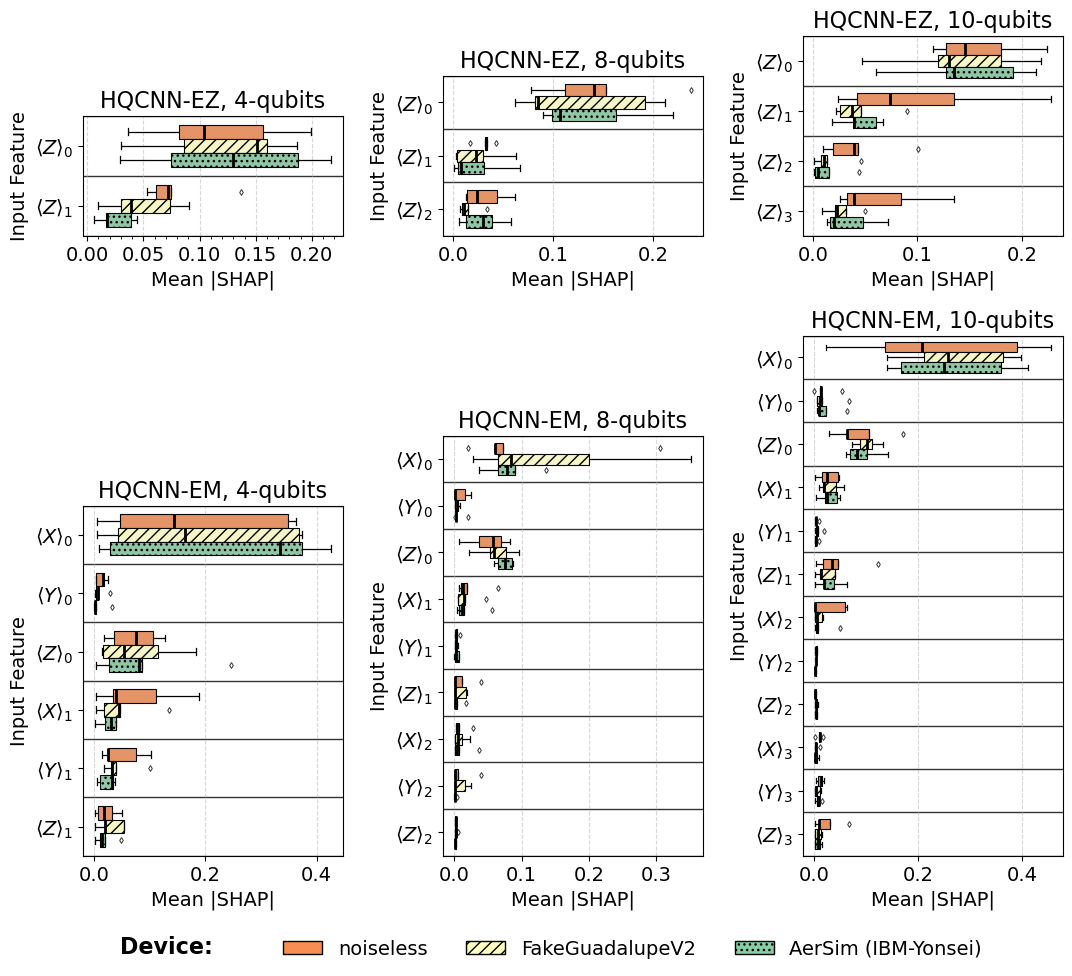

In [79]:
import matplotlib.pyplot as plt
import os

# --- Configurations ---
fig = plt.figure(figsize=(10, 10))  # Global Canvas

if len(num_qubits) == 2:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.08, 0.52, 0.34, 0.12])   # EZ, q4
    ax2 = fig.add_axes([0.54, 0.52, 0.34, 0.16])   # EZ, q8

    ax3 = fig.add_axes([0.08, 0.00, 0.34, 0.35])   # EM, q4
    ax4 = fig.add_axes([0.54, 0.00, 0.34, 0.42])   # EM, q8
    
    axes = [ax1, ax2, ax3, ax4]
    
elif len(num_qubits) == 3:
    # Axes: [left, bottom, width, height]
    # Adjust heights based on feature count (EM has more features, needs more height)
    ax1 = fig.add_axes([0.00, 0.62, 0.26, 0.12])  # EZ, q4
    ax2 = fig.add_axes([0.36, 0.62, 0.26, 0.16])  # EZ, q8
    ax3 = fig.add_axes([0.72, 0.62, 0.26, 0.20])  # EZ, q10

    ax4 = fig.add_axes([0.00, 0.0, 0.26, 0.35])   # EM, q4
    ax5 = fig.add_axes([0.36, 0.0, 0.26, 0.42])   # EM, q8
    ax6 = fig.add_axes([0.72, 0.0, 0.26, 0.52])   # EM, q1
    
    axes = [ax1, ax2, ax3, ax4, ax5, ax6]

# num_qubits = [4, 8, 10]
models_for_rows = ['HQCNN-EZ', 'HQCNN-EM']

# Font sizes
title_font      = 16
subplot_title   = 16
axis_label_font = 14
tick_font       = 14
legend_font     = 14

legend_handles_shared = None

# --- Loop to Fill 2×3 Grid ---
idx = 0
for row, model_name in enumerate(models_for_rows):
    for col, nq in enumerate(num_qubits):
        current_ax = axes[idx]
        idx += 1
        
        # Call the BOXPLOT function
        handles = plot_grouped_horizontal_boxplots_for_model(
            shap_df=absolute_shap_values_df,
            num_qubit=nq,
            model=model_name,
            ax=current_ax,
            title_fontsize=subplot_title,
            axis_label_fontsize=axis_label_font,
            tick_fontsize=tick_font,
            legend_size=legend_font,
            legend_loc='center right',
            legend_pos=(1.0, 0.5),
            plot_title=True
        )
        
        # Save legend handles from the first populated subplot
        if legend_handles_shared is None and handles:
            legend_handles_shared = handles

# --- Global Legend ---
if legend_handles_shared:
    fig.legend(
        handles=legend_handles_shared,
        loc="lower center",
        bbox_to_anchor=(0.55, -0.12),
        ncol=len(legend_handles_shared),
        frameon=False,
        fontsize=legend_font,
        title_fontsize=legend_font
    )
    
    # "Device:" label
    fig.text(0.13, -0.091, "Device:", ha='right', va='center', fontsize=legend_font+2, fontweight='bold')

# --- Save ---
if PLOT_SAVE:
    os.makedirs(save_summary_results_dirs, exist_ok=True)
    filename = os.path.join(save_summary_results_dirs, 'Absolute_SHAP_Boxplot_2x3.pdf')
    fig.savefig(filename, dpi=300, bbox_inches='tight', format='pdf')
    print(f"✅ Plot saved as {filename}")

plt.show()